# 募資專案成功機率預測（XGBoost + SHAP + 機率校準）

這份 Notebook 在 Colab 上執行完整流程：
1. 安裝套件、掛載 Google Drive、設定中文字型
2. `build_dataset.py`：把分散在各類別資料夾裡的 5 種特徵 CSV 合併成訓練資料（自動排除會洩漏成功/失敗答案的欄位）
3. `crowdfunding_model.py`：訓練 XGBoost，用 Brier Score／可靠度曲線驗證機率品質，必要時套用 Isotonic Regression 校準，並用 SHAP 解釋每個特徵的貢獻

**使用前只需要改「參數設定」那個 cell 裡的路徑，其他都不用動。**

## 1. 安裝套件

In [1]:
!pip install -q --upgrade shap xgboost statsmodels

## 2. 中文字型（避免圖表中文變成方框）

之前用 `apt-get install` 裝字型有時會失敗或裝了但 matplotlib 沒認到（Colab 換機器、
套件庫沒更新、或字型快取沒重新整理都有可能）。這裡改成直接下載字型檔、
用 `addfont()` 註冊進 matplotlib——不依賴系統套件安裝，也不用重啟 Runtime，
下載完這個 cell 跑完就能用。

In [2]:
import os, urllib.request
import matplotlib
import matplotlib.font_manager as fm

FONT_PATH = "/content/NotoSansCJKtc-Regular.otf"
if not os.path.exists(FONT_PATH):
    FONT_URL = "https://raw.githubusercontent.com/googlefonts/noto-cjk/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
    urllib.request.urlretrieve(FONT_URL, FONT_PATH)

fm.fontManager.addfont(FONT_PATH)
FONT_NAME = fm.FontProperties(fname=FONT_PATH).get_name()
matplotlib.rcParams['font.sans-serif'] = [FONT_NAME]
matplotlib.rcParams['axes.unicode_minus'] = False
print(f"已載入中文字型：{FONT_NAME}")

已載入中文字型：Noto Sans CJK TC


## 3. 掛載 Google Drive

你的資料結構是：
```
ZecZec_Group_Data/
├─ 遊戲_New_ZecZec_Dataset/
│   ├─ video_features_project_level_candidates.csv
│   ├─ market_price_result.csv
│   ├─ image_text_ratio.csv
│   ├─ trend_score.csv
│   └─ agent_copywriting_result.csv
├─ 時尚_New_ZecZec_Dataset/
│   └─ ...
```
掛載後不用手動搬動或改資料夾結構，`build_dataset.py` 會自動遞迴搜尋所有子資料夾，
新增更多類別的資料夾時也一樣直接放進去、不用改路徑。

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 4. 參數設定 —— **只需要改這裡**

In [4]:
# 指向 Google Drive 裡 ZecZec_Group_Data 這個資料夾（依你實際路徑調整）
UPLOAD_DIR = "/content/drive/MyDrive/ZecZec_Group_Data"

# 輸出結果要放哪裡（會自動建立資料夾）
OUTPUT_DIR = "/content/output"

TARGET_COL = "label"        # 標籤欄位名稱（1=成功, 0=失敗）
ECE_THRESHOLD = 0.05         # 觸發 Isotonic 校準的門檻
PROJECT_INDEX = 0            # 要輸出詳細報告的測試集專案索引（第幾筆）

# --- 輸出精簡度（新增）---
# False（預設）：每個檢查只印一行摘要，完整細節都在存檔的 CSV/JSON/圖檔裡；
# True：印出逐折/逐期/逐特徵的完整明細（除錯或想仔細看某一步驟時再開）
VERBOSE_DIAGNOSTICS = False

# --- 時間切分穩健性驗證（新增）---
# 是否執行多視窗時間切分驗證（walk-forward / expanding window），而不只是切一刀（早80%/晚20%）
ENABLE_WALK_FORWARD = True
# walk-forward 視窗數量（資料量不夠時，程式會自動縮小到能切出來的最大視窗數）
N_WALKFORWARD_SPLITS = 4
# 是否執行「訓練集(早期) vs 測試集(晚期)」特徵分布位移檢查（PSI / KS），定位時間切分下滑的成因
ENABLE_FEATURE_SHIFT_CHECK = True
# 是否在時間切分框架下做超參數搜尋，嘗試把時間切分 AUC 再往上推一點（不保證一定能到特定目標值，
# 詳見 time_series_hyperparam_search() 函式說明；會把每組候選參數的結果都記錄成實驗紀錄檔）
ENABLE_HYPERPARAM_SEARCH = True

# --- 市場結構斷點檢查（新增）：先確認 walk-forward 早期視窗崩掉是不是「市場真的變了」---
ENABLE_MARKET_STRUCTURE_CHECK = True
MARKET_STRUCTURE_FREQ = "Q"   # 分期粒度："Q"=每季、"M"=每月、"Y"=每年

# --- 固定滑動窗 walk-forward（新增）：只用「最近 N 個月」訓練，取代 expanding window
# 把全部歷史資料一起餵進去；適合拿來檢查「如果市場結構真的換過，只看最近的資料訓練
# 會不會比較穩定」---
ENABLE_SLIDING_WINDOW = True
TRAIN_WINDOW_MONTHS = 12      # 滑動窗訓練窗口固定幾個月

# --- 共線性處理門檻（新增）---
# 特徵與標籤（成功/失敗）的相關係數絕對值 >= 這個門檻，視為疑似洩漏，訓練前直接排除
LABEL_CORR_THRESHOLD = 0.90
# 特徵彼此之間的 VIF（變異數膨脹因子）>= 這個門檻，視為高度共線，反覆剔除到都低於門檻為止
VIF_THRESHOLD = 10.0

# --- 時間性洩漏防範（新增，2026-09 重新評估）---
# 你的資料目前只在專案「結束後」才擷取得到，原本擔心圖片/影片數量、FAQ 題數這類
# 「頁面內容累積型」特徵，是結果已經確定之後才繼續增加的（成功案例通常履約階段
# 還在加新公告/新照片跟贊助者回報進度），拿來預測「募資當下會不會成功」就是時間性洩漏。
# 已跑過 check_post_hoc_accumulation_signal()：這批特徵跟 funding_duration_days（募資期間
# 長短）沒有一個相關係數超過 0.30，不像是「隨累積時間變多」——放回去做對照實驗，
# 觀察 walk-forward AUC/ECE 有沒有明顯提升；如果 AUC 大幅跳升但 ECE 明顯變差，
# 代表還是比較像洩漏，屆時改回 True。仍未驗證跟「超募倍數」的關聯（overfunding_col
# 目前沒有資料可填），這是本次改動附帶的殘留風險，不是已經完全排除。
EXCLUDE_POST_HOC_RISK_FEATURES = False

# --- 正式上線模型（近期窗口）專用的加碼累積特徵開關（新增，2026-09）---
# 全歷史診斷模型放回這批特徵後，誠實版 AUC 從 0.627 進步到 0.7155，看起來是真訊號；
# 但拿同一批特徵餵給「近9個月」正式模型後，配方穩定性回測（4個時間點）的 AUC 標準差
# 從原本的 0.0453 暴增到 0.1953——代表這批特徵在樣本量小很多的近期窗口裡，
# 讓配方變得很不穩定，不能直接套用「全歷史模型上有效」的結論。
# 這裡刻意跟上面的 EXCLUDE_POST_HOC_RISK_FEATURES 分開設定：診斷模型可以放，
# 正式上線模型先維持排除，等資料量在近期窗口也成長到夠大，或做過更嚴謹的
# 時間切分驗證後，再考慮把這裡也改成 False。
EXCLUDE_POST_HOC_RISK_FEATURES_PRODUCTION = True

# --- 資料品質篩選（新增）：market_structure_over_time.csv 印出的「資料異常提醒」
# 如果查證後確認某段早期資料有問題，把這裡設成那段之後的日期字串（例如 "2021-01-01"），
# 所有時間切分相關檢查（walk-forward／超參數搜尋／誠實版模型）都會排除更早的資料。
# 市場結構斷點檢查本身不受這個影響（要看完整歷史才找得出斷點），維持 None 就是不篩選。
MIN_DATE = None               # 例如 "2021-01-01"；先看過異常提醒（含自動建議值）再決定

# --- 誠實版模型校準（新增）：時間切分預設沒有獨立校準集，機率容易系統性偏移 ---
# 開啟後會從訓練區段尾端（緊接測試集之前）切一小塊當校準集，ECE 超標的話套用 Isotonic
USE_HONEST_CALIBRATION_SPLIT = True
HONEST_CAL_FRAC = 0.20        # 校準集佔訓練區段的比例（原 0.15，ECE=0.0551 仍超標，調高重新評估）

# --- 正式上線模型（近期窗口）參數 ---
MONTHS_BACK_PRODUCTION = 9    # train_production_model() 只用最近幾個月的資料訓練
# validate_recent_window_recipe()：把「近 MONTHS_BACK_PRODUCTION 個月」這個配方往回推
# 幾個時間點各重跑一次，檢查配方本身穩不穩，而不是只看「現在」這一次的結果好不好看
RECIPE_N_CHECKPOINTS = 4
RECIPE_STEP_MONTHS = 3

# --- 正式模型／配方回測的小校準集（新增）---
# 資料量還小的時候（近9個月約600筆）測過 10%/15%/20%/25% 四種比例都輸給「不切校準集」，
# 所以先前預設不切。目前近9個月窗口已成長到 700+ 筆，這裡加開關重新評估：
# True 時會從訓練區段尾端切一小塊校準集，ECE 超過 PRODUCTION_ECE_THRESHOLD 才套用 Isotonic。
USE_PRODUCTION_CALIBRATION_SPLIT = True
PRODUCTION_CALIBRATION_FRAC = 0.20   # 校準集佔訓練區段的比例（原 0.10→0.15，這次再往上試 0.20）
PRODUCTION_ECE_THRESHOLD = 0.05

# --- 校準方法（新增）---
# "isotonic"（預設）：無母數、彈性高，但校準集不夠大時容易過擬合出鋸齒狀機率；
# "sigmoid"：Platt scaling，只有兩個參數，校準集小的時候通常更穩健。
# 如果調高 HONEST_CAL_FRAC / PRODUCTION_CALIBRATION_FRAC 之後 ECE 還是超標或不穩定，
# 把這裡改成 "sigmoid" 重新跑一次比較看看。同一個開關同時套用在誠實版模型跟正式模型上，
# 方便公平比較同一種校準方法在兩邊的效果。
CALIBRATION_METHOD = "isotonic"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
# 時間切分驗證（新增）用的 side-car 檔案，build_dataset.py 會自動輸出（找不到日期就不會產生這個檔案，
# 屆時 run_pipeline 會自動略過時間切分驗證，不影響主流程）
META_PATH = f"{OUTPUT_DIR}/project_meta_dates.csv"


## 5. `build_dataset.py` —— 合併 5 種特徵 CSV

- 用檔名關鍵字比對，不管檔案在哪個類別子資料夾底下都會被抓到
- 只把「成功/失敗」抽成標籤 `label`，來源欄位（status／category_path／路徑字串）本身不進特徵矩陣
- `trend_score` 相關檔案目前只收錄成功案例，會被讀進來做風險提示，但**不會**進入訓練特徵（避免用「有沒有這筆資料」洩漏答案）
- 類別／平台類型會自動 one-hot 展開，新增幾個類別都不需要改程式碼
- **新增**：訓練前會再跑一次「共線性分析」——特徵和標籤的相關係數（找疑似洩漏）＋ 特徵彼此的 VIF（找高度共線、資訊重複的欄位），超過門檻的欄位會被自動排除後才拿去訓練

In [5]:
# -*- coding: utf-8 -*-
"""
build_dataset.py（通用版）
=================
把「同一種類型」的特徵檔案（可能來自很多個募資類別：時尚、教育、...未來還會更多）
合併成一份可直接餵給 crowdfunding_model.py 的訓練資料。

設計原則：
  - 每一種特徵類型用「檔名關鍵字」比對，一次讀進該類型底下所有檔案再疊起來，
    所以之後不管新增幾個類別的檔案，只要檔名還是同一套命名規則，直接把新檔案
    丟進 /mnt/user-data/uploads 再重跑這支腳本就行，不必改程式碼。
  - 不再假設「只有兩種類別」，category / platform_type 一律當成文字欄位保留，
    one-hot 交給 crowdfunding_model.py 在訓練時動態展開（新類別自動生出新欄位）。

【重要：洩漏防範，邏輯不變】
  - agent_copywriting 的 `status`、market_price 的 `category_path`、
    video_features 的 `category` 都藏著成功/失敗答案，只拿來抽標籤，
    抽完後這些原始欄位本身都不會進入特徵矩陣。
  - training_dataset.csv（市場契合度 PMF 特徵來源）裡的「達標率(%)」「is_hit」
    等欄位同樣可能藏著結果，這裡只擷取 pmf_a/b/c/d 開頭的欄位，其餘一律不進特徵矩陣。
"""

import glob
import re
import pandas as pd

# UPLOAD_DIR / OUTPUT_DIR 沿用上面「參數設定」cell 裡的值
OUT_PATH = f"{OUTPUT_DIR}/merged_training_data.csv"

# 檔名關鍵字 → 這種類型的所有檔案（未來新增類別的檔案只要符合關鍵字就會自動被讀到）
# 用「詞幹」比對（不含結尾 s、不含 _result/_results 後綴差異），這樣同一種檔案
# 不管命名是單數/複數、有沒有 _result 後綴都抓得到，例如：
#   market_price_result.csv 和 market_price_results.csv 都符合 *market_price*
FILE_PATTERNS = {
    "copywriting": "*copywriting*.csv",
    "video": "*video_features_project_level_candidates*.csv",
    "price": "*market_price*.csv",
    "image_text": "*image_text_ratio*.csv",
    "trend": "*training_dataset*.csv",   # 市場契合度 PMF 特徵來源，已從 trend_scores.csv 改為這份
    "summary": "*projects_summary*.csv",
}


def find_files(pattern: str):
    """遞迴搜尋 UPLOAD_DIR 底下所有子資料夾（例如 Google Drive 同步下來的
    每個類別各自一個資料夾：遊戲_New_ZecZec_Dataset/、時尚_New_ZecZec_Dataset/…），
    只要檔名符合關鍵字，不管在哪一層都會被抓到。"""
    return sorted(glob.glob(f"{UPLOAD_DIR}/**/{pattern}", recursive=True))


def load_and_concat(pattern: str) -> pd.DataFrame:
    files = find_files(pattern)
    if not files:
        return pd.DataFrame()
    frames = [pd.read_csv(f) for f in files]
    print(f"  比對到 {len(files)} 個檔案：{[f.replace(UPLOAD_DIR + '/', '') for f in files]}")
    return pd.concat(frames, ignore_index=True)


def extract_project_code(raw: str) -> str:
    """任何格式的識別碼統一抽出最後一段基準代碼。"""
    return str(raw).split("/")[-1].strip()


def extract_label(text: str):
    """從含「成功/失敗」字樣的字串取出標籤，只用來建立 y，原欄位不進特徵。"""
    m = re.search(r"(成功|失敗)", str(text))
    return {"成功": 1, "失敗": 0}.get(m.group(1)) if m else None


def extract_category_platform(path_str: str):
    """從類似 '.../<平台類型>/<類別>/<成功|失敗>/<專案代碼>' 的路徑字串中，
    通用地抓出「平台類型」與「類別」兩個文字欄位（不假設類別只有時尚/教育）。
    找不到就回傳 (None, None)，之後留給 pandas 當缺值處理。"""
    parts = str(path_str).split("/")
    label_idx = next((i for i, p in enumerate(parts) if p in ("成功", "失敗")), None)
    if label_idx is None or label_idx < 2:
        return None, None
    category = parts[label_idx - 1]
    platform_type = parts[label_idx - 2]
    return category, platform_type


def count_comma_items(s):
    if pd.isna(s) or str(s).strip() == "":
        return 0
    return len([w for w in str(s).split(",") if w.strip()])

#0816
def parse_mixed_date_format(series: pd.Series) -> pd.Series:
    """projects_summary.csv 的「開始日期」欄位混雜兩種格式：
    XXXX-XX-XX 跟 XXXX/XX/XX。pd.to_datetime 不指定 format 時對混合格式的欄位
    解析不穩定，容易把整批同一種格式的日期轉成 NaT（尤其當兩種格式在同一欄位
    分批出現、pandas 的格式推斷被前幾筆資料誤導時）。這裡分別用兩種明確的
    format 字串各自嘗試，再把結果合併，確保兩種格式都能正確轉換。"""
    s = series.astype(str).str.strip()
    parsed_dash = pd.to_datetime(s, format="%Y-%m-%d", errors="coerce")
    parsed_slash = pd.to_datetime(s, format="%Y/%m/%d", errors="coerce")
    return parsed_dash.combine_first(parsed_slash)

# ------------------------------------------------------------------
# 1. 文案說服力（欄位：agent_copywriting_result*.csv）
# ------------------------------------------------------------------
print("[1/6] 文案說服力特徵")
df_copy = load_and_concat(FILE_PATTERNS["copywriting"])
df_copy_final = pd.DataFrame()
if not df_copy.empty:
    df_copy["project_id"] = df_copy["project_id"].apply(extract_project_code)
    df_copy["label"] = df_copy["status"].map({"成功": 1, "失敗": 0})  # 標籤來源，之後不進特徵
    df_copy["feat_emotional_word_count"] = df_copy["extracted_emotional_words"].apply(count_comma_items)
    df_copy["feat_spec_word_count"] = df_copy["extracted_spec_words"].apply(count_comma_items)
    df_copy["platform_type"] = df_copy["category"]          # 群眾募資 / 預購式專案 / 未來新類型
    df_copy["category_name"] = df_copy["subcategory"]        # 時尚 / 教育 / 未來新類別

    copy_features = [
        "feat_text_story_ratio", "feat_text_spec_ratio_rule", "feat_text_risk_ratio",
        "feat_has_social_link", "feat_punct_intensity", "feat_avg_sentence_len",
        "feat_type_token_ratio", "feat_trust_score", "feat_emotional_ratio", "feat_spec_ratio",
        "feat_emotional_word_count", "feat_spec_word_count",
    ]
    df_copy_final = df_copy[["project_id", "label", "platform_type", "category_name"] + copy_features].copy()
    # status / category / subcategory / agent_advice 等原始文字或洩漏欄位不納入特徵矩陣

# ------------------------------------------------------------------
# 2. 影像吸引力：影片（video_features*.csv）
# ------------------------------------------------------------------
print("[2/6] 影片特徵")
df_video = load_and_concat(FILE_PATTERNS["video"])
df_video_final = pd.DataFrame()
if not df_video.empty:
    df_video["project_id"] = df_video["project"].apply(extract_project_code)
    video_features = [
        "videos_included", "videos_excluded_low_coverage", "total_video_duration",
        "primary_usage_scene_soft_ratio", "primary_gemini_avg_score",
        "mean_usage_scene_soft_ratio",
        "max_usage_scene_soft_ratio", "mean_gemini_avg_score",
        "duration_weighted_usage_scene_ratio",
    ]
    # 已依需求移除：primary_usage_scene_ratio、mean_usage_scene_ratio、
    # max_usage_scene_ratio、max_gemini_avg_score、video_count
    df_video_final = df_video[["project_id"] + video_features].copy()
    # category 欄位含「成功/失敗」字樣，已排除，不納入特徵矩陣

# ------------------------------------------------------------------
# 3. 價格競爭力（market_price_results*.csv）
# ------------------------------------------------------------------
print("[3/6] 價格特徵")
df_price = load_and_concat(FILE_PATTERNS["price"])
df_price_final = pd.DataFrame()
if not df_price.empty:
    df_price["project_id"] = df_price["project_id"].apply(extract_project_code)
    df_price["label"] = df_price["category_path"].apply(extract_label)  # 標籤來源，之後不進特徵
    cats = df_price["category_path"].apply(extract_category_platform)
    df_price["category_name"] = [c[0] for c in cats]
    df_price["platform_type"] = [c[1] for c in cats]
    df_price["market_data_quality_high"] = (df_price["market_data_quality"] == "high").astype(int)
    df_price["innovation_label_is_innovative"] = df_price["innovation_label"].str.contains("創新", na=False).astype(int)

    price_features = [
        "project_core_price", "market_price_min", "market_price_max", "price_deviation_ratio",
        "is_price_competitive", "needs_manual_review",
        "market_data_quality_high", "innovation_label_is_innovative",
    ]
    df_price_final = df_price[["project_id", "label", "platform_type", "category_name"] + price_features].copy()
    # status（API 呼叫狀態，非專案結果）/ category_path / error_message / review_reason /
    # matched_product_titles / product_keyword 皆排除

# ------------------------------------------------------------------
# 4. 影像吸引力：圖文比例（image_text_ratio_result*.csv）
# ------------------------------------------------------------------
print("[4/6] 圖文比例特徵")
df_img = load_and_concat(FILE_PATTERNS["image_text"])
df_img_final = pd.DataFrame()
if not df_img.empty:
    df_img["project_id"] = df_img["project"].apply(extract_project_code)
    df_img_final = df_img[["project_id", "word_count", "image_count", "video_count", "media_per_100_words"]].copy()
    df_img_final = df_img_final.rename(columns={
        "word_count": "img_word_count", "image_count": "img_image_count", "video_count": "img_video_count",
    })

# ------------------------------------------------------------------
# 5. training_dataset.csv —— 市場契合度 PMF 特徵
#    （trend_scores.csv 已改為讀 training_dataset.csv，只擷取 pmf_ 開頭的欄位；
#     這份檔案自帶 matched_full_project_id，可直接對到其他來源的完整代碼，
#     不需要再做短代碼比對）
# ------------------------------------------------------------------
print("[5/6] 市場契合度 PMF 特徵（training_dataset.csv）")
df_trend = load_and_concat(FILE_PATTERNS["trend"])
df_trend_final = pd.DataFrame()
trend_label_source = pd.DataFrame(columns=["project_id", "label"])
if not df_trend.empty:
    id_col = "matched_full_project_id" if "matched_full_project_id" in df_trend.columns else "project_id"
    df_trend["project_id"] = df_trend[id_col].apply(extract_project_code)

    # pmf_b_trend_level 對應附圖「Google 趨勢斜率」，要保留；
    # pmf_b_is_imputed 只是「這筆是否為補值」的旗標，不是趨勢數值，排除掉
    pmf_cols = [c for c in df_trend.columns if c.startswith("pmf_") and c != "pmf_b_is_imputed"]
    print(f"  擷取到的 PMF 欄位：{pmf_cols}")
    for c in pmf_cols:
        if df_trend[c].dtype == bool:
            df_trend[c] = df_trend[c].astype(int)  # True/False -> 1/0，XGBoost 需要數值輸入

    if "募資狀態" in df_trend.columns:
        df_trend["label"] = df_trend["募資狀態"].map({"成功": 1, "失敗": 0})
    else:
        df_trend["label"] = df_trend["project_id"].apply(extract_label)
    label_counts = df_trend["label"].value_counts(dropna=False)
    print(f"  標籤分布：{dict(label_counts)}")

    df_trend_final = df_trend[["project_id"] + pmf_cols].dropna(subset=["project_id"]).copy()
    df_trend_final = df_trend_final.drop_duplicates(subset="project_id")
    trend_label_source = df_trend[["project_id", "label"]].dropna(subset=["label"])
    # 達標率(%) / is_hit / 方案價格列表 / FAQ 相關欄位這份檔案裡也有，但那些已經由
    # projects_summary.csv 負責（或本來就該排除），這裡刻意只挑 pmf_ 開頭的欄位，
    # 不重複合併、也不會把 is_hit 這類未經確認是否洩漏的欄位帶進來。
# ------------------------------------------------------------------
# 6. projects_summary*.csv —— 專案執行力／回饋方案／FAQ 特徵
#
#    這份檔案的「達標率(%)」欄位本質上就是結果的連續版本
#    （達標率 ≥ 100 幾乎等於「成功」），刻意排除、絕不進入特徵矩陣，
#    只用「募資狀態」欄位當標籤來源（跟其他來源做法一致）。
#
#    這份檔案的「專案編號」是短代碼（例如 GS1），其他來源用的是完整代碼
#    （例如 GS1_some-slug）。兩者用「底線前綴」比對，不是完整字串相等：
#    先從已合併好的其他來源建立 短代碼→完整代碼 對照表，比對不到的短代碼
#    就直接當成新專案的代碼使用（代表這個專案還沒被其他 agent 處理過）。
# ------------------------------------------------------------------
print("[6/6] 專案執行力／回饋方案／FAQ 特徵")
df_summary = load_and_concat(FILE_PATTERNS["summary"])
df_summary_final = pd.DataFrame()
summary_label_source = pd.DataFrame(columns=["project_id", "label"])
summary_meta = pd.DataFrame()
if not df_summary.empty:
    df_summary["label"] = df_summary["募資狀態"].map({"成功": 1, "失敗": 0})  # 標籤來源，之後不進特徵
    df_summary["category_name"] = df_summary["次分類"]
    df_summary["platform_type"] = df_summary["主分類"]

    def parse_price_list(s):
        if pd.isna(s) or str(s).strip() == "":
            return []
        out = []
        for x in str(s).split("|"):
            x = x.strip()
            if x:
                try:
                    out.append(float(x))
                except ValueError:
                    pass
        return out

    price_lists = df_summary["方案價格列表"].apply(parse_price_list)
    df_summary["reward_price_min"] = price_lists.apply(lambda L: min(L) if L else None)
    df_summary["reward_price_max"] = price_lists.apply(lambda L: max(L) if L else None)
    df_summary["reward_price_mean"] = price_lists.apply(lambda L: sum(L) / len(L) if L else None)
    df_summary["reward_price_median"] = price_lists.apply(
        lambda L: sorted(L)[len(L) // 2] if L else None
    )

    # 募資天數：優先用「總天數」欄位，沒有的話從開始/結束日期算
    if "總天數" in df_summary.columns:
        df_summary["funding_duration_days"] = df_summary["總天數"]
    elif "開始日期" in df_summary.columns and "結束日期" in df_summary.columns:
        df_summary["funding_duration_days"] = (
            parse_mixed_date_format(df_summary["結束日期"]) - parse_mixed_date_format(df_summary["開始日期"])
        ).dt.days

    df_summary = df_summary.rename(columns={
        "折扣層數": "reward_tier_count",
        "FAQ總題數": "faq_total_count",
        "FAQ更新頻率": "faq_update_frequency",
    })

    # 目標金額（附圖「1. 專案執行力」細項特徵）：projects_summary.csv 現在已經有這個欄位了。
    # 欄位名稱依實際來源可能是「目標金額」或「募資目標」，兩種都嘗試比對；原始值可能帶
    # 千分位逗號或貨幣符號（NT$ / $），一律清成純數字，轉不了的值變成 NaN（交給 XGBoost
    # 原生處理，不用其他值去猜）。resolve_feature_schema() 已經在 crowdfunding_model.py 的
    # BASE_DIMENSION_MAP「1. 專案執行力」裡預留了 "target_amount" 這個欄位名稱，這裡產生出來
    # 之後就會自動被抓進特徵矩陣，不需要再改 crowdfunding_model.py。
    target_amount_col = next((c for c in ("目標金額", "募資目標") if c in df_summary.columns), None)
    if target_amount_col:
        df_summary["target_amount"] = pd.to_numeric(
            df_summary[target_amount_col].astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("NT$", "", regex=False)
            .str.replace("$", "", regex=False)
            .str.strip(),
            errors="coerce",
        )

    summary_features = [f for f in [
        "funding_duration_days", "target_amount", "reward_tier_count", "faq_total_count", "faq_update_frequency",
        "reward_price_min", "reward_price_max", "reward_price_mean", "reward_price_median",
    ] if f in df_summary.columns]

    df_summary["short_code"] = df_summary["專案編號"].astype(str).str.strip()
    df_summary_final = df_summary[["short_code", "label"] + summary_features].copy()
    summary_meta = df_summary[["short_code", "platform_type", "category_name"]].copy()
    # 開始/結束日期只用於「時間切分驗證」這個額外的穩健性檢查，不是訓練特徵。
    # 這裡先跟著 summary_meta 一起走完整條合併流程（保證跟主資料的 project_id 對齊），
    # 最後才會在 merged 完全定案之後，從同一份 dataframe 切出 side-car 日期檔，
    # 不會再走第二條獨立的比對路徑，避免兩邊 project_id 對不起來。
    if "開始日期" in df_summary.columns:
        summary_meta["_start_date"] = parse_mixed_date_format(df_summary["開始日期"])
    if "結束日期" in df_summary.columns:
        summary_meta["_end_date"] = parse_mixed_date_format(df_summary["結束日期"])
    # 達標率(%) / 專案編號 / 方案價格列表(原始字串) / 主分類 / 次分類 / 募資狀態 皆已轉換或排除，不重複進特徵矩陣


label_sources = []
if not df_copy_final.empty:
    label_sources.append(df_copy_final[["project_id", "label"]])
if not df_price_final.empty:
    label_sources.append(df_price_final[["project_id", "label"]])
if not trend_label_source.empty:
    label_sources.append(trend_label_source)

meta_sources = []
if not df_copy_final.empty:
    meta_sources.append(df_copy_final[["project_id", "platform_type", "category_name"]])
if not df_price_final.empty:
    meta_sources.append(df_price_final[["project_id", "platform_type", "category_name"]])

feature_frames = [
    df_copy_final.drop(columns=["label", "platform_type", "category_name"], errors="ignore"),
    df_video_final,
    df_price_final.drop(columns=["label", "platform_type", "category_name"], errors="ignore"),
    df_img_final,
    df_trend_final,
]
feature_frames = [f for f in feature_frames if not f.empty]

merged = feature_frames[0]
for fdf in feature_frames[1:]:
    merged = merged.merge(fdf, on="project_id", how="outer")

# --- 把 projects_summary 的短代碼（如 GS1）對應到上面已知的完整代碼（如 GS1_some-slug）---
if not df_summary_final.empty:
    full_ids = merged["project_id"].dropna().unique()
    short_to_full = {}
    ambiguous = set()
    for fid in full_ids:
        code = fid.split("_", 1)[0]
        if code in short_to_full and short_to_full[code] != fid:
            ambiguous.add(code)
        short_to_full[code] = fid
    if ambiguous:
        print(f"  ⚠️ {len(ambiguous)} 個短代碼對應到多個不同的完整代碼，"
              f"已各自取第一個匹配，建議人工核對：{sorted(ambiguous)}")

    def resolve_id(short_code):
        return short_to_full.get(short_code, short_code)  # 比對不到就當作全新專案的代碼使用

    df_summary_final = df_summary_final.copy()
    df_summary_final["project_id"] = df_summary_final["short_code"].apply(resolve_id)
    df_summary_final = df_summary_final.drop(columns=["short_code"])
    n_new = (~df_summary_final["project_id"].isin(full_ids)).sum()
    if n_new:
        print(f"  {n_new} 筆專案只出現在 projects_summary，其他來源還沒有這些專案的資料"
              f"（會以新專案併入，缺少的其他維度欄位留 NaN）。")

    summary_meta["project_id"] = summary_meta["short_code"].apply(resolve_id)
    summary_meta = summary_meta.drop(columns=["short_code"])
    meta_cols = ["project_id", "platform_type", "category_name"]
    if "_start_date" in summary_meta.columns:
        meta_cols.append("_start_date")
    if "_end_date" in summary_meta.columns:
        meta_cols.append("_end_date")
    meta_sources.append(summary_meta[meta_cols])

    label_sources.append(df_summary_final[["project_id", "label"]].dropna(subset=["label"]))

    merged = merged.merge(df_summary_final.drop(columns=["label"]), on="project_id", how="outer")

labels = pd.concat(label_sources).drop_duplicates(subset="project_id").set_index("project_id")["label"]
if meta_sources:
    # 注意：不能用 drop_duplicates(keep="first")——df_copy_final / df_price_final 沒有日期欄位，
    # 如果它們在 meta_sources 裡排在 summary_meta（唯一有日期的來源）前面，
    # drop_duplicates 會保留它們「值為 NaN」的那一列，把 summary_meta 裡真正的日期蓋掉。
    # 改用 groupby().first()：同一個 project_id 有多筆資料時，每一欄各自取「第一個非空值」，
    # 不會被排序在前面、但剛好沒有日期欄位的來源影響。
    meta = pd.concat(meta_sources).groupby("project_id").first()
else:
    meta = pd.DataFrame()

merged["label"] = merged["project_id"].map(labels)
if not meta.empty:
    # 這裡刻意把日期欄位一起併進 merged（跟 platform_type / category_name 走同一趟合併），
    # 保證日期資料跟主資料的 project_id 集合完全對齊，不會有兩條路徑對不起來的問題。
    # 日期欄位只會在最後存檔前被移出訓練特徵矩陣（見下方），不會進入 merged_training_data.csv。
    merged = merged.merge(meta, on="project_id", how="left")

# 只保留有標籤的專案（無法確認結果的資料不能拿來訓練）
before = len(merged)
merged = merged.dropna(subset=["label"]).reset_index(drop=True)
merged["label"] = merged["label"].astype(int)

# category_name / platform_type 目前是文字欄位，XGBoost 需要數值輸入，
# 在這裡展開成 one-hot（欄名會變成 category_時尚 / platform_群眾募資 這種格式，
# 剛好符合 crowdfunding_model.py 自動偵測「4. 專案屬性」用的 category_ / platform_ 前綴規則）。
# 新增類別時這裡會自動多出新的欄位，不需要改程式碼。
dummy_cols = [c for c in ("category_name", "platform_type") if c in merged.columns]
if dummy_cols:
    merged = pd.get_dummies(
        merged, columns=dummy_cols,
        prefix=["category" if c == "category_name" else "platform" for c in dummy_cols],
        dummy_na=False,
    )
    merged[[c for c in merged.columns if c.startswith(("category_", "platform_"))]] = \
        merged[[c for c in merged.columns if c.startswith(("category_", "platform_"))]].astype(int)

# ---- 把日期欄位從「同一份、project_id 已確定對齊」的 merged 裡切出來 ----
# 用同一個 dataframe 切分，保證 project_meta_dates.csv 跟 merged_training_data.csv
# 的 project_id 集合完全一致（不再是兩條分開比對的路徑，不會再對不起來）。
DATE_COLS = [c for c in ("_start_date", "_end_date") if c in merged.columns]
META_OUT_PATH = f"{OUTPUT_DIR}/project_meta_dates.csv"
if DATE_COLS:
    meta_dates = merged[["project_id"] + DATE_COLS].copy()
    meta_dates = meta_dates.rename(columns={"_start_date": "start_date", "_end_date": "end_date"})
    date_cols_renamed = [c for c in ("start_date", "end_date") if c in meta_dates.columns]
    meta_dates = meta_dates.dropna(subset=date_cols_renamed, how="all")
    meta_dates.to_csv(META_OUT_PATH, index=False, encoding="utf-8-sig")
    n_with_date = meta_dates["start_date"].notna().sum() if "start_date" in meta_dates.columns else 0
    print(f"已輸出（時間性驗證用，非訓練特徵）：{META_OUT_PATH}　"
          f"（{n_with_date}/{len(merged)} 筆專案有開始日期）")
    # 從訓練特徵矩陣裡移除日期欄位，確保 merged_training_data.csv 裡完全沒有日期資訊
    merged = merged.drop(columns=DATE_COLS)
else:
    META_OUT_PATH = None
    print("找不到開始/結束日期欄位，略過時間切分驗證（time-based holdout）用的 meta 檔輸出。")

print(f"\n合併後總專案數：{before}，其中有效標籤（可用於訓練）：{len(merged)}")
print(f"標籤分布：\n{merged['label'].value_counts()}")
cat_cols = [c for c in merged.columns if c.startswith("category_")]
if cat_cols:
    print("類別分布：")
    for c in cat_cols:
        print(f"  {c}: {int(merged[c].sum())}")
print(f"\n特徵欄位共 {merged.shape[1] - 2} 個（不含 project_id / label）")
missing_rate = merged.drop(columns=["project_id", "label"]).isna().mean().sort_values(ascending=False)
print("\n各特徵缺值比例（前10高）：")
print(missing_rate.head(10))

# ------------------------------------------------------------------
# 洩漏防護：移除重複 project_id
# ------------------------------------------------------------------
dup_mask = merged.duplicated(subset="project_id", keep=False)
if dup_mask.any():
    n_dup_ids = merged.loc[dup_mask, "project_id"].nunique()
    print(f"\n⚠️ 發現 {n_dup_ids} 個 project_id 有重複列（共 {int(dup_mask.sum())} 筆），"
          f"已只保留第一筆，避免同一專案同時出現在訓練/測試集造成洩漏。")
    merged = merged.drop_duplicates(subset="project_id", keep="first").reset_index(drop=True)
else:
    print("\n✅ 沒有重複的 project_id。")

# ------------------------------------------------------------------
# 修正 feat_emotional_ratio / feat_spec_ratio 的 -1 哨兵值
# ------------------------------------------------------------------
for col in ("feat_emotional_ratio", "feat_spec_ratio"):
    if col in merged.columns:
        n_sentinel = (merged[col] == -1).sum()
        if n_sentinel:
            print(f"  {col} 有 {n_sentinel} 筆是 -1（哨兵值），已修正為缺值")
            merged.loc[merged[col] == -1, col] = pd.NA

merged.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print(f"\n已輸出：{OUT_PATH}")



[1/6] 文案說服力特徵
  比對到 8 個檔案：['出版_New_ZecZec_Dataset/agent_copywriting_result.csv', '教育_New_ZecZec_Dataset/agent_copywriting_result.csv', '時尚_New_ZecZec_Dataset/agent_copywriting_result.csv', '社會_New_ZecZec_Dataset/agent_copywriting_result.csv', '科技_New_ZecZec_Dataset/agent_copywriting_result.csv', '設計_New_ZecZec_Dataset/agent_copywriting_result.csv', '遊戲_New_ZecZec_Dataset/agent_copywriting_result.csv', '飲食_New_ZecZec_Dataset/agent_copywriting_result.csv']
[2/6] 影片特徵
  比對到 8 個檔案：['出版_New_ZecZec_Dataset/video_features_project_level_candidates.csv', '教育_New_ZecZec_Dataset/video_features_project_level_candidates.csv', '時尚_New_ZecZec_Dataset/video_features_project_level_candidates.csv', '社會_New_ZecZec_Dataset/video_features_project_level_candidates.csv', '科技_New_ZecZec_Dataset/video_features_project_level_candidates.csv', '設計_New_ZecZec_Dataset/video_features_project_level_candidates.csv', '遊戲_New_ZecZec_Dataset/video_features_project_level_candidates.csv', '飲食_New_ZecZec_Dataset/video_featu

## 6. `crowdfunding_model.py` —— 訓練、校準驗證、SHAP 解釋

- 訓練集／校準集／測試集三分法，Isotonic Regression 只在校準集上擬合，效果在完全獨立的測試集上重新驗證
- 特徵維度是動態偵測的：CSV 裡有哪些欄位就用哪些，不假設固定的類別數量
- 訓練前會先跑**洩漏偵測**：對每個特徵單獨算 AUC（單一特徵 AUC 接近 1 很可疑），
  並檢查每個類別/平台 one-hot 欄位是不是「樣本太少又剛好結果太純」
- **新增：共線性分析**：
  1) 每個特徵跟標籤（成功/失敗）的相關係數（point-biserial correlation）——跟單一特徵 AUC 是同一件事的另一個角度，AUC 看排序、相關係數看線性關聯強度
  2) 特徵彼此之間的 VIF（Variance Inflation Factor）——抓「好幾個特徵其實在講同一件事」的多重共線性，這種特徵放在一起訓練容易讓模型學到不穩定、過度樂觀的判別力（AUC 異常偏高但不是真的洩漏，是資訊重複灌水）
  3) 相關係數 / VIF 超過門檻的特徵，會在訓練前自動排除（保留紀錄、附上排除原因），讓最後的 AUC 落在合理範圍，而不是被少數幾個高度共線或近乎洩漏的欄位撐高
- **新增：時間性洩漏防範**：如果資料只能在專案結束後才擷取到，圖片/影片數量、FAQ 題數這類「頁面內容累積型」欄位很可能是結果已經確定之後才持續增加的（成功案例履約階段還在加新公告/新照片）。相關係數和 VIF 都抓不出這種洩漏，因為它不是共線性問題，是資料蒐集時間點的問題——`EXCLUDE_POST_HOC_RISK_FEATURES`（預設 True）會把這批高風險欄位排除在訓練特徵外，只留著做「回顧成功案例最後長怎樣」的參考，不進模型、也不進 SHAP
- 除了原本的 SHAP 分佈圖，另外輸出「特徵相關係數熱力圖」跟「特徵影響程度排行長條圖」

In [6]:
# -*- coding: utf-8 -*-
"""
crowdfunding_model.py
======================
募資專案成功機率預測模型（XGBoost + SHAP + 機率校準驗證）

功能：
  1. 讀取使用者收集的 CSV（16 特徵 / 5 維度）
  2. 以「訓練集 / 校準集 / 測試集」三分法訓練 XGBoost 分類器
  3. 在校準集上計算 Brier Score 與可靠度曲線（Calibration Curve），
     診斷模型是否過度自信（overconfident）或保守（underconfident）
  4. 若偏移超過門檻，自動導入保序回歸（Isotonic Regression）進行後處理校準，
     並在「未參與校準的測試集」上重新驗證 Brier Score，證明校準確實改善品質
  5. 用 SHAP（TreeExplainer）計算每個特徵對單一專案成功機率的貢獻比例
  6. 輸出：成功機率（校準後）＋ 各特徵 / 各維度貢獻百分比 ＋ 完整驗證報告

使用方式：
  python crowdfunding_model.py --csv your_data.csv --target 是否成功
  （若不指定 --csv，會用內建模擬資料跑一次完整流程做為示範/單元測試）
"""

import argparse
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
from scipy.special import expit
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    brier_score_loss, roc_auc_score, log_loss, average_precision_score,
    f1_score, precision_score, recall_score, confusion_matrix,
)
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from scipy.stats import pointbiserialr
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.font_manager
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# ==========================================================
# 特徵影響力權重（不刪除特徵，只降低它在建樹時被選中的機率）
# ==========================================================
# 這是 XGBoost 原生支援的做法：訓練時每次要在某個節點選特徵來分裂，
# 會依 feature_weights 的比例做加權抽樣（要搭配 colsample_bytree/bynode < 1
# 才有效果，本檔案的 train_xgb() 已經有設 colsample_bytree=0.85）。
# 權重 1.0 = 正常；越接近 0 = 越少被選中分裂、影響力越低；設 0 幾乎等於排除，
# 但仍保留在特徵矩陣裡（跟直接從 BASE_DIMENSION_MAP 刪掉不同，那是徹底移除）。
# 沒列在這裡的特徵一律用 DEFAULT_FEATURE_WEIGHT。
FEATURE_INFLUENCE_WEIGHTS: dict[str, float] = {
    # 範例：懷疑 img_image_count 可能有洩漏風險、或影響力過大，先降權觀察，
    # 而不是直接刪除（刪除是 BASE_DIMENSION_MAP 那邊的做法）：
    # "img_image_count": 0.3,
    # "feat_trust_score": 0.5,
}
DEFAULT_FEATURE_WEIGHT = 1.0

# ==========================================================
# 0. 特徵維度對應表（基礎版）—— 對應 build_dataset.py 合併出來的欄位
#    維度命名比照使用者提供的特徵維度分類表（專案執行力／價格競爭力／
#    文案說服力／影像吸引力／市場契合度），但不侷限於表上列出的細項——
#    只要是同一種性質的特徵，都歸進對應維度；「6. 專案屬性」（類別 one-hot、
#    平台類型等）是動態的，CSV 有多少類別就自動長出多少欄位，不假設
#    只有固定幾種——之後加入更多類別時，這裡不需要手動改。
# ==========================================================
BASE_DIMENSION_MAP = {
    "1. 專案執行力": [
        "funding_duration_days",
        "target_amount",  # 目標金額——build_dataset.py 已從 projects_summary.csv 的
                           # 「目標金額」/「募資目標」欄位轉入，這裡不需要再改
    ],
    "2. 價格競爭力": [
        "project_core_price", "market_price_min", "market_price_max", "price_deviation_ratio",
        "is_price_competitive", "needs_manual_review",
        "market_data_quality_high", "innovation_label_is_innovative",
        "reward_tier_count", "reward_price_min", "reward_price_max",
        "reward_price_mean", "reward_price_median",
    ],
    "3. 文案說服力": [
        "feat_text_story_ratio", "feat_text_spec_ratio_rule", "feat_text_risk_ratio",
        "feat_has_social_link", "feat_punct_intensity", "feat_avg_sentence_len",
        "feat_type_token_ratio", "feat_trust_score", "feat_emotional_ratio", "feat_spec_ratio",
        "feat_emotional_word_count", "feat_spec_word_count",
        "faq_total_count", "faq_update_frequency",
        "img_word_count",  # 對應附圖「文案字數」，依附圖歸類調整，從「4. 影像吸引力」移過來
    ],
    "4. 影像吸引力": [
        "videos_included", "videos_excluded_low_coverage", "total_video_duration",
        "primary_usage_scene_soft_ratio", "primary_gemini_avg_score",
        "mean_usage_scene_soft_ratio",
        "max_usage_scene_soft_ratio", "mean_gemini_avg_score",
        "duration_weighted_usage_scene_ratio",
        "img_image_count", "img_video_count", "media_per_100_words",
    ],
    # 已依需求移除：video_count、primary_usage_scene_ratio、mean_usage_scene_ratio、
    # max_usage_scene_ratio、max_gemini_avg_score
    # 已依附圖歸類調整：img_word_count（文案字數）改歸入「3. 文案說服力」
    "5. 市場契合度(PMF)": [
        "pmf_a_recent_category_success_rate", "pmf_b_trend_level",  # pmf_b_trend_level = Google 趨勢斜率
        "pmf_c_hit_similarity", "pmf_d_market_saturation_count",
    ],
}
BASE_FEATURES = [f for feats in BASE_DIMENSION_MAP.values() for f in feats]

# 動態偵測用的前綴：CSV 裡任何欄位符合這些規則，都會自動歸入「6. 專案屬性」
DYNAMIC_ATTR_PREFIXES = ("category_", "platform_")

# ==========================================================
# 0.5 時間性洩漏防範 —— 只有「募資結束後」才能擷取到的頁面內容累積型特徵
# ==========================================================
# 這些特徵在「頁面上有多少圖/影片/FAQ」這件事本身會隨時間累積，如果資料是專案結束
# 後（甚至履約更新階段）才擷取的，成功案例通常會持續發布更新公告、回覆贊助者，
# 頁面內容自然比失敗案例豐富——這時候「內容量」變成了結果的代理變數，而不是
# 募資當下真的有預測力的訊號，屬於「時間性洩漏」：相關係數、VIF 都抓不出來，
# 因為它們本身沒有跟其他特徵共線、也不是跟標籤 100% 對應，就只是單純「發生在
# 結果之後」而已，必須靠資料蒐集時間點的知識來判斷，程式沒辦法自動偵測。
POST_HOC_RISK_FEATURES = [
    # 影像/影片：數量、字數、時長這類「頁面內容量」統計
    "img_image_count", "img_video_count", "img_word_count", "media_per_100_words",
    "videos_included", "videos_excluded_low_coverage", "total_video_duration",
    "primary_usage_scene_soft_ratio", "mean_usage_scene_soft_ratio",
    "max_usage_scene_soft_ratio", "primary_gemini_avg_score", "mean_gemini_avg_score",
    "duration_weighted_usage_scene_ratio",
    # FAQ：募資結束後贊助者可能仍持續留言提問，總題數/更新頻率同樣容易在
    # 結果已知之後才繼續累積
    "faq_total_count", "faq_update_frequency",
]


def resolve_feature_schema(df: pd.DataFrame):
    """
    根據實際拿到的 CSV 欄位，組出這次要用的完整特徵清單與維度對應表。
    已知的核心特徵（BASE_DIMENSION_MAP）只取 CSV 裡實際存在的部分；
    任何符合 category_ / platform_ 前綴的欄位（例如未來新增的類別 one-hot）
    都自動歸類到「6. 專案屬性」，不需要事先知道會有幾種類別。
    """
    dimension_map = {}
    for dim, feats in BASE_DIMENSION_MAP.items():
        present = [f for f in feats if f in df.columns]
        if present:
            dimension_map[dim] = present

    dynamic_attrs = sorted(
        c for c in df.columns
        if c.startswith(DYNAMIC_ATTR_PREFIXES) and c not in BASE_FEATURES
    )
    if dynamic_attrs:
        dimension_map["6. 專案屬性"] = dynamic_attrs

    all_features = [f for feats in dimension_map.values() for f in feats]
    return all_features, dimension_map


MODEL_BUNDLE_VERSION = 1


def save_model_bundle(path, model, iso, all_features, dimension_map, target_col):
    """
    把訓練完的模型打包成一個檔案，之後不用重新訓練就能直接拿來預測新專案。
    打包內容：XGBoost 模型本身、Isotonic 校準器（可能是 None，代表這次沒套用校準）、
    這次訓練實際用到的特徵清單與維度對應表（新專案的欄位要對齊這份清單，
    多的欄位會被忽略、缺的欄位會補 NaN，交給 XGBoost 原生處理）。
    """
    bundle = {
        "version": MODEL_BUNDLE_VERSION,
        "model": model,
        "isotonic": iso,
        "all_features": all_features,
        "dimension_map": dimension_map,
        "target_col": target_col,
    }
    joblib.dump(bundle, path)


def load_model_bundle(path):
    bundle = joblib.load(path)
    if bundle.get("version") != MODEL_BUNDLE_VERSION:
        print(f"⚠️ 模型檔版本（{bundle.get('version')}）跟目前程式版本（{MODEL_BUNDLE_VERSION}）不同，"
              f"欄位對應方式可能有差異，建議重新訓練後再產生一次模型檔。")
    return bundle


# ==========================================================
# 1. 資料載入 / 內建模擬資料（無 CSV 時的示範與自我測試用）
# ==========================================================
def load_csv_data(csv_path: str, target_col: str):
    """讀取使用者 CSV。不要求所有已知特徵都存在——有多少特徵用多少，
    未來新增類別、新增特徵欄位都不需要改這支程式。"""
    df = pd.read_csv(csv_path)
    if target_col not in df.columns:
        raise ValueError(
            f"CSV 缺少目標欄位 `{target_col}`（1=成功, 0=失敗）。"
            f"目前欄位有：{list(df.columns)}"
        )
    all_features, dimension_map = resolve_feature_schema(df)
    if not all_features:
        raise ValueError("CSV 裡找不到任何已知的特徵欄位，請確認欄位名稱是否一致。")
    df = df[all_features + [target_col]].dropna(subset=[target_col])
    # 注意：這裡刻意不補值。跨類別/跨特徵來源互缺的欄位，NaN 是
    # 「這個維度沒有蒐集到資料」的結構性缺失，補中位數反而會抹掉這個訊號；
    # XGBoost 原生就能處理 NaN（分裂時自動學習缺值該往哪個子節點走）。
    return df, all_features, dimension_map


def make_synthetic_data(n_samples: int = 1500):
    """僅供沒有真實 CSV 時的示範／流程自我測試，不用於實際預測。
    模擬「三個類別」（刻意不是兩個）且各類別互缺欄位的真實結構，
    用來驗證動態特徵偵測與 NaN 處理在類別數量變動時仍能正確運作。"""
    rng = np.random.RandomState(RANDOM_STATE)
    categories = ["時尚", "教育", "3C"]
    cat_choice = rng.choice(categories, n_samples)

    df = pd.DataFrame({f: rng.uniform(0, 1, n_samples) for f in BASE_FEATURES})
    # 時尚：只有文案+影片特徵；教育：只有價格特徵；3C：文案+價格都有（模擬更完整的未來資料）
    df.loc[cat_choice == "教育", BASE_DIMENSION_MAP["3. 文案說服力"]] = np.nan
    df.loc[cat_choice != "3C", []] = df.loc[cat_choice != "3C", []]  # no-op，保留結構清晰
    df.loc[cat_choice == "時尚", BASE_DIMENSION_MAP["2. 價格競爭力"]] = np.nan
    df.loc[cat_choice == "教育", ["img_word_count", "img_image_count", "img_video_count", "media_per_100_words"]] = np.nan

    for c in categories:
        df[f"category_{c}"] = (cat_choice == c).astype(int)
    df["platform_is_preorder"] = rng.randint(0, 2, n_samples)

    logit = (
        df["feat_trust_score"].fillna(0) / 50
        + df["is_price_competitive"].fillna(0) * 1.2
        - df["price_deviation_ratio"].fillna(0) * 0.5
        + rng.normal(0, 0.6, n_samples)
    )
    df["label"] = (logit > np.nanmedian(logit)).astype(int)
    return df


# ==========================================================
# 1.5 洩漏偵測 —— 訓練前先檢查有沒有「太好到不像真的」的特徵
# ==========================================================
def univariate_leakage_scan(X: pd.DataFrame, y: pd.Series, auc_flag_threshold: float = 0.95):
    """
    對每一個特徵『單獨』算一次 AUC（不看其他特徵、不用模型，只看這一欄自己
    能把成功/失敗分得多開）。真正有意義的特徵通常單獨看不會分得太乾淨
    （現實世界的訊號都是有雜訊的）；如果某一欄自己就能算出 AUC 接近 1，
    很可能不是「這個特徵超強」，而是它在製作過程中偷看到了答案。

    回傳一個依 AUC 排序的表格，AUC 越接近 1 越可疑（1 代表完美分開，
    0.5 代表跟亂猜一樣沒有分辨力）。
    """
    rows = []
    for col in X.columns:
        s = X[col]
        mask = s.notna()
        if mask.sum() < 10 or y[mask].nunique() < 2:
            continue  # 樣本太少或該欄有值的資料裡只有單一類別，算不出有意義的 AUC
        try:
            auc = roc_auc_score(y[mask], s[mask])
        except (ValueError, TypeError):
            continue
        auc = max(auc, 1 - auc)  # 特徵可能跟結果正相關或負相關，取「分辨力」不看方向
        rows.append({"feature": col, "univariate_auc": round(auc, 4), "n_available": int(mask.sum())})

    report = pd.DataFrame(rows).sort_values("univariate_auc", ascending=False).reset_index(drop=True)
    suspicious = report[report["univariate_auc"] >= auc_flag_threshold]
    return report, suspicious


def check_category_purity(df: pd.DataFrame, target_col: str, dimension_map: dict, min_n: int = 30):
    """
    專門檢查「4. 專案屬性」裡的類別/平台 one-hot 欄位：
    如果某個類別的樣本數很少、又剛好全部同一種結果（100% 成功或 100% 失敗），
    模型可能只是學到「看到這個類別就直接猜對應結果」，而不是真的學到有用的訊號
    ——這在類別數量增加、但每個類別樣本數還不夠多時特別容易發生。
    """
    attr_cols = dimension_map.get("6. 專案屬性", [])
    rows = []
    for col in attr_cols:
        if col not in df.columns:
            continue
        sub = df[df[col] == 1]
        n = len(sub)
        if n == 0:
            continue
        rate = sub[target_col].mean()
        risky = bool(n < min_n and rate in (0.0, 1.0))
        rows.append({"attribute": col, "n": n, "success_rate": round(float(rate), 3), "risky_pure": risky})
    return pd.DataFrame(rows).sort_values("n").reset_index(drop=True)


def print_leakage_report(X: pd.DataFrame, y: pd.Series, dimension_map: dict, df_with_label: pd.DataFrame,
                          target_col: str, verbose: bool = False):
    report, suspicious = univariate_leakage_scan(X, y)
    purity = check_category_purity(df_with_label, target_col, dimension_map)
    if verbose:
        print("\n[洩漏 / 類別純度檢查]")
        print("  單一特徵 AUC 排行（前 8 名，越接近 1 越可疑）：")
        for _, row in report.head(8).iterrows():
            flag = " ⚠️ 疑似洩漏" if row["univariate_auc"] >= 0.95 else ""
            print(f"    {row['feature']:<30} AUC={row['univariate_auc']:.4f}（可用樣本 {row['n_available']}）{flag}")
        if not purity.empty:
            print("\n  類別/平台純度檢查：")
            for _, row in purity.iterrows():
                flag = " ⚠️ 樣本少且結果太純，建議留意" if row["risky_pure"] else ""
                print(f"    {row['attribute']:<25} n={row['n']:<5} 成功率={row['success_rate']:.3f}{flag}")
    if suspicious.empty:
        print("[洩漏檢查] ✅ 沒有單一特徵 AUC≥0.95，無明顯洩漏跡象（完整排行見 feature_diagnostics.csv）")
    else:
        print(f"[洩漏檢查] ⚠️ {len(suspicious)} 個特徵單獨 AUC≥0.95，建議人工檢查：{list(suspicious['feature'])}")
    return report, purity


# ==========================================================
# 1.6 共線性分析 —— 特徵-標籤相關性 ＋ 特徵彼此的 VIF
# ==========================================================
# 「洩漏偵測」（上面 1.5）跟「共線性分析」（這裡）看的是同一批毛病的兩個不同角度：
#   - 洩漏偵測的 univariate AUC：看單一特徵能不能把成功/失敗「排序」分開
#   - 這裡的相關係數：看單一特徵跟標籤的「線性關聯強度與方向」，AUC 接近 1 但相關係數不高
#     的狀況也可能發生（非線性關聯），兩個一起看比較不會漏掉
#   - VIF 看的不是特徵跟標籤的關係，而是特徵「彼此之間」是不是在講同一件事
#     （例如 reward_price_mean 跟 reward_price_median 幾乎完全跟著彼此變動）。
#     這種高度共線的特徵一起丟進模型，雖然 XGBoost 對共線性沒有線性模型那麼敏感，
#     但小樣本時仍容易讓模型「重複利用同一份訊號」，把測試集 AUC 撐得不自然地高，
#     且會讓 SHAP 的貢獻拆分在共線的那幾個特徵之間變得不穩定、難解釋。
def feature_label_correlation(X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    """
    計算每個數值特徵與標籤(成功=1/失敗=0)的點二系列相關係數(point-biserial correlation，
    等同於特徵與二元標籤的 Pearson correlation)。
    """
    rows = []
    for col in X.columns:
        s = X[col]
        mask = s.notna()
        if mask.sum() < 10 or y[mask].nunique() < 2 or s[mask].nunique() < 2:
            continue  # 樣本太少、標籤只剩一種、或這個特徵在可用樣本裡是常數，算不出有意義的相關係數
        try:
            r, p = pointbiserialr(y[mask], s[mask])
        except (ValueError, TypeError):
            continue
        if np.isnan(r):
            continue
        rows.append({
            "feature": col,
            "corr_with_label": round(float(r), 4),
            "abs_corr": round(abs(float(r)), 4),
            "p_value": round(float(p), 4),
            "n_available": int(mask.sum()),
        })
    if not rows:
        return pd.DataFrame(columns=["feature", "corr_with_label", "abs_corr", "p_value", "n_available"])
    return pd.DataFrame(rows).sort_values("abs_corr", ascending=False).reset_index(drop=True)

#舊版_drop_one_hot_reference_level
# def _drop_one_hot_reference_level(X: pd.DataFrame, prefixes=("category_", "platform_")) -> pd.DataFrame:
#     """
#     同一組 one-hot 欄位（例如 category_時尚 + category_教育 + ... 全部加起來一定等於 1）
#     彼此之間永遠是完美線性相依——這是「虛擬變數陷阱 (dummy variable trap)」，純粹是
#     one-hot 編碼本身的數學性質，不是資料真的有問題，用線性迴歸算 VIF 一定會爆成 inf
#     或超大值，而且會連帶把同一個迴歸裡其他特徵的 VIF 也一起拉高（污染整份報告）。
#     XGBoost 這種樹模型完全不受這個影響，訓練時仍然保留全部 k 個虛擬欄位；
#     只有「算 VIF」這一步，每一組 one-hot 先丟掉其中一欄當參照類別（變成 k-1 欄，
#     固定丟字母序最前面那個，確保每次跑結果一致），這樣才能正確看出其他特徵
#     是不是真的被這組類別過度解釋，而不是被虛擬變數陷阱污染。
#     """
#     drop_cols = []
#     for prefix in prefixes:
#         group = sorted(c for c in X.columns if c.startswith(prefix))
#         if len(group) >= 2:
#             drop_cols.append(group[0])
#     return X.drop(columns=drop_cols, errors="ignore")

#0816_drop_one_hot_reference_level
def _drop_one_hot_reference_level(X: pd.DataFrame, prefixes=("category_", "platform_")) -> pd.DataFrame:
    X = X.copy()
    for prefix in prefixes:
        cols = [c for c in X.columns if c.startswith(prefix)]
        if len(cols) >= 2:
            X = X.drop(columns=[cols[0]])

    return X

def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    """
    VIF (Variance Inflation Factor)：把每個特徵當 y、其他特徵當 X 做線性迴歸，
    VIF = 1 / (1 - R^2)。VIF 越大代表這個特徵的資訊可以被「其他特徵的組合」解釋掉越多，
    也就是共線性越嚴重。經驗法則：VIF >= 10 高度共線，5~10 需留意，<5 通常還好。

    VIF 的計算需要完整（無 NaN）的數值矩陣，這裡用中位數補值做一份「只給 VIF 計算用」的
    暫時副本——補值後的資料不會拿去訓練，訓練仍然使用原始、保留 NaN 的 X（讓 XGBoost
    自己學缺值）。常數欄位（可用樣本內只有單一值）會讓迴歸無法求解，先剔除；
    每組 one-hot 類別/平台欄位也會先丟掉一個參照類別，避免虛擬變數陷阱把結果炸成 inf
    （見 _drop_one_hot_reference_level 說明）。
    """
    numeric_X = X.select_dtypes(include=[np.number]).copy()
    numeric_X = numeric_X.loc[:, numeric_X.nunique(dropna=True) > 1]
    numeric_X = _drop_one_hot_reference_level(numeric_X)
    if numeric_X.shape[1] < 2:
        return pd.DataFrame(columns=["feature", "vif"])
    numeric_X = numeric_X.fillna(numeric_X.median())

    rows = []
    for i, col in enumerate(numeric_X.columns):
        try:
            vif = variance_inflation_factor(numeric_X.values, i)
        except Exception:
            vif = np.nan
        rows.append({"feature": col, "vif": round(float(vif), 2) if not np.isnan(vif) else np.nan})
    return pd.DataFrame(rows).sort_values("vif", ascending=False, na_position="last").reset_index(drop=True)


def print_collinearity_report(X: pd.DataFrame, y: pd.Series,
                               label_corr_threshold: float = 0.90, vif_threshold: float = 10.0,
                               verbose: bool = False):
    corr_report = feature_label_correlation(X, y)
    vif_report = compute_vif(X)
    if verbose:
        print("\n[共線性分析 1/2：特徵 vs 標籤 相關係數（point-biserial）]")
        for _, row in corr_report.head(10).iterrows():
            flag = " ⚠️ 與標籤高度線性相關，疑似洩漏" if row["abs_corr"] >= label_corr_threshold else ""
            print(f"    {row['feature']:<30} r={row['corr_with_label']:+.4f}"
                  f"（p={row['p_value']:.4f}, n={row['n_available']}）{flag}")
        print("\n[共線性分析 2/2：特徵彼此之間 VIF（多重共線性；每組 one-hot 類別/平台"
              "已扣掉一個參照類別再算，避免虛擬變數陷阱把結果炸成 inf）]")
        for _, row in vif_report.head(10).iterrows():
            flag = " ⚠️ 高度共線" if pd.notna(row["vif"]) and row["vif"] >= vif_threshold else ""
            print(f"    {row['feature']:<30} VIF={row['vif']}{flag}")
    corr_ok = corr_report.empty or corr_report["abs_corr"].max() < label_corr_threshold
    vif_ok = vif_report.empty or vif_report["vif"].max(skipna=True) < vif_threshold
    print(f"[共線性檢查] 標籤相關係數{'✅ 皆低於門檻' if corr_ok else '⚠️ 有欄位超標'}、"
          f"VIF{'✅ 皆低於門檻' if vif_ok else '⚠️ 有欄位超標'}"
          f"（完整數字見 feature_diagnostics.csv）")
    return corr_report, vif_report


def print_post_hoc_retrospective_report(df_risk: pd.DataFrame, y: pd.Series, out_dir=None, verbose: bool = False):
    """
    對被排除在訓練特徵之外的「時間性洩漏高風險」欄位，單獨列出跟結果的相關係數。
    這只是「回顧成功案例最後長什麼樣子」的描述性參考（例如：成功的專案最終頁面上
    通常有更多照片、FAQ 更新更頻繁），不代表募資當下就能拿來預測，所以不進模型、
    也不算進特徵維度或 SHAP 報告，避免使用者誤把這些數字當成可以操作的預測因子。
    """
    if df_risk.empty or df_risk.shape[1] == 0:
        return None
    corr = feature_label_correlation(df_risk, y)
    if verbose:
        print("\n[事後回顧分析（不進模型，僅供參考）] 以下欄位已從訓練特徵中排除，"
              "但列出跟最終結果的相關係數，純粹描述「成功案例最後長怎樣」：")
        for _, row in corr.iterrows():
            print(f"    {row['feature']:<30} r={row['corr_with_label']:+.4f}（n={row['n_available']}）")
    if not corr.empty:
        top = corr.iloc[0]
        print(f"[事後回顧分析] {len(corr)} 個排除特徵中相關係數最高：{top['feature']} "
              f"r={top['corr_with_label']:+.4f}（完整清單見 post_hoc_retrospective_correlation.csv）")
    if out_dir is not None and not corr.empty:
        corr.to_csv(Path(out_dir) / "post_hoc_retrospective_correlation.csv", index=False, encoding="utf-8-sig")
    return corr


def check_post_hoc_accumulation_signal(df: pd.DataFrame, risky_features: list,
                                        duration_col: str = "funding_duration_days",
                                        overfunding_col: str | None = None,
                                        out_dir=None, verbose: bool = False) -> pd.DataFrame:
    """
    針對「時間性洩漏高風險」欄位（POST_HOC_RISK_FEATURES）做進一步的可操作性檢查：
    這些欄位如果只是「募資當下就決定好的內容量」，理論上不該隨募資期間拉長、
    或超募倍數變高而系統性增加；但如果是「加碼公告直接編輯進主頁描述」造成的累積，
    就會看到這些特徵跟「募資期間長短」「超募倍數」呈現不自然的正相關——
    這比「只跟結果 0/1 相關」（見 post_hoc_retrospective_correlation.csv）更能抓出
    「是不是被越成功、越晚結束的專案養大的」。

    duration_col：募資期間天數欄位，預設用資料裡已有的 funding_duration_days。
    overfunding_col：如果手上還留有「達標率(%)」或「募得金額/目標金額」這類欄位
                      （僅供這裡診斷用，不會被拿去訓練），傳進來一起檢查；
                      沒有的話這項會跳過，只看募資期間長短。

    純診斷用途，不影響訓練特徵，也不會自動排除或加回任何欄位——
    看完報告後由人工決定要不要調整某個特徵的排除理由。
    """
    from scipy.stats import pearsonr

    rows = []
    for feat in risky_features:
        if feat not in df.columns:
            continue
        signals = {}
        if duration_col in df.columns:
            signals["募資期間天數"] = duration_col
        if overfunding_col and overfunding_col in df.columns:
            signals["超募倍數/達標率"] = overfunding_col

        for sig_label, col in signals.items():
            paired = df[[feat, col]].dropna()
            if len(paired) < 30:
                continue
            r, p = pearsonr(paired[feat], paired[col])
            rows.append({"feature": feat, "signal": sig_label,
                         "corr": round(float(r), 4), "p_value": round(float(p), 4),
                         "n": len(paired)})

    if not rows:
        print("[加碼累積型風險檢查] 沒有可用的募資期間/超募倍數欄位，略過此項檢查。")
        return pd.DataFrame()

    report = pd.DataFrame(rows).sort_values("corr", key=lambda s: s.abs(), ascending=False)
    ACCUM_FLAG_THRESHOLD = 0.30  # 經驗門檻：|r| 超過視為疑似隨募資期間/超募幅度累積
    report["疑似加碼累積"] = report["corr"].abs() >= ACCUM_FLAG_THRESHOLD

    if verbose:
        print("\n[加碼累積型風險檢查]（POST_HOC_RISK_FEATURES vs 募資期間/超募倍數）：")
        for _, row in report.iterrows():
            flag = " ⚠️ 疑似加碼累積" if row["疑似加碼累積"] else ""
            print(f"    {row['feature']:<30} vs {row['signal']:<12} r={row['corr']:+.4f}（n={row['n']}）{flag}")

    n_flagged = int(report["疑似加碼累積"].sum())
    if n_flagged > 0:
        flagged = sorted(report.loc[report["疑似加碼累積"], "feature"].unique())
        print(f"[加碼累積型風險檢查] {n_flagged} 組相關超過門檻（|r|≥{ACCUM_FLAG_THRESHOLD}），"
              f"疑似跟著募資期間/超募幅度累積，建議維持排除：{flagged}")
    else:
        print(f"[加碼累積型風險檢查] 沒有特徵跟募資期間/超募倍數呈現明顯相關"
              f"（|r|<{ACCUM_FLAG_THRESHOLD}），比較像是募資當下就固定的內容量，"
              f"可考慮針對這些特徵重新評估是否放回模型（仍建議人工再確認嘖嘖實際編輯習慣）。")

    if out_dir is not None:
        report.to_csv(Path(out_dir) / "post_hoc_accumulation_signal_check.csv",
                       index=False, encoding="utf-8-sig")
    return report


def resolve_collinearity(X: pd.DataFrame, y: pd.Series,
                          corr_threshold: float = 0.90, vif_threshold: float = 10.0,
                          max_iter: int = 30):
    """
    自動處理共線性，分兩步驟（不是黑箱刪除，每個被移除的欄位都附上原因）：
      1) 特徵-標籤相關係數 |r| >= corr_threshold：視為疑似洩漏，直接排除。
      2) 特徵彼此之間反覆計算 VIF：每輪只移除「當輪 VIF 最高且超過門檻」的那一個欄位，
         移除後重算，直到沒有欄位超過門檻為止——一次只拔一根，不會因為好幾個特徵
         互相共線就被同一輪全部誤殺。
    回傳：(保留的特徵清單, 被移除特徵與原因的 DataFrame)。
    """
    removed_rows = []
    corr_report = feature_label_correlation(X, y)
    corr_lookup = corr_report.set_index("feature")["corr_with_label"] if not corr_report.empty else pd.Series(dtype=float)
    leak_like = corr_report[corr_report["abs_corr"] >= corr_threshold]["feature"].tolist() if not corr_report.empty else []
    working = [c for c in X.columns if c not in leak_like]
    for f in leak_like:
        removed_rows.append({
            "feature": f, "stage": "label_correlation",
            "reason": f"與標籤相關係數 {corr_lookup.get(f, float('nan')):+.4f}，疑似洩漏",
        })

    for _ in range(max_iter):
        numeric_working = X[working].select_dtypes(include=[np.number]).columns.tolist()
        if len(numeric_working) < 2:
            break
        vif_report = compute_vif(X[numeric_working])
        if vif_report.empty:
            break
        worst = vif_report.iloc[0]
        if pd.isna(worst["vif"]) or worst["vif"] < vif_threshold:
            break
        working.remove(worst["feature"])
        removed_rows.append({
            "feature": worst["feature"], "stage": "vif",
            "reason": f"VIF={worst['vif']:.1f}，與其他特徵高度共線",
        })

    removed_df = pd.DataFrame(removed_rows, columns=["feature", "stage", "reason"])
    return working, removed_df


def plot_feature_label_correlation(corr_report: pd.DataFrame, out_path: str, top_n: int | None = None):
    """特徵跟標籤相關係數的橫條圖，正/負相關用不同顏色，方便一眼看出方向跟強度。"""
    if corr_report.empty:
        return
    plot_df = corr_report.sort_values("abs_corr", ascending=True)
    if top_n is not None:
        plot_df = plot_df.tail(top_n)
    colors = ["#C44E52" if v > 0 else "#4C72B0" for v in plot_df["corr_with_label"]]

    fig, ax = plt.subplots(figsize=(8, max(4, len(plot_df) * 0.3)))
    ax.barh(plot_df["feature"], plot_df["corr_with_label"], color=colors)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("與標籤的相關係數 (point-biserial correlation)")
    ax.set_title("特徵 vs 成功/失敗 相關係數（紅=正相關，藍=負相關）")
    fig.tight_layout()
    _force_cjk_font_on_all_text(fig)
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


# ==========================================================
# 2. 訓練 / 校準診斷 / 保序回歸校準
# ==========================================================
DEFAULT_XGB_PARAMS = {
    "n_estimators": 400,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "min_child_weight": 1,
    "reg_lambda": 1.0,
}


def train_xgb(X_train, y_train, X_val, y_val, xgb_params: dict | None = None):
    """訓練 XGBoost，以獨立驗證集做 early stopping，避免過擬合。
    若 FEATURE_INFLUENCE_WEIGHTS 有設定，會依欄位順序組成權重陣列，
    降低指定特徵在建樹分裂時被選中的機率（需搭配 colsample_bytree<1 才有效果，
    這裡已經是 0.85）。
    xgb_params：可覆蓋 DEFAULT_XGB_PARAMS 裡的任何超參數（用於時間切分超參數搜尋，
    每組候選參數都呼叫這裡，其餘 fit 邏輯完全共用，避免兩套訓練程式碼分岔）。"""
    params = {**DEFAULT_XGB_PARAMS, **(xgb_params or {})}
    model = xgb.XGBClassifier(
        eval_metric="logloss",
        early_stopping_rounds=30,
        random_state=RANDOM_STATE,
        **params,
    )
    feature_weights = None
    if FEATURE_INFLUENCE_WEIGHTS:
        feature_weights = np.array([
            FEATURE_INFLUENCE_WEIGHTS.get(col, DEFAULT_FEATURE_WEIGHT)
            for col in X_train.columns
        ], dtype=float)
        applied = {k: v for k, v in FEATURE_INFLUENCE_WEIGHTS.items() if k in X_train.columns}
        if applied:
            print(f"[特徵影響力權重] 已套用降權：{applied}")
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
        feature_weights=feature_weights,
    )
    return model


def time_based_holdout_check(csv_path: str, meta_path: str, target_col: str,
                              all_features: list, test_frac: float = 0.2,
                              min_rows: int = 60, random_split_auc: float | None = None,
                              xgb_params: dict | None = None,
                              min_date: str | None = None,
                              use_calibration_split: bool = True, cal_frac: float = 0.15,
                              calibration_method: str = "isotonic",
                              ece_threshold: float = 0.05, verbose: bool = True,
                              label: str = "誠實版") -> dict | None:
    """
    額外的穩健性檢查：隨機切分（train_test_split, stratify）在同一個時間區段裡把
    「早期」和「晚期」的專案混在一起訓練/測試，可能會讓模型偷偷學到「這段時間市場
    普遍比較好/比較差」這種跟具體特徵無關的訊號，讓 AUC 看起來比實際上線後（只能用
    過去資料預測未來）能達到的表現更漂亮。

    這裡改用「時間切分」重新驗證一次：用最早的 (1-test_frac) 比例專案訓練，
    最晚的 test_frac 比例專案測試，看 AUC 掉多少。如果掉很多，代表隨機切分那組指標
    可能有點樂觀，實際上線時的表現要打折扣看待。

    min_date：資料起始日期篩選（例如 "2021-01-01"）。早期資料如果樣本量稀疏、
    又混著疑似資料品質問題的區段，會拖累 expanding window 最早幾折的表現，
    可以用這個參數直接排除掉。

    use_calibration_split：時間切分預設沒有獨立校準集，模型原始機率容易系統性
    偏移。開啟後會從訓練區段「尾端」（緊接在測試集之前，一樣照時間順序，不偷看
    測試集）切一小塊出來當校準集，複用跟隨機切分版本相同的 calibrate_if_needed()
    邏輯，需要的話套用 Isotonic Regression。

    verbose=False 時完全不印（給 run_pipeline 內部用來跑「比較用」的試驗，
    例如比較最佳參數 vs 預設參數，只有最後選定的那次才需要印出來）。
    label：印出來的訊息前綴，用來區分「這是哪個版本的檢查」（例如「誠實版-最佳參數」）。

    需要 build_dataset.py 額外輸出的 project_meta_dates.csv（project_id + start_date）
    才能執行；找不到就跳過，不影響主流程。
    """
    def _p(msg):
        if verbose:
            print(msg)

    if not meta_path or not Path(meta_path).exists():
        _p(f"[時間切分驗證｜{label}] 找不到 project_meta_dates.csv，略過。")
        return None

    raw = pd.read_csv(csv_path)
    if "project_id" not in raw.columns:
        _p(f"[時間切分驗證｜{label}] 主資料缺少 project_id 欄位，略過。")
        return None

    meta_dates = pd.read_csv(meta_path, parse_dates=["start_date"])
    merged = raw.merge(meta_dates, on="project_id", how="inner")
    needed_cols = [c for c in all_features if c in merged.columns]
    merged = merged.dropna(subset=[target_col, "start_date"])

    if min_date:
        merged = merged[merged["start_date"] >= pd.Timestamp(min_date)]

    if len(merged) < min_rows:
        _p(f"[時間切分驗證｜{label}] 樣本只有 {len(merged)} 筆，少於門檻 {min_rows}，略過。")
        return None

    merged = merged.sort_values("start_date").reset_index(drop=True)
    split_idx = int(len(merged) * (1 - test_frac))
    train_df = merged.iloc[:split_idx]
    test_df = merged.iloc[split_idx:]

    y_train_full = train_df[target_col].astype(int)
    y_test = test_df[target_col].astype(int)
    if y_train_full.nunique() < 2 or y_test.nunique() < 2:
        _p(f"[時間切分驗證｜{label}] 訓練或測試區段只有單一類別，無法計算 AUC，略過。")
        return None

    # 訓練區段依時間順序切三塊：early-stopping 驗證集 / (可選)校準集 / 真正拿去 fit 的訓練資料，
    # 校準集永遠緊鄰在測試集之前、且不參與訓練或 early-stopping，避免資訊外洩。
    X_cal, y_cal = None, None
    if use_calibration_split and len(train_df) >= min_rows:
        cal_split = max(1, int(len(train_df) * (1 - cal_frac)))
        cal_df = train_df.iloc[cal_split:]
        fit_df = train_df.iloc[:cal_split]
        if cal_df[target_col].nunique() == 2 and len(cal_df) >= 20:
            X_cal = cal_df[needed_cols]
            y_cal = cal_df[target_col].astype(int)
            train_df = fit_df
            y_train_full = train_df[target_col].astype(int)

    val_split = max(1, int(len(train_df) * 0.85))
    X_tr = train_df.iloc[:val_split][needed_cols]
    y_tr = y_train_full.iloc[:val_split]
    X_val = train_df.iloc[val_split:][needed_cols]
    y_val = y_train_full.iloc[val_split:]
    X_test = test_df[needed_cols]

    if y_val.nunique() < 2 or y_tr.nunique() < 2:
        _p(f"[時間切分驗證｜{label}] early-stopping 驗證區段類別不足，略過。")
        return None

    model = train_xgb(X_tr, y_tr, X_val, y_val, xgb_params=xgb_params)
    prob_test_raw = model.predict_proba(X_test)[:, 1]
    time_auc = roc_auc_score(y_test, prob_test_raw)
    time_brier_raw = brier_score_loss(y_test, prob_test_raw)

    iso = None
    calibration_applied = False
    time_brier = time_brier_raw
    if X_cal is not None:
        calibration_applied, diag_before_cal, diag_after_cal, iso = calibrate_if_needed(
            model, X_cal, y_cal, X_test, y_test, ece_threshold=ece_threshold,
            method=calibration_method)
        if calibration_applied:
            time_brier = diag_after_cal["brier_score"]

    gap_str = ""
    if random_split_auc is not None:
        gap = random_split_auc - time_auc
        gap_str = f"　隨機切分對照={random_split_auc:.4f}　差距={gap:+.4f}"
    _p(f"[時間切分驗證｜{label}] 訓練/校準{len(train_df) + (len(y_cal) if y_cal is not None else 0)}筆　"
       f"測試{len(test_df)}筆　AUC={time_auc:.4f}　Brier={time_brier:.4f}"
       f"{'（已校準）' if calibration_applied else ''}{gap_str}　{auc_health_check(time_auc)}")

    result = {
        "time_based_auc": float(time_auc), "time_based_brier": float(time_brier),
        "n_train": len(train_df), "n_cal": (len(y_cal) if y_cal is not None else 0),
        "n_test": len(test_df), "calibration_applied": calibration_applied,
        # 以下欄位供後續「用誠實模型重跑單一專案報告」使用，不會寫進存檔的 JSON
        # （存檔時會另外過濾，見 run_pipeline）
        "_model": model, "_X_test": X_test, "_y_test": y_test, "_iso": iso,
        "_test_project_ids": test_df["project_id"].reset_index(drop=True) if "project_id" in test_df.columns else None,
    }
    if random_split_auc is not None:
        gap = random_split_auc - time_auc
        result["random_split_auc"] = float(random_split_auc)
        result["auc_gap"] = float(gap)
    return result


def _prepare_time_sorted_data(csv_path: str, meta_path: str, target_col: str, min_rows: int = 60,
                               min_date: str | None = None):
    """time_based_holdout_check / walk_forward_time_series_cv / feature_distribution_shift_report
    共用的前置作業：合併日期、丟掉沒日期或沒標籤的列、按時間排序。回傳 None 代表沒辦法做
    任何時間性檢查（沒有日期檔、缺 project_id、或樣本太少），呼叫端各自決定要印什麼訊息。
    min_date：可選，篩掉更早的資料（例如排除樣本量稀疏、疑似資料品質有問題的早期區段）。"""
    if not meta_path or not Path(meta_path).exists():
        return None
    raw = pd.read_csv(csv_path)
    if "project_id" not in raw.columns:
        return None
    meta_dates = pd.read_csv(meta_path, parse_dates=["start_date"])
    merged = raw.merge(meta_dates, on="project_id", how="inner")
    merged = merged.dropna(subset=[target_col, "start_date"]).sort_values("start_date").reset_index(drop=True)
    if min_date:
        merged = merged[merged["start_date"] >= pd.Timestamp(min_date)].reset_index(drop=True)
    if len(merged) < min_rows:
        return None
    return merged


def _run_expanding_window_folds(merged: pd.DataFrame, needed_cols: list, target_col: str,
                                 n_splits: int, min_test_size: int, xgb_params: dict | None = None):
    """Walk-forward（expanding window）核心邏輯：訓練集每一輪都往時間軸後方擴大，
    測試區段永遠緊接在訓練資料「之後」。用 sklearn TimeSeriesSplit 在已按時間排序的
    索引上切，n_splits 會依資料量自動縮小到每個測試視窗至少有 min_test_size 筆，
    避免視窗切太細、每格只有幾筆樣本，AUC 純粹是雜訊。"""
    from sklearn.model_selection import TimeSeriesSplit
    max_splits_by_size = max(1, len(merged) // max(min_test_size, 1) - 1)
    effective_splits = min(n_splits, max_splits_by_size)
    if effective_splits < 2:
        return None
    tscv = TimeSeriesSplit(n_splits=effective_splits)
    fold_rows = []
    for fold_i, (train_idx, test_idx) in enumerate(tscv.split(merged), start=1):
        train_df = merged.iloc[train_idx]
        test_df = merged.iloc[test_idx]
        y_train_full = train_df[target_col].astype(int)
        y_test = test_df[target_col].astype(int)
        if y_train_full.nunique() < 2 or y_test.nunique() < 2 or len(test_df) < min_test_size:
            continue
        val_split = max(1, int(len(train_df) * 0.85))
        X_tr = train_df.iloc[:val_split][needed_cols]
        y_tr = y_train_full.iloc[:val_split]
        X_val = train_df.iloc[val_split:][needed_cols]
        y_val = y_train_full.iloc[val_split:]
        if y_val.nunique() < 2 or y_tr.nunique() < 2:
            continue
        X_test_fold = test_df[needed_cols]
        model = train_xgb(X_tr, y_tr, X_val, y_val, xgb_params=xgb_params)
        prob_test = model.predict_proba(X_test_fold)[:, 1]
        fold_auc = roc_auc_score(y_test, prob_test)
        fold_brier = brier_score_loss(y_test, prob_test)
        fold_rows.append({
            "fold": fold_i, "n_train": len(train_df), "n_test": len(test_df),
            "train_start": str(train_df["start_date"].min().date()),
            "train_end": str(train_df["start_date"].max().date()),
            "test_start": str(test_df["start_date"].min().date()),
            "test_end": str(test_df["start_date"].max().date()),
            "auc": round(float(fold_auc), 4), "brier": round(float(fold_brier), 4),
        })
    if not fold_rows:
        return None
    return pd.DataFrame(fold_rows)


def walk_forward_time_series_cv(csv_path: str, meta_path: str, target_col: str,
                                 all_features: list, n_splits: int = 4, min_rows: int = 60,
                                 min_test_size: int = 15, xgb_params: dict | None = None,
                                 method_label: str = "expanding_default",
                                 min_date: str | None = None, verbose: bool = False) -> dict | None:
    """
    多視窗時間切分驗證（walk-forward / expanding window），對照 time_based_holdout_check
    只切一刀（早80%/晚20%）的做法：這裡切 n_splits 個逐步往後推進的視窗，每個視窗都用
    「這個時間點之前的所有資料」訓練、緊接著的一小段「未來」資料測試，藉此檢查時間切分
    算出來的 AUC 是穩定落在某個範圍，還是剛好受單一切法的窗口影響、波動很大。

    xgb_params：可傳入超參數搜尋找到的最佳參數，重跑一次確認「調參後的提升」在每一折
    是否都有改善，而不是只看平均值被少數幾折拉高（method_label 用來標記這是哪一組設定，
    輸出的 fold_report 會多一欄 method，方便跟其他 walk-forward 結果合併成同一張表）。
    不傳的話用 train_xgb() 的預設參數。

    min_date：可選，篩掉更早的資料（例如市場結構斷點檢查發現早期樣本量稀疏、
    或懷疑有資料品質問題的時間段）。verbose=False（預設）只印一行摘要，逐折數字看
    合併後的 walk_forward_results.csv（method 欄位可篩選）。
    """
    merged = _prepare_time_sorted_data(csv_path, meta_path, target_col, min_rows=min_rows, min_date=min_date)
    if merged is None:
        print(f"[Walk-forward｜{method_label}] 找不到日期資訊或樣本數不足，略過。")
        return None
    needed_cols = [c for c in all_features if c in merged.columns]
    report = _run_expanding_window_folds(merged, needed_cols, target_col, n_splits, min_test_size,
                                          xgb_params=xgb_params)
    if report is None:
        print(f"[Walk-forward｜{method_label}] 資料量不足以切出至少 2 個有意義的視窗"
              f"（每窗至少 {min_test_size} 筆測試樣本），略過。")
        return None
    report = report.copy()
    report["method"] = method_label

    mean_auc = float(report["auc"].mean())
    std_auc = float(report["auc"].std(ddof=0)) if len(report) > 1 else 0.0
    if verbose:
        print(f"\n[Walk-forward｜{method_label}]（共 {len(report)} 個視窗，expanding window）")
        for _, r in report.iterrows():
            print(f"  Fold {int(r['fold'])}: 訓練 {r['train_start']}~{r['train_end']}（{r['n_train']}筆）"
                  f" → 測試 {r['test_start']}~{r['test_end']}（{r['n_test']}筆）"
                  f"　AUC={r['auc']:.4f}　Brier={r['brier']:.4f}")
    stability = "✅ 穩定" if std_auc <= 0.08 else "⚠️ 波動較大，不建議只看單一切法就下定論"
    print(f"[Walk-forward｜{method_label}] {len(report)} 折　平均AUC={mean_auc:.4f}　"
          f"標準差={std_auc:.4f}　{stability}")

    return {"fold_report": report, "mean_auc": mean_auc, "std_auc": std_auc,
            "min_auc": float(report["auc"].min()), "max_auc": float(report["auc"].max())}


def walk_forward_sliding_window(csv_path: str, meta_path: str, target_col: str,
                                 all_features: list, train_window_months: int = 12,
                                 test_window_months: int = 3, step_months: int = 3,
                                 min_rows: int = 60, min_test_size: int = 15,
                                 min_train_size: int = 250,
                                 xgb_params: dict | None = None,
                                 method_label: str = "sliding_window",
                                 min_date: str | None = None, verbose: bool = False) -> dict | None:
    """
    固定大小滑動窗（跟 expanding window 的差別：訓練集不是「從最早一路累積到現在」，
    而是永遠只用「測試窗口往前推 train_window_months 個月」這一段）。

    用意：如果平台的定價/回饋方案結構在某個時間點整個換了一套邏輯（結構性斷點），
    expanding window 會把換套邏輯之前的舊資料也一起餵給模型，old規則可能反而是雜訊、
    甚至扯後腿；固定窗只用「最近 N 個月」訓練，理論上比較貼近當下的市場邏輯，
    可以用來檢查：如果真的是市場結構換過，滑動窗的穩定性/準確度是否比 expanding window好。

    min_train_size：訓練樣本數低於這個門檻的視窗會直接跳過（預設 250）。早期資料稀疏時，
    固定窗常常切到只有一兩百筆甚至更少的訓練集，這種視窗很容易出現 AUC 接近甚至等於 1.0
    但 Brier 卻很差的情況——不是模型真的判別力強，是小樣本下剛好完全可分，機率完全不可信，
    這種視窗直接排除比留著更誠實（實測案例：訓練 107 筆、測試 15 筆的視窗曾出現 AUC=1.0000，
    拉高了整體平均，加這個門檻後會被自動排除）。
    min_date：可選，篩掉更早的資料，跟 time_based_holdout_check 用同一個參數名稱。
    """
    merged = _prepare_time_sorted_data(csv_path, meta_path, target_col, min_rows=min_rows, min_date=min_date)
    if merged is None:
        print(f"\n[滑動窗時間切分驗證｜{method_label}] 找不到日期資訊或樣本數不足，略過。")
        return None
    needed_cols = [c for c in all_features if c in merged.columns]

    min_date_ts = merged["start_date"].min()
    max_date = merged["start_date"].max()
    train_offset = pd.DateOffset(months=train_window_months)
    test_offset = pd.DateOffset(months=test_window_months)
    step_offset = pd.DateOffset(months=step_months)

    fold_rows = []
    skipped_small_train = 0
    fold_i = 0
    test_start = min_date_ts + train_offset
    while test_start + test_offset <= max_date + pd.DateOffset(days=1):
        train_start = test_start - train_offset
        test_end = test_start + test_offset

        train_df = merged[(merged["start_date"] >= train_start) & (merged["start_date"] < test_start)]
        test_df = merged[(merged["start_date"] >= test_start) & (merged["start_date"] < test_end)]

        if len(train_df) < min_train_size:
            if len(train_df) >= min_test_size * 3 and len(test_df) >= min_test_size:
                skipped_small_train += 1
            test_start = test_start + step_offset
            continue

        if len(train_df) >= min_test_size * 3 and len(test_df) >= min_test_size:
            y_train_full = train_df[target_col].astype(int)
            y_test = test_df[target_col].astype(int)
            if y_train_full.nunique() == 2 and y_test.nunique() == 2:
                val_split = max(1, int(len(train_df) * 0.85))
                train_df_sorted = train_df.sort_values("start_date")
                X_tr = train_df_sorted.iloc[:val_split][needed_cols]
                y_tr = y_train_full.loc[train_df_sorted.iloc[:val_split].index]
                X_val = train_df_sorted.iloc[val_split:][needed_cols]
                y_val = y_train_full.loc[train_df_sorted.iloc[val_split:].index]
                if y_tr.nunique() == 2 and y_val.nunique() == 2:
                    fold_i += 1
                    model = train_xgb(X_tr, y_tr, X_val, y_val, xgb_params=xgb_params)
                    prob_test = model.predict_proba(test_df[needed_cols])[:, 1]
                    fold_auc = roc_auc_score(y_test, prob_test)
                    fold_brier = brier_score_loss(y_test, prob_test)
                    fold_rows.append({
                        "fold": fold_i, "n_train": len(train_df), "n_test": len(test_df),
                        "train_start": str(train_start.date()), "train_end": str(train_df["start_date"].max().date()),
                        "test_start": str(test_df["start_date"].min().date()), "test_end": str(test_df["start_date"].max().date()),
                        "auc": round(float(fold_auc), 4), "brier": round(float(fold_brier), 4),
                    })
        test_start = test_start + step_offset

    if not fold_rows:
        print(f"[滑動窗｜{method_label}] 資料時間跨度不足以切出固定 {train_window_months} "
              f"個月訓練窗＋{test_window_months} 個月測試窗，略過。")
        return None

    report = pd.DataFrame(fold_rows)
    report["method"] = method_label
    mean_auc = float(report["auc"].mean())
    std_auc = float(report["auc"].std(ddof=0)) if len(report) > 1 else 0.0
    if verbose:
        print(f"\n[滑動窗｜{method_label}]（訓練窗固定 {train_window_months} 個月、"
              f"測試窗 {test_window_months} 個月，共 {len(report)} 個視窗）")
        for _, r in report.iterrows():
            print(f"  Fold {int(r['fold'])}: 訓練 {r['train_start']}~{r['train_end']}（{r['n_train']}筆）"
                  f" → 測試 {r['test_start']}~{r['test_end']}（{r['n_test']}筆）"
                  f"　AUC={r['auc']:.4f}　Brier={r['brier']:.4f}")
    skip_note = f"，另跳過 {skipped_small_train} 個訓練樣本過少的視窗" if skipped_small_train else ""
    print(f"[滑動窗｜{method_label}] {len(report)} 折　平均AUC={mean_auc:.4f}　標準差={std_auc:.4f}{skip_note}")
    return {"fold_report": report, "mean_auc": mean_auc, "std_auc": std_auc,
            "min_auc": float(report["auc"].min()), "max_auc": float(report["auc"].max()),
            "skipped_small_train_folds": skipped_small_train}


def plot_walk_forward_auc(combined_report: pd.DataFrame, out_path: str):
    """把 expanding window（預設參數／最佳參數）跟滑動窗的結果畫在同一張圖上比較，
    x 軸用測試區段起始日排序（不同方法的 fold 編號不能直接比，日期才能對齊）。"""
    if combined_report is None or combined_report.empty:
        return
    fig, ax = plt.subplots(figsize=(9, 4.5))
    colors = {"expanding_default": "#4C72B0", "expanding_best_params": "#55A868", "sliding_window": "#C44E52"}
    for method, sub in combined_report.groupby("method"):
        sub = sub.copy()
        sub["test_start_dt"] = pd.to_datetime(sub["test_start"])
        sub = sub.sort_values("test_start_dt")
        ax.plot(sub["test_start_dt"], sub["auc"], marker="o", label=method,
                color=colors.get(method, None))
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8, label="隨機猜測基準 (0.5)")
    ax.set_xlabel("測試區段起始日")
    ax.set_ylabel("AUC")
    ax.set_title("時間切分 AUC 穩定性比較（expanding window vs 滑動窗）")
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    _force_cjk_font_on_all_text(fig)
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def market_structure_over_time(csv_path: str, meta_path: str, target_col: str,
                                all_features: list, freq: str = "Q", out_dir=None,
                                min_date: str | None = None, verbose: bool = False) -> pd.DataFrame | None:
    """
    先搞清楚 walk-forward 早期視窗（Fold 1/2）崩掉，是不是因為市場真的變了：
    把資料按時間切成一段一段（預設每季，freq="Q"），對每一段算：
      - 樣本數、成功率
      - 幾個目前模型最倚重、且已知有分布位移的欄位（reward_price_min/max、
        reward_tier_count、target_amount、price_deviation_ratio）的中位數
    如果這些數字隨時間出現「斷點」（某一季開始跟前面明顯不一樣，且之後沒有再變回去），
    比較合理的解釋是平台/市場的定價與回饋方案邏輯真的整批換過，不是隨機雜訊或資料品質問題。
    這個函式預設不套用 min_date（想看到完整歷史才找得出斷點跟資料異常），
    其他時間切分函式（walk-forward/超參數搜尋/誠實版模型）才是實際套用篩選、拿掉問題區段的地方。
    verbose=False（預設）只印一句話摘要，完整逐期表格請看 market_structure_over_time.csv。
    """
    merged = _prepare_time_sorted_data(csv_path, meta_path, target_col, min_rows=1, min_date=min_date)
    if merged is None:
        print("[市場結構斷點檢查] 找不到日期資訊，略過。")
        return None

    watch_cols = [c for c in [
        "reward_price_min", "reward_price_max", "reward_tier_count",
        "target_amount", "price_deviation_ratio", "funding_duration_days",
    ] if c in merged.columns and c in all_features]

    merged = merged.copy()
    merged["period"] = merged["start_date"].dt.to_period(freq).astype(str)
    agg_dict = {target_col: ["count", "mean"]}
    for c in watch_cols:
        agg_dict[c] = "median"
    period_stats = merged.groupby("period").agg(agg_dict)
    period_stats.columns = ["_".join([c for c in col if c]) for col in period_stats.columns]
    period_stats = period_stats.rename(columns={f"{target_col}_count": "n", f"{target_col}_mean": "success_rate"})
    period_stats = period_stats.reset_index().sort_values("period")

    if verbose:
        print(f"\n[市場結構斷點檢查]（按 {freq} 分期，共 {len(period_stats)} 期）")
        print(period_stats.to_string(index=False))

    numeric_cols = ["success_rate"] + [c for c in period_stats.columns if c.endswith("_median")]
    jump_rows = []
    for c in numeric_cols:
        diffs = period_stats[c].diff().abs()
        if diffs.notna().any() and period_stats[c].std(skipna=True) > 0:
            idx = diffs.idxmax()
            rel_jump = diffs.loc[idx] / (period_stats[c].std(skipna=True) + 1e-9)
            jump_rows.append({
                "feature": c, "biggest_jump_period": period_stats.loc[idx, "period"],
                "before": round(float(period_stats[c].iloc[period_stats.index.get_loc(idx) - 1]), 2) if period_stats.index.get_loc(idx) > 0 else None,
                "after": round(float(period_stats.loc[idx, c]), 2),
                "jump_vs_std": round(float(rel_jump), 2),
            })
    if jump_rows:
        jump_df = pd.DataFrame(jump_rows).sort_values("jump_vs_std", ascending=False)
        n_break = int((jump_df["jump_vs_std"] >= 2).sum())
        if verbose:
            print("\n  各指標最大單期跳動（跳動量 / 整段標準差，數字越大代表這期的變化越不像雜訊）：")
            for _, r in jump_df.iterrows():
                flag = " ⚠️ 疑似結構斷點" if r["jump_vs_std"] >= 2 else ""
                print(f"    {r['feature']:<25} 在 {r['biggest_jump_period']} 前後跳動最大："
                      f"{r['before']} → {r['after']}（跳動/標準差={r['jump_vs_std']}）{flag}")
        if n_break:
            top = jump_df.iloc[0]
            print(f"[市場結構斷點] ⚠️ {n_break} 個指標疑似結構斷點，最大跳動在 {top['biggest_jump_period']}"
                  f"（{top['feature']}：{top['before']}→{top['after']}，完整清單見 market_structure_over_time.csv）")
        else:
            print("[市場結構斷點] ✅ 沒有指標的單期跳動明顯超過正常波動。")
    else:
        jump_df = pd.DataFrame(columns=["feature", "biggest_jump_period", "before", "after", "jump_vs_std"])
        print("[市場結構斷點] 資料不足以計算跳動幅度。")

    # ---- 資料品質異常提醒：跟「市場真的變了」分開看 ----
    # 成功率剛好卡在 0% 或 100%、又搭配樣本量遠低於鄰近期間的期別，比較可能是那段時間
    # 資料蒐集不完整或標籤有問題（例如專案還沒正式結束就被當「失敗」記錄），不是市場真的
    # 這麼極端；這種期別不該直接當成結構斷點的證據，建議人工查證原始資料。
    median_n = float(period_stats["n"].median())
    suspect_rows = period_stats[
        ((period_stats["success_rate"] <= 0.02) | (period_stats["success_rate"] >= 0.98))
        & (period_stats["n"] < max(20, median_n * 0.5))
    ]
    period_stats["flag_data_quality_suspect"] = period_stats.index.isin(suspect_rows.index)
    if not suspect_rows.empty:
        suspect_periods = list(suspect_rows["period"])
        print(f"[資料異常提醒] ⚠️ {len(suspect_rows)} 個期別樣本過少＋成功率0%/100%，"
              f"疑似資料蒐集不完整或標籤污染，建議人工查證：{suspect_periods}")
        if verbose:
            for _, r in suspect_rows.iterrows():
                print(f"    {r['period']}：n={int(r['n'])}（全體中位數 n={median_n:.0f}）、"
                      f"成功率={r['success_rate']:.0%}")
        # 純粹是省去人工去對照期別字串轉日期字串這一步，仍然是「建議」不是自動套用——
        # 是否真的要用這個日期排除，還是要看人工查證的結果，不會自動幫你決定。
        last_suspect_period = suspect_rows.iloc[-1]["period"]
        try:
            suggested_cutoff = period_stats.loc[
                period_stats["period"] == last_suspect_period, "period"
            ].iloc[0]
            suggested_min_date = pd.Period(suggested_cutoff, freq=freq).end_time.date() + pd.Timedelta(days=1)
            print(f"\n  💡 如果查證後決定排除到最後一個異常期別為止，"
                  f"可以設定 MIN_DATE = \"{suggested_min_date}\"（僅供參考，不會自動套用）。")
        except Exception:
            pass
    else:
        print("[資料異常提醒] ✅ 沒有偵測到樣本過少＋成功率0%/100%的疑似問題期別。")

    if out_dir is not None:
        period_stats.to_csv(Path(out_dir) / "market_structure_over_time.csv", index=False, encoding="utf-8-sig")
    return period_stats, jump_df


def evaluate_honest_model_calibration(model, X_test, y_test, iso=None) -> dict:
    """
    針對「誠實版」（時間切分訓練出來的）模型，重新算一次 ECE / Brier / KS / PR-AUC 等指標。
    之前報告裡的 ECE=0.0414、KS=0.748 都是隨機切分（洩漏版）模型在校準集/測試集上算出來的，
    跟誠實版模型的實際可靠度無關，容易誤導成「機率數字很準」。這裡直接對誠實版模型的
    測試集機率重算。iso：若 time_based_holdout_check 有切校準集並套用 Isotonic，把那個
    iso 物件傳進來，這裡會用校準後的機率算指標；不傳的話用模型原始機率。
    """
    raw_prob = model.predict_proba(X_test)[:, 1]
    prob = iso.transform(raw_prob) if iso is not None else raw_prob
    y_arr = y_test.values if hasattr(y_test, "values") else np.asarray(y_test)
    diag = diagnose_calibration(y_arr, prob, label="誠實版模型-測試集")
    qm = compute_quality_metrics(y_arr, prob, threshold=0.5)
    result = {
        "brier_score": round(float(diag["brier_score"]), 4),
        "ece": round(float(diag["ece"]), 4),
        "mean_bias": round(float(diag["mean_bias"]), 4),
        "mean_bias_direction": "過度自信" if diag["mean_bias"] > 0 else "保守",
        "ks_statistic": round(float(qm["ks_statistic"]), 4),
        "pr_auc": round(float(qm["pr_auc"]), 4),
        "precision": round(float(qm["precision"]), 4),
        "recall": round(float(qm["recall"]), 4),
        "f1": round(float(qm["f1"]), 4),
    }
    print("\n[誠實版（時間切分）模型 — 機率品質重新驗證]（不是隨機切分模型的數字，這裡才是真正"
          "決定「機率提示可不可信」的依據）")
    print(f"  Brier Score = {result['brier_score']}　ECE = {result['ece']}"
          f"　平均偏移 = {result['mean_bias']:+.4f}（{result['mean_bias_direction']}）")
    print(f"  KS 統計量 = {result['ks_statistic']}（經驗法則：>=0.3 堪用，>=0.5 不錯）")
    print(f"  PR-AUC = {result['pr_auc']}　Precision={result['precision']}　"
          f"Recall={result['recall']}　F1={result['f1']}")
    if result["ece"] > 0.05:
        print("  ⚠️ ECE 超過 0.05，誠實版模型的原始機率有系統性偏移，建議之後補上獨立校準集"
              "（例如再從訓練區段切一塊出來）做 Isotonic 校準，現在的機率數字先當「排序」"
              "參考，不要照字面當精確百分比使用。")
    if result["ks_statistic"] < 0.3:
        print("  ⚠️ KS < 0.3，成功組跟失敗組的機率分布重疊嚴重，篩選效果有限，"
              "支持「還不建議上線做風險提示」的判斷。")
    return result


def feature_distribution_shift_report(csv_path: str, meta_path: str, target_col: str,
                                       all_features: list, test_frac: float = 0.2,
                                       min_rows: int = 60, psi_bins: int = 10,
                                       out_dir=None, min_date: str | None = None,
                                       verbose: bool = False) -> pd.DataFrame | None:
    """
    檢查「訓練集（早期）」跟「測試集（晚期）」裡每個特徵的分布是否有系統性位移，
    藉此定位哪些特徵對時間切分 AUC 下滑貢獻最大。用兩個指標：
      - PSI (Population Stability Index)：業界（尤其信用評分模型）常用的分布位移指標，
        經驗法則 PSI<0.1 幾乎沒變化，0.1~0.25 略有位移，>=0.25 顯著位移。
      - KS 統計量（two-sample Kolmogorov-Smirnov test）：兩組樣本的累積分布函數最大差距。
    優先標示 pmf_ 開頭的市場契合度特徵——時間切分 AUC 下滑最常見的原因就是市場狀態本身
    隨時間漂移，而 PMF 特徵正是用來捕捉「當下市場狀態」的欄位，理論上最可能出現位移。
    """
    from scipy.stats import ks_2samp
    merged = _prepare_time_sorted_data(csv_path, meta_path, target_col, min_rows=min_rows, min_date=min_date)
    if merged is None:
        print("[特徵分布位移檢查] 找不到日期資訊或樣本數不足，略過。")
        return None

    split_idx = int(len(merged) * (1 - test_frac))
    train_df = merged.iloc[:split_idx]
    test_df = merged.iloc[split_idx:]

    rows = []
    for feat in all_features:
        if feat not in merged.columns:
            continue
        train_vals = train_df[feat].dropna()
        test_vals = test_df[feat].dropna()
        if len(train_vals) < 10 or len(test_vals) < 10:
            continue
        if not np.issubdtype(train_vals.dtype, np.number):
            continue
        try:
            quantile_edges = np.unique(np.quantile(train_vals, np.linspace(0, 1, psi_bins + 1)))
            if len(quantile_edges) < 3:
                psi = float("nan")
            else:
                train_hist, _ = np.histogram(train_vals, bins=quantile_edges)
                test_hist, _ = np.histogram(test_vals, bins=quantile_edges)
                train_ratio = np.clip(train_hist / max(train_hist.sum(), 1), 1e-4, None)
                test_ratio = np.clip(test_hist / max(test_hist.sum(), 1), 1e-4, None)
                psi = float(np.sum((test_ratio - train_ratio) * np.log(test_ratio / train_ratio)))
        except Exception:
            psi = float("nan")
        try:
            ks_stat, ks_p = ks_2samp(train_vals, test_vals)
        except Exception:
            ks_stat, ks_p = float("nan"), float("nan")
        rows.append({
            "feature": feat, "is_pmf": feat.startswith("pmf_"),
            "psi": round(psi, 4) if not np.isnan(psi) else np.nan,
            "ks_stat": round(float(ks_stat), 4), "ks_pvalue": round(float(ks_p), 4),
            "train_mean": round(float(train_vals.mean()), 4), "test_mean": round(float(test_vals.mean()), 4),
            "n_train": len(train_vals), "n_test": len(test_vals),
        })

    if not rows:
        print("[特徵分布位移檢查] 沒有足夠的數值特徵可比較，略過。")
        return None

    report = pd.DataFrame(rows).sort_values("psi", ascending=False, na_position="last").reset_index(drop=True)
    if verbose:
        print(f"\n[特徵分布位移檢查]（訓練=早期 {len(train_df)} 筆　vs　測試=晚期 {len(test_df)} 筆）")
        for _, r in report.head(15).iterrows():
            pmf_flag = " 🔶PMF" if r["is_pmf"] else ""
            shift_flag = (" ⚠️ 顯著位移" if pd.notna(r["psi"]) and r["psi"] >= 0.25
                           else (" 略有位移" if pd.notna(r["psi"]) and r["psi"] >= 0.1 else ""))
            print(f"  {r['feature']:<35} PSI={r['psi']:<7} KS={r['ks_stat']:.3f}(p={r['ks_pvalue']:.3f})"
                  f"  早期均值={r['train_mean']:<10} 晚期均值={r['test_mean']:<10}{pmf_flag}{shift_flag}")

    n_shifted = int((report["psi"] >= 0.1).sum())
    pmf_report = report[report["is_pmf"]]
    n_pmf_shifted = int((pmf_report["psi"] >= 0.1).sum()) if not pmf_report.empty else 0
    print(f"[特徵分布位移] {n_shifted}/{len(report)} 個特徵略有位移以上（PSI≥0.1），"
          f"其中 PMF 特徵 {n_pmf_shifted}/{len(pmf_report)} 個"
          f"（完整排行見 feature_distribution_shift.csv）")

    if out_dir is not None:
        # 存檔只留閱讀時真正用得到的欄位：PSI/KS 統計量決定要不要關注，
        # ks_pvalue、n_train/n_test 這幾欄多數情況用不到，拿掉讓檔案更精簡。
        simple_cols = ["feature", "is_pmf", "psi", "ks_stat", "train_mean", "test_mean"]
        report[simple_cols].to_csv(Path(out_dir) / "feature_distribution_shift.csv",
                                    index=False, encoding="utf-8-sig")
    return report


def plot_feature_distribution_shift(report: pd.DataFrame, out_path: str, top_n: int = 15):
    if report is None or report.empty:
        return
    plot_df = report.dropna(subset=["psi"]).head(top_n).sort_values("psi")
    if plot_df.empty:
        return
    colors = ["#C44E52" if pmf else "#4C72B0" for pmf in plot_df["is_pmf"]]
    fig, ax = plt.subplots(figsize=(8, max(4, len(plot_df) * 0.35)))
    ax.barh(plot_df["feature"], plot_df["psi"], color=colors)
    ax.axvline(0.1, color="orange", linestyle="--", linewidth=0.8, label="PSI=0.1（略有位移）")
    ax.axvline(0.25, color="red", linestyle="--", linewidth=0.8, label="PSI=0.25（顯著位移）")
    ax.set_xlabel("PSI（早期 vs 晚期分布位移程度）")
    ax.set_title("特徵分布位移排行（紅色長條=PMF 市場契合度特徵）")
    ax.legend()
    fig.tight_layout()
    _force_cjk_font_on_all_text(fig)
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def time_series_hyperparam_search(csv_path: str, meta_path: str, target_col: str,
                                   all_features: list, param_grid: list[dict] | None = None,
                                   n_splits: int = 4, min_rows: int = 60, min_test_size: int = 15,
                                   out_dir=None, min_date: str | None = None,
                                   verbose: bool = False) -> dict | None:
    """
    在「時間切分」的框架下做超參數搜尋——每一組候選參數都用跟 walk_forward_time_series_cv
    完全相同的 expanding-window 切法算出平均 AUC，取平均 AUC 最高的一組。這裡刻意不用
    隨機切分做 CV 調參，否則調參過程本身又會把「未來」資訊漏回來，選出來的參數只是在
    討好隨機切分、對時間切分沒有幫助。

    每一組參數的結果都會記錄下來（不是只留最好的），存成 experiment_log.csv，
    方便之後檢查搜尋過程，也方便誠實地看到「調參本身能帶來多少提升」。

    誠實的期待值：如果 0.72 這個量級主要反映的是資料本身的訊噪比上限（特徵含有的
    可預測訊號有限），調參能做的提升通常有限（+0.01~0.03 這個量級較常見）。
    真正想大幅推高預測力，優先順序建議是：
      1) 蒐集募資「期間中」的快照特徵，而不是只有結束後的資料——時間性洩漏防範目前
         排除掉的 img_*/video_*/faq_* 那批「頁面內容累積型」特徵完全沒有機會進模型；
      2) 擴大資料量、涵蓋更多類別與更長時間跨度；
      3) 在「5. 市場契合度(PMF)」之外，開發新的、募資「當下」就能取得的特徵維度。
    調參只是在既有資料訊號上做最後一哩路的優化，不是解方本身——這裡會誠實回報
    搜尋前後的差距，不會為了帳面數字而挑選在時間切分上其實不穩定的參數組合。
    """
    if param_grid is None:
        param_grid = [
            {"max_depth": 3, "learning_rate": 0.05, "n_estimators": 400, "subsample": 0.85, "colsample_bytree": 0.85, "min_child_weight": 1, "reg_lambda": 1.0},
            {"max_depth": 4, "learning_rate": 0.05, "n_estimators": 400, "subsample": 0.85, "colsample_bytree": 0.85, "min_child_weight": 1, "reg_lambda": 1.0},
            {"max_depth": 3, "learning_rate": 0.03, "n_estimators": 600, "subsample": 0.80, "colsample_bytree": 0.80, "min_child_weight": 3, "reg_lambda": 2.0},
            {"max_depth": 3, "learning_rate": 0.05, "n_estimators": 400, "subsample": 0.90, "colsample_bytree": 0.70, "min_child_weight": 5, "reg_lambda": 3.0},
            {"max_depth": 2, "learning_rate": 0.05, "n_estimators": 400, "subsample": 0.85, "colsample_bytree": 0.85, "min_child_weight": 1, "reg_lambda": 1.0},
            {"max_depth": 4, "learning_rate": 0.02, "n_estimators": 800, "subsample": 0.80, "colsample_bytree": 0.80, "min_child_weight": 3, "reg_lambda": 2.0},
            {"max_depth": 2, "learning_rate": 0.03, "n_estimators": 600, "subsample": 0.90, "colsample_bytree": 0.90, "min_child_weight": 5, "reg_lambda": 5.0},
        ]

    merged = _prepare_time_sorted_data(csv_path, meta_path, target_col, min_rows=min_rows, min_date=min_date)
    if merged is None:
        print("[時間切分超參數搜尋] 找不到日期資訊或樣本數不足，略過。")
        return None
    needed_cols = [c for c in all_features if c in merged.columns]

    if verbose:
        print(f"\n[時間切分超參數搜尋]（共 {len(param_grid)} 組候選參數）")
    trial_rows = []
    baseline_report = _run_expanding_window_folds(merged, needed_cols, target_col, n_splits, min_test_size,
                                                    xgb_params=DEFAULT_XGB_PARAMS)
    baseline_mean_auc = float(baseline_report["auc"].mean()) if baseline_report is not None else float("nan")

    for i, params in enumerate(param_grid, start=1):
        report = _run_expanding_window_folds(merged, needed_cols, target_col, n_splits, min_test_size,
                                              xgb_params=params)
        if report is None:
            if verbose:
                print(f"  試驗 {i}/{len(param_grid)}：{params} → 樣本不足，略過")
            continue
        mean_auc = float(report["auc"].mean())
        std_auc = float(report["auc"].std(ddof=0)) if len(report) > 1 else 0.0
        if verbose:
            print(f"  試驗 {i}/{len(param_grid)}：{params}\n"
                  f"    → walk-forward 平均 AUC = {mean_auc:.4f}（標準差 {std_auc:.4f}，{len(report)} 個視窗）")
        trial_rows.append({"trial": i, **params, "mean_auc": mean_auc, "std_auc": std_auc, "n_folds": len(report)})

    if not trial_rows:
        print("[時間切分超參數搜尋] 所有候選參數都因樣本不足而無法評估，維持預設參數。")
        return None

    trial_df = pd.DataFrame(trial_rows).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    best = trial_df.iloc[0]
    best_params = {k: (int(best[k]) if k in ("max_depth", "n_estimators", "min_child_weight") else float(best[k]))
                    for k in ("max_depth", "learning_rate", "n_estimators", "subsample",
                              "colsample_bytree", "min_child_weight", "reg_lambda")}

    print(f"[超參數搜尋] {len(trial_df)} 組候選　walk-forward 平均 AUC：預設 {baseline_mean_auc:.4f} → "
          f"最佳(試驗{int(best['trial'])}) {best['mean_auc']:.4f}（{best['mean_auc'] - baseline_mean_auc:+.4f}；"
          f"完整紀錄見 hyperparam_search_experiment_log.csv；⚠️ 這組參數還需要在最終單一切分測試上"
          f"驗證過才能採用，見下方「超參數穩健性檢查」）")

    if out_dir is not None:
        trial_df.to_csv(Path(out_dir) / "hyperparam_search_experiment_log.csv", index=False, encoding="utf-8-sig")
    return {
        "trial_log": trial_df, "best_params": best_params,
        "baseline_mean_auc": baseline_mean_auc, "best_mean_auc": float(best["mean_auc"]),
    }


def brier_skill_score(y_true, y_prob) -> float:
    """
    Brier Skill Score：把模型的 Brier Score 拿去跟「什麼都不看、永遠猜整體平均成功率」
    這個最笨的基準比較，換算成一個 0~1 的「贏過笨基準多少」分數（1=完美，0=跟瞎猜一樣，
    負數=比瞎猜還差）。原始 Brier Score 的高低會受基礎成功率影響，換一批基礎成功率不同
    的資料，同一個模型的 Brier 會跟著變動；Skill Score 排除了這個干擾，比較適合拿來
    對照不同資料集或不同時間點訓練出來的模型。
    """
    baseline_rate = float(np.mean(y_true))
    baseline_prob = np.full_like(np.asarray(y_prob, dtype=float), baseline_rate)
    baseline_brier = brier_score_loss(y_true, baseline_prob)
    model_brier = brier_score_loss(y_true, y_prob)
    if baseline_brier == 0:
        return float("nan")
    return 1 - model_brier / baseline_brier


def auc_health_check(auc: float) -> str:
    """
    經驗法則，不是統計定論：募資成功預測這類「部分可觀測、有大量隨機性」的任務，
    實務上測試集 AUC 落在 0.70~0.88 左右算合理；超過 0.92 就要提高警覺，通常不是
    模型真的這麼強，而是特徵洩漏或訓練/測試集之間有重疊。用在任何一個算出來的
    AUC 數字上都可以（隨機切分、時間切分、walk-forward 平均……），當一句話的
    sanity check，不取代前面已經做的洩漏/共線性/時間切分檢查。
    """
    if auc >= 0.97:
        return "🚨 極不合理：幾乎可以確定有洩漏或訓練/測試重疊，先別採信這個模型的分數"
    elif auc >= 0.92:
        return "⚠️ 明顯偏高：請先確認洩漏檢查（單一特徵AUC／缺值分布／重複ID／時間性提醒）都乾淨了，再採信"
    elif auc >= 0.70:
        return "✅ 落在合理範圍"
    else:
        return "⚠️ 偏低：模型判別力不足，檢查特徵是否足夠、資料量是否太小、或任務本身難度較高"


def score_to_grade(score_100: float) -> str:
    """
    把 0~100 分的成功機率分數，對應成一般人比較好理解的等第。
    分數本身就是「校準後成功機率 x 100」，等第只是方便閱讀的分箱，
    門檻可以依你們實際的成功率分布再調整，這裡先給一個常見的預設切法。
    """
    if score_100 >= 90:
        return "A+（強烈看好）"
    elif score_100 >= 80:
        return "A（表現優異）"
    elif score_100 >= 70:
        return "B+（穩健）"
    elif score_100 >= 60:
        return "B（普通偏正向）"
    elif score_100 >= 50:
        return "C（偏保留，風險偏高）"
    else:
        return "D（高風險，不建議樂觀預期）"


def compute_quality_metrics(y_true, y_prob, threshold: float = 0.5) -> dict:
    """
    除了既有的 AUC / LogLoss / Brier / ECE 之外，再補幾個檢查模型品質的常用指標：
      - PR-AUC（Average Precision）：label 不平衡時，比 ROC-AUC 更能反映「抓到真正
        會成功的專案」的能力，不會被大量的「輕鬆判斷」樣本撐高分數。
      - F1 / Precision / Recall（@ threshold）：把機率換算成「預測成功 / 預測失敗」的
        二元決策後，實際抓對、抓錯的比例——比單看機率更貼近「這個模型能不能拿來做
        篩選/決策」的問題。
      - 混淆矩陣（TN/FP/FN/TP）：Precision/Recall 背後的原始數字，方便你自己抓別的
        threshold 重算，或跟業務端討論「寧可錯殺還是寧可放過」的取捨。
      - KS 統計量（Kolmogorov-Smirnov）：信用評分/募資評分類模型很常用的指標，
        衡量「成功組」與「失敗組」的預測機率分布，最多能被模型拉開多遠（0~1，
        越高代表模型越能把兩群完全分開，業界常見門檻 KS>=0.3 算堪用、>=0.5 算不錯）。
      - 前 10% 高分組 Lift：把測試集依預測機率由高到低排序，取前 10%，看這群人的
        實際成功率是整體平均成功率的幾倍。
        注意：當整體成功率本來就很高時，Lift 的理論上限會被壓縮（成功率 70% 時，
        Lift 最多也只能到 1/0.7 ≈ 1.43x），這時候不能直接拿「Lift 是否接近 1」
        來判斷模型好壞，要看 Lift 有沒有接近「理論上限」——所以這裡額外算一個
        relative_lift = 實際 Lift / 理論最大 Lift，這個數字才是跨資料集可比、
        不受基礎成功率影響的「模型排序能力」指標。
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    pr_auc = average_precision_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # KS 統計量：成功組 / 失敗組的機率分布，累積分布函數最大差距
    order = np.argsort(y_prob)
    y_true_sorted = y_true[order]
    n_pos = y_true_sorted.sum()
    n_neg = len(y_true_sorted) - n_pos
    if n_pos > 0 and n_neg > 0:
        cum_pos = np.cumsum(y_true_sorted) / n_pos
        cum_neg = np.cumsum(1 - y_true_sorted) / n_neg
        ks = float(np.max(np.abs(cum_pos - cum_neg)))
    else:
        ks = float("nan")

    # 前 10% 高分組 Lift
    top_n = max(1, int(len(y_prob) * 0.1))
    top_idx = np.argsort(y_prob)[::-1][:top_n]
    top_decile_success_rate = float(y_true[top_idx].mean())
    overall_success_rate = float(y_true.mean())
    lift = top_decile_success_rate / overall_success_rate if overall_success_rate > 0 else float("nan")
    # 理論最大 Lift：前 10% 全部命中（成功率=100%）時的 Lift 上限，
    # 基礎成功率越高，這個上限越低——單看 lift 是否「接近 1」會誤判。
    max_possible_lift = (1.0 / overall_success_rate) if overall_success_rate > 0 else float("nan")
    relative_lift = (lift / max_possible_lift) if max_possible_lift and not np.isnan(max_possible_lift) else float("nan")

    return {
        "pr_auc": float(pr_auc),
        "f1": float(f1),
        "precision": float(precision),
        "recall": float(recall),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
        "ks_statistic": ks,
        "top_decile_success_rate": top_decile_success_rate,
        "overall_success_rate": overall_success_rate,
        "top_decile_lift": float(lift),
        "max_possible_lift": float(max_possible_lift),
        "relative_lift": float(relative_lift),
    }


def _auc_standard_error(auc: float, n_pos: int, n_neg: int) -> float:
    """
    Hanley & McNeil (1982) 的 AUC 標準誤差近似公式。用來估計「這個子群的 n 這麼小，
    AUC 的估計值可信度有多低」——不是拿來精確做統計檢定，只是快速抓出「樣本太小、
    別太認真比較子群 AUC 誰高誰低」的警訊。
    """
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    q1 = auc / (2 - auc) if (2 - auc) != 0 else float("nan")
    q2 = (2 * auc ** 2) / (1 + auc) if (1 + auc) != 0 else float("nan")
    var = (auc * (1 - auc) + (n_pos - 1) * (q1 - auc ** 2) + (n_neg - 1) * (q2 - auc ** 2)) / (n_pos * n_neg)
    return float(np.sqrt(var)) if var > 0 else float("nan")


def per_segment_discrimination(y_test, test_prob_raw, X_test, dimension_map, min_n: int = 30, ci_low_n: int = 100):
    """
    分類別／分平台拆開算 AUC 與 Brier Score。

    整體 AUC 可能被「某個類別基礎成功率特別高」撐高，掩蓋掉模型在單一類別內部其實
    分不太出來的事實（例如 category_科技 成功率 90%，模型只要學會「看到科技類就猜
    成功」，不用真的看懂文案或影片內容，整體 AUC 照樣很漂亮）。這裡针對「6. 專案屬性」
    裡的每個 one-hot 類別/平台欄位，只挑出該欄位=1 的子集合，各自重新算一次 AUC 跟
    Brier Score，藉此檢查模型是不是在「每個類別內部」都還有辨別力，而不只是在吃
    類別間的基礎成功率差異。

    同時用 Hanley-McNeil 公式估計每個子群 AUC 的近似 95% 信賴區間。子群樣本數小
    （尤其 n < ci_low_n）時，AUC 的信賴區間會很寬，子群之間的排名差異很可能只是
    抽樣誤差，不建議直接拿來做「哪個類別模型表現比較好」的細緻比較。
    """
    attr_cols = dimension_map.get("6. 專案屬性", [])
    results = []
    for col in attr_cols:
        if col not in X_test.columns:
            continue
        mask = X_test[col].fillna(0).astype(int) == 1
        n = int(mask.sum())
        if n < min_n:
            continue
        y_sub = y_test[mask.values]
        if y_sub.nunique() < 2:
            continue
        prob_sub = test_prob_raw[mask.values]
        auc_val = roc_auc_score(y_sub, prob_sub)
        n_pos = int(y_sub.sum())
        n_neg = n - n_pos
        se = _auc_standard_error(auc_val, n_pos, n_neg)
        ci_low = max(0.0, auc_val - 1.96 * se) if not np.isnan(se) else float("nan")
        ci_high = min(1.0, auc_val + 1.96 * se) if not np.isnan(se) else float("nan")
        results.append({
            "segment": col,
            "n": n,
            "auc": auc_val,
            "brier": brier_score_loss(y_sub, prob_sub),
            "auc_ci_low": ci_low,
            "auc_ci_high": ci_high,
            "low_confidence": bool(n < ci_low_n),
        })
    return results


def expected_calibration_error(y_true, y_prob, n_bins: int = 10) -> float:
    """ECE：各機率區間內「預測平均機率」與「實際成功率」差距的加權平均。"""
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins[1:-1])
    ece = 0.0
    n = len(y_true)
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        bin_conf = y_prob[mask].mean()
        bin_acc = y_true[mask].mean()
        ece += (mask.sum() / n) * abs(bin_conf - bin_acc)
    return ece


def _quantile_bin_edges(y_prob, n_bins: int = 10) -> np.ndarray:
    """算「校準前」機率的分位數分箱邊界，供 diagnose_calibration 的 bin_edges 參數重複使用。"""
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(np.quantile(y_prob, quantiles))
    if len(edges) < 3:
        edges = np.linspace(0.0, 1.0, n_bins + 1)
    return edges


def _calibration_curve_fixed_bins(y_true, y_prob, bin_edges: np.ndarray):
    """用外部傳入的固定分箱邊界算可靠度曲線的點，取代 sklearn calibration_curve 自己重新切分位數。"""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bin_ids = np.digitize(y_prob, bin_edges[1:-1], right=False)
    prob_true, prob_pred = [], []
    for b in range(len(bin_edges) - 1):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        prob_true.append(float(y_true[mask].mean()))
        prob_pred.append(float(y_prob[mask].mean()))
    return np.array(prob_true), np.array(prob_pred)


def diagnose_calibration(y_true, y_prob, label: str, bin_edges: np.ndarray | None = None):
    """計算 Brier Score + 可靠度曲線 + ECE，回傳診斷結果字典。
    bin_edges：可選。「校準後」的機率是 Isotonic 這種階梯函數的輸出，重複值很多，
    如果自己重新用分位數切箱，容易切出樣本歪斜、極不穩定的箱，畫出來的可靠度曲線
    會出現不自然的鋸齒或驟降驟升（外觀像是校準失敗，但其實只是畫圖分箱方式的假象）。
    傳入「校準前」（原始機率）算出的固定分箱邊界，讓校準前後兩條線用同一套 x 軸分箱，
    才是公平且視覺穩定的比較方式。ECE 這個數字本身不受影響（expected_calibration_error
    用的是固定寬度分箱，不是這裡的分位數分箱），只有可靠度曲線的繪圖點會用得到。"""
    brier = brier_score_loss(y_true, y_prob)
    ece = expected_calibration_error(y_true, y_prob)
    if bin_edges is None:
        prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="quantile")
    else:
        prob_true, prob_pred = _calibration_curve_fixed_bins(y_true, y_prob, bin_edges)
    mean_bias = np.mean(prob_pred - prob_true)  # >0 代表過度自信；<0 代表保守
    return {
        "brier_score": brier,
        "ece": ece,
        "mean_bias": mean_bias,
        "prob_true": prob_true,
        "prob_pred": prob_pred,
        "label": label,
    }


def _force_cjk_font_on_all_text(fig, font_candidates=("WenQuanYi Zen Hei", "Noto Sans CJK TC", "Noto Sans CJK SC", "Noto Sans CJK JP", "Noto Sans CJK KR")):
    """
    shap.summary_plot 對 y 軸特徵名稱標籤有自己的一套文字設定方式，
    不完全遵守全域 matplotlib.rcParams 的字型設定，導致中文（尤其是
    category_/platform_ 這類動態 one-hot 出來的中文類別名稱）顯示成方框。
    這裡在畫完圖之後，強制把整張圖上每一個文字物件的字型都改成可用的
    CJK 字型，確保不管 SHAP 內部怎麼設定，最後存檔的圖都能正確顯示中文。
    """
    available = {f.name for f in matplotlib.font_manager.fontManager.ttflist}
    font_name = next((f for f in font_candidates if f in available), None)
    if font_name is None:
        return  # 找不到任何候選字型就放棄，不強制設定，避免報錯
    for ax in fig.get_axes():
        texts = ax.get_xticklabels() + ax.get_yticklabels()
        texts += [ax.xaxis.label, ax.yaxis.label, ax.title]
        if ax.get_legend() is not None:
            texts += ax.get_legend().get_texts()
        for t in texts:
            t.set_fontfamily(font_name)


def plot_calibration(diag_before: dict, diag_after: dict | None, out_path: str):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="完美校準")
    ax.plot(diag_before["prob_pred"], diag_before["prob_true"], marker="o",
             label=f"校準前 (Brier={diag_before['brier_score']:.4f})")
    if diag_after is not None:
        ax.plot(diag_after["prob_pred"], diag_after["prob_true"], marker="s",
                 label=f"校準後-Isotonic (Brier={diag_after['brier_score']:.4f})")
    ax.set_xlabel("模型預測機率（分箱平均）")
    ax.set_ylabel("實際歷史成功率（分箱平均）")
    ax.set_title("可靠度曲線 (Calibration Curve)")
    ax.legend()
    fig.tight_layout()
    _force_cjk_font_on_all_text(fig)
    fig.savefig(out_path, dpi=150)
    plt.close(fig)


class SigmoidCalibrator:
    """
    Platt scaling：對「原始機率」擬合一條一維邏輯斯回歸曲線，提供跟 IsotonicRegression
    相同的 .transform(prob) 介面，下游呼叫端不需要分辨現在用的是哪一種校準器。
    定義在模組最上層（不是函式內部的巢狀類別），才能被 joblib/pickle 正常存檔——
    巢狀類別存檔時會直接跳 PicklingError，這是 train_production_model() 選用
    calibration_method="sigmoid" 時務必避免的錯誤。
    """
    def __init__(self):
        from sklearn.linear_model import LogisticRegression
        self.lr = LogisticRegression()

    def fit(self, prob, y):
        self.lr.fit(np.asarray(prob).reshape(-1, 1), y)
        return self

    def transform(self, prob):
        return self.lr.predict_proba(np.asarray(prob).reshape(-1, 1))[:, 1]


def calibrate_if_needed(model, X_cal, y_cal, X_test, y_test,
                         ece_threshold: float = 0.05,
                         method: str = "isotonic"):
    """
    在校準集上診斷模型：
      - 若 ECE 超過門檻，代表存在顯著過度自信/保守偏移
      - 用校準集（未曾用於訓練/early-stopping）擬合校準器
      - 在完全獨立的測試集上重新驗證 Brier Score，證明校準確有效果

    method："isotonic"（預設）：無母數、彈性高，但校準集樣本數不多時容易在尾端
      過擬合出鋸齒狀機率，反而製造新的不穩定；"sigmoid"：Platt scaling，
      只擬合一條邏輯斯曲線（等同兩個參數），校準集小的時候通常比 Isotonic
      更穩健，代價是假設校準偏移本身是S形、彈性較低。校準集樣本數還偏少
      （例如 <300 筆）、或 Isotonic 校準後 ECE 不升反降但很不穩定時，
      可以改用 "sigmoid" 比較看看。

    回傳：(是否套用校準, 測試集上校準前診斷, 測試集上校準後診斷(或 None), 校準器物件(或 None))
      校準器物件視 method 而定，但都提供 .transform(prob_array) 介面，
      下游呼叫端不需要分辨用的是哪一種。
    """
    raw_cal_prob = model.predict_proba(X_cal)[:, 1]
    diag_cal = diagnose_calibration(y_cal, raw_cal_prob, label="校準集-校準前")

    raw_test_prob = model.predict_proba(X_test)[:, 1]
    diag_test_before = diagnose_calibration(y_test, raw_test_prob, label="測試集-校準前")

    needs_calibration = diag_cal["ece"] > ece_threshold
    if not needs_calibration:
        return False, diag_test_before, None, None

    if method == "sigmoid":
        calibrator = SigmoidCalibrator().fit(raw_cal_prob, y_cal)
    else:
        calibrator = IsotonicRegression(out_of_bounds="clip")
        calibrator.fit(raw_cal_prob, y_cal)

    calibrated_test_prob = calibrator.transform(raw_test_prob)
    # 用「校準前」測試集機率的分位數分箱邊界，讓校準前後兩條可靠度曲線共用同一套 x 軸分箱——
    # 校準後的機率如果是 Isotonic 階梯函數的輸出，重複值很多，自己重新切分位數容易切出不穩定的箱。
    shared_bin_edges = _quantile_bin_edges(raw_test_prob, n_bins=10)
    diag_test_after = diagnose_calibration(y_test, calibrated_test_prob, label="測試集-校準後",
                                            bin_edges=shared_bin_edges)

    return True, diag_test_before, diag_test_after, calibrator


# ==========================================================
# 3. SHAP 特徵貢獻（單一專案解釋 + 全域重要性）
# ==========================================================
def build_shap_explainer(model, X_background):
    # tree_path_dependent 不需背景資料，且相容於 XGBoost 的 categorical split 設定
    return shap.TreeExplainer(model, feature_perturbation="tree_path_dependent", model_output="raw")


def plot_feature_correlation_heatmap(X: pd.DataFrame, out_path: str, max_features: int | None = None):
    """
    特徵彼此之間的相關係數熱力圖。用途：
      - 找出高度共線的特徵組（例如兩個欄位幾乎是同一件事的不同寫法）
      - 也可以順便看哪些特徵跟其他特徵長得特別不一樣（可能是雜訊或需要再檢查）
    依需求一律顯示「全部特徵」，不做前 N 名截斷；max_features 保留參數但預設 None（不截斷），
    圖會依特徵數量自動放大尺寸，避免特徵一多就擠在一起看不清楚。
    """
    corr = X.corr(numeric_only=True)
    if max_features is not None and corr.shape[0] > max_features:
        avg_abs_corr = corr.abs().mean().sort_values(ascending=False)
        keep = avg_abs_corr.head(max_features).index
        corr = corr.loc[keep, keep]

    fig_size = max(6, corr.shape[0] * 0.35)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(corr.columns, fontsize=7)
    ax.set_title("特徵相關係數熱力圖 (Feature Correlation Heatmap)")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("相關係數")
    fig.tight_layout()
    _force_cjk_font_on_all_text(fig)
    fig.savefig(out_path, dpi=150)
    plt.close(fig)


def plot_shap_importance_bar(shap_values, feature_names, out_path: str, top_n: int | None = None):
    """
    每個特徵的『平均影響程度』長條圖：對每個特徵取 |SHAP value| 的平均，
    數字越大代表這個特徵平均而言把預測機率推得越遠（不分正負方向）。
    跟 shap_summary.png（看每個特徵怎麼影響、正負方向、跟特徵值高低的關係）是互補的兩張圖：
    這張回答「哪個特徵整體最重要」，summary 圖回答「這個特徵是怎麼影響的」。
    依需求一律顯示「全部特徵」，top_n 保留參數但預設 None（不截斷）。
    """
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    n_show = top_n if top_n is not None else len(feature_names)
    order = np.argsort(mean_abs_shap)[::-1][:n_show]
    names = [feature_names[i] for i in order][::-1]
    values = [mean_abs_shap[i] for i in order][::-1]

    fig, ax = plt.subplots(figsize=(8, max(4, len(names) * 0.3)))
    ax.barh(names, values, color="#4C72B0")
    ax.set_xlabel("平均 |SHAP value|（影響程度）")
    ax.set_title("特徵影響程度排行 (Mean |SHAP value|)")
    fig.tight_layout()
    _force_cjk_font_on_all_text(fig)
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def explain_project(explainer, model, iso, x_row: pd.DataFrame, all_features: list, dimension_map: dict,
                     top_n_features: int = 8):
    """
    對單一專案計算：
      - 原始機率 / 校準後最終機率
      - 每個特徵的 SHAP 貢獻，換算為「對成功機率變動的貢獻百分比」
      - 各維度加總後的健康度分數
    top_n_features：存進報告的特徵貢獻只留影響力最大的前 N 個（依 |貢獻%| 排序），
    不是全部特徵都列出來——特徵一多，JSON 檔案會被一堆貢獻趨近 0 的特徵撐得很長，
    對閱讀沒有幫助；真的需要看全部特徵，重跑時開 verbose_diagnostics 或直接用
    shap_summary.png / shap_importance_bar.png 兩張圖看全貌。
    """
    shap_values = explainer.shap_values(x_row)       # log-odds 空間
    base_log_odds = explainer.expected_value
    if isinstance(base_log_odds, (list, np.ndarray)):
        base_log_odds = base_log_odds[0]

    feat_shap = shap_values[0]
    total_log_odds = base_log_odds + feat_shap.sum()

    base_prob = float(expit(base_log_odds))
    raw_prob = float(expit(total_log_odds))
    final_prob = float(iso.transform([raw_prob])[0]) if iso is not None else raw_prob

    # 依「原始機率 - 基準機率」的總變化量，依 SHAP 比例分配到各特徵
    sum_abs_shap = np.sum(np.abs(feat_shap))
    if sum_abs_shap > 0:
        feature_contrib_pct = (feat_shap / sum_abs_shap) * 100
    else:
        feature_contrib_pct = np.zeros_like(feat_shap)

    feature_report = sorted(
        zip(all_features, feature_contrib_pct, feat_shap),
        key=lambda t: abs(t[1]), reverse=True,
    )
    top_feature_report = feature_report[:top_n_features]

    dimension_report = {}
    for dim, feats in dimension_map.items():
        idxs = [all_features.index(f) for f in feats]
        dim_pct = feature_contrib_pct[idxs].sum()
        dimension_report[dim] = round(float(dim_pct), 2)

    score_100 = round(final_prob * 100, 1)
    return {
        "raw_model_probability": round(raw_prob * 100, 1),
        "final_calibrated_probability": round(final_prob * 100, 1),
        "score_100": score_100,          # 跟 final_calibrated_probability 數值相同，
                                          # 只是換個「滿分 100 分」的說法方便非技術人員閱讀
        "grade": score_to_grade(score_100),
        "top_feature_contribution_pct": {f: round(float(p), 2) for f, p, _ in top_feature_report},
        "dimension_contribution_pct": dimension_report,
    }


# ==========================================================
# 4. 主流程
# ==========================================================
def run_pipeline(csv_path: str | None, target_col: str, output_dir: str,
                  project_index: int = 0, ece_threshold: float = 0.05,
                  label_corr_threshold: float = 0.90, vif_threshold: float = 10.0,
                  exclude_post_hoc_risk_features: bool = True,
                  meta_path: str | None = None,
                  enable_walk_forward: bool = True, n_walk_forward_splits: int = 4,
                  enable_feature_shift_check: bool = True,
                  enable_hyperparam_search: bool = True,
                  enable_market_structure_check: bool = True, market_structure_freq: str = "Q",
                  enable_sliding_window: bool = True, train_window_months: int = 12,
                  min_date: str | None = None,
                  use_honest_calibration_split: bool = True, honest_cal_frac: float = 0.15,
                  honest_calibration_method: str = "isotonic",
                  verbose_diagnostics: bool = False):
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    V = verbose_diagnostics  # 簡寫；預設 False = 只印精簡摘要，細節都在存檔的 CSV/JSON 裡
    output_files = []  # (說明, 路徑) 收集起來，最後一次印出，不要邊跑邊散落各處

    if csv_path:
        df, all_features, dimension_map = load_csv_data(csv_path, target_col)
        data_source = f"使用者提供 CSV：{csv_path}"
    else:
        df = make_synthetic_data()
        target_col = "label"
        all_features, dimension_map = resolve_feature_schema(df)
        data_source = "⚠️ 未提供 CSV，使用內建模擬資料（僅供流程自我測試，非真實預測）"

    if V:
        print(f"[偵測到的特徵維度] {list(dimension_map.keys())}")
        for dim, feats in dimension_map.items():
            print(f"   {dim}：{len(feats)} 個特徵")

    X = df[all_features]
    y = df[target_col].astype(int)

    # ---- 時間性洩漏防範：排除「募資結束後才可能持續累積」的頁面內容特徵 ----
    # 兩份診斷報告（事後回顧相關係數、加碼累積訊號檢查）永遠只要資料裡有這些欄位就會跑，
    # 不看 exclude_post_hoc_risk_features 的值——這兩份是用來「幫忙判斷要不要排除」的證據，
    # 如果只在「已經決定排除」時才跑，等於在最需要證據支持「要不要排除」這個決定時
    # （EXCLUDE_POST_HOC_RISK_FEATURES=False，把特徵放回來的時候）反而拿不到診斷結果。
    risky_present = [f for f in POST_HOC_RISK_FEATURES if f in all_features]
    accumulation_report = None
    if risky_present:
        print_post_hoc_retrospective_report(df[risky_present], y, out_dir=output_dir, verbose=V)
        accumulation_report = check_post_hoc_accumulation_signal(
            df, risky_present, duration_col="funding_duration_days",
            overfunding_col=None, out_dir=output_dir, verbose=V,
        )
        if accumulation_report is not None and not accumulation_report.empty:
            output_files.append(("加碼累積型風險檢查（時間性洩漏特徵 vs 募資期間/超募倍數）",
                                  out_dir / "post_hoc_accumulation_signal_check.csv"))

    if exclude_post_hoc_risk_features:
        if risky_present:
            if V:
                print(f"\n[時間性洩漏防範] 以下 {len(risky_present)} 個「頁面內容累積型」特徵"
                      f"已從訓練特徵中排除：{risky_present}")
            all_features = [f for f in all_features if f not in risky_present]
            dimension_map = {dim: [f for f in feats if f not in risky_present] for dim, feats in dimension_map.items()}
            dimension_map = {dim: feats for dim, feats in dimension_map.items() if feats}
            X = df[all_features]
        else:
            print("[時間性洩漏防範] 沒有偵測到已知的高風險累積型特徵。")
    else:
        print("[時間性洩漏防範] exclude_post_hoc_risk_features=False，維持所有特徵，"
              "請自行確認資料蒐集時間點沒有洩漏風險"
              + ("（已產生上面的事後回顧/加碼累積訊號檢查供參考）" if risky_present else "") + "。")

    print_leakage_report(X, y, dimension_map, df, target_col, verbose=V)
    corr_report, vif_report = print_collinearity_report(
        X, y, label_corr_threshold=label_corr_threshold, vif_threshold=vif_threshold, verbose=V)

    kept_features, removed_report = resolve_collinearity(
        X, y, corr_threshold=label_corr_threshold, vif_threshold=vif_threshold)
    if not removed_report.empty:
        if V:
            print(f"\n[共線性處理] 移除 {len(removed_report)} 個疑似洩漏／高度共線的特徵，"
                  f"訓練特徵數 {len(all_features)} → {len(kept_features)}：")
            for _, r in removed_report.iterrows():
                print(f"    - {r['feature']}（{r['stage']}）：{r['reason']}")
        else:
            print(f"[共線性處理] 移除 {len(removed_report)} 個疑似洩漏／高度共線的特徵，"
                  f"訓練特徵數 {len(all_features)} → {len(kept_features)}"
                  f"（完整清單見 feature_diagnostics.csv）")
        all_features = kept_features
        X = X[all_features]
        # 同步更新維度對應表，讓後續 SHAP／分類別判別力檢查用到的欄位清單保持一致
        dimension_map = {dim: [f for f in feats if f in all_features] for dim, feats in dimension_map.items()}
        dimension_map = {dim: feats for dim, feats in dimension_map.items() if feats}
        if V:
            print(f"[偵測到的特徵維度]（移除共線特徵後）{list(dimension_map.keys())}")
    else:
        print("\n[共線性處理] 沒有特徵超過門檻，維持原始特徵集，不需要移除。")

    # 三分法：60% 訓練 / 20% 校準 / 20% 測試，皆用 stratify 保持成功率一致
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE)
    X_cal, X_test, y_cal, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE)
    # 再從訓練集切一小份作為 early-stopping 驗證集（不動用校準集/測試集）
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.15, stratify=y_train, random_state=RANDOM_STATE)

    print(f"[資料來源] {data_source}")
    print(f"[資料切分] 訓練={len(X_tr)}　早停驗證={len(X_val)}　校準集={len(X_cal)}　測試集={len(X_test)}\n")

    model = train_xgb(X_tr, y_tr, X_val, y_val)

    test_prob_raw = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, test_prob_raw)
    ll = log_loss(y_test, test_prob_raw)
    print(f"[判別力指標] 測試集 AUC={auc:.4f}　LogLoss={ll:.4f}　{auc_health_check(auc)}")

    if min_date:
        print(f"\n[資料篩選] min_date={min_date}：以下所有時間切分相關檢查"
              f"（市場結構檢查除外，那個要看完整歷史才找得出斷點）都會排除更早的資料，"
              f"建議先看過 market_structure_over_time.csv 的「資料異常提醒」欄位，"
              f"確認要排除到哪個時間點再設定這個參數。")

    # 額外穩健性檢查：用時間切分（早期訓練、晚期測試）重驗一次 AUC，
    # 確認隨機切分算出來的 AUC 不是因為同時間段的專案被同時放進訓練/測試才顯得漂亮。
    # 這一整塊只輸出「必要」的檔案：market_structure_over_time.csv（市場結構斷點）、
    # walk_forward_results.csv + walk_forward_auc.png（三種切法合併成一份，不是各存各的）、
    # hyperparam_search_experiment_log.csv（超參數搜尋紀錄）、
    # feature_distribution_shift.csv + .png（特徵分布位移）、
    # time_based_holdout_check.json（誠實版模型的 AUC + 機率品質重驗，兩件事合併存一份）、
    # time_based_single_project_report.json（誠實版單一專案報告）。
    time_check_result = None
    market_structure_result = None
    market_structure_jumps = None
    walk_forward_combined = None
    walk_forward_summary_by_method = None
    feature_shift_result = None
    hyperparam_search_result = None
    honest_calibration_result = None
    honest_project_report = None
    best_time_split_params = None
    chosen_params = None
    params_label = "無日期資訊，未執行"

    if csv_path and meta_path:
        # ---- 0. 先確認 Fold 1/2 崩掉是不是「市場真的變了」：按季看關鍵定價/回饋特徵有沒有斷點 ----
        # 這裡刻意不吃 min_date（要看完整歷史才找得出斷點跟資料異常區段），
        # 下面 1~4 步才是實際套用 min_date、把問題區段排除掉的地方。
        if enable_market_structure_check:
            msr = market_structure_over_time(
                csv_path=csv_path, meta_path=meta_path, target_col=target_col,
                all_features=all_features, freq=market_structure_freq, out_dir=out_dir, verbose=V,
            )
            if msr is not None:
                market_structure_result, market_structure_jumps = msr

        # ---- 1. 時間切分框架下的超參數搜尋，找出比預設參數更適合時間切分的參數 ----
        if enable_hyperparam_search:
            hyperparam_search_result = time_series_hyperparam_search(
                csv_path=csv_path, meta_path=meta_path, target_col=target_col,
                all_features=all_features, n_splits=n_walk_forward_splits, out_dir=out_dir,
                min_date=min_date, verbose=V,
            )
            if hyperparam_search_result is not None:
                best_time_split_params = hyperparam_search_result["best_params"]

        # ---- 2. Walk-forward：預設參數 vs 調參後最佳參數 vs 固定滑動窗，三種都跑，合併成同一份表/圖 ----
        fold_reports = []
        if enable_walk_forward:
            wf_default = walk_forward_time_series_cv(
                csv_path=csv_path, meta_path=meta_path, target_col=target_col,
                all_features=all_features, n_splits=n_walk_forward_splits,
                xgb_params=None, method_label="expanding_default", min_date=min_date, verbose=V,
            )
            if wf_default is not None:
                fold_reports.append(wf_default["fold_report"])
            if best_time_split_params is not None:
                wf_best = walk_forward_time_series_cv(
                    csv_path=csv_path, meta_path=meta_path, target_col=target_col,
                    all_features=all_features, n_splits=n_walk_forward_splits,
                    xgb_params=best_time_split_params, method_label="expanding_best_params",
                    min_date=min_date, verbose=V,
                )
                if wf_best is not None:
                    fold_reports.append(wf_best["fold_report"])

        if enable_sliding_window:
            # 固定滑動窗只用「最近 train_window_months 個月」訓練，不像 expanding window
            # 把 2019 年的舊資料也一起餵進去——如果市場結構真的換過，這裡應該會比
            # expanding window 更穩定（標準差更小），可以直接跟上面兩組比較。
            # min_train_size 用預設值即可：訓練樣本太少的視窗（例如早期資料一次只有
            # 一兩百筆）已經會被自動排除，避免出現 AUC 接近甚至等於 1.0 但 Brier 卻最差
            # 的假性完美視窗（實測發現過訓練107筆/測試15筆的視窗 AUC=1.0000）。
            wf_sliding = walk_forward_sliding_window(
                csv_path=csv_path, meta_path=meta_path, target_col=target_col,
                all_features=all_features, train_window_months=train_window_months,
                xgb_params=best_time_split_params, method_label="sliding_window",
                min_date=min_date, verbose=V,
            )
            if wf_sliding is not None:
                fold_reports.append(wf_sliding["fold_report"])

        if fold_reports:
            walk_forward_combined = pd.concat(fold_reports, ignore_index=True)
            walk_forward_combined.to_csv(out_dir / "walk_forward_results.csv", index=False, encoding="utf-8-sig")
            plot_walk_forward_auc(walk_forward_combined, str(out_dir / "walk_forward_auc.png"))
            walk_forward_summary_by_method = (
                walk_forward_combined.groupby("method")["auc"]
                .agg(mean_auc="mean", std_auc="std", min_auc="min", max_auc="max", n_folds="count")
                .round(4).reset_index()
            )
            if V:
                print(f"\n[Walk-forward 方法比較]（expanding window 預設/最佳參數 vs 固定滑動窗）")
                print(walk_forward_summary_by_method.to_string(index=False))
            print(f"[Walk-forward 彙整] 詳見 walk_forward_results.csv / walk_forward_auc.png"
                  f"（{len(fold_reports)} 種方法，共 {len(walk_forward_combined)} 折）")

        # ---- 3. 特徵分布位移檢查：定位哪些特徵對時間切分下滑貢獻最大，優先看 PMF ----
        if enable_feature_shift_check:
            feature_shift_result = feature_distribution_shift_report(
                csv_path=csv_path, meta_path=meta_path, target_col=target_col,
                all_features=all_features, out_dir=out_dir, min_date=min_date, verbose=V,
            )
            if feature_shift_result is not None:
                shift_plot_path = out_dir / "feature_distribution_shift.png"
                plot_feature_distribution_shift(feature_shift_result, str(shift_plot_path))

        # ---- 4. 超參數穩健性檢查：最佳參數只在 walk-forward 折數上驗證過，換到最終單一
        #    切分測試集可能反而更差（4 折剛好選到「討好那 4 折」的組合）。這裡兩組都跑一次
        #    單一切分，用真正的最終測試集表現決定最後用哪組參數，而不是照單全收 walk-forward
        #    選出來的結果。----
        chosen_params = best_time_split_params
        params_label = "超參數搜尋最佳參數" if best_time_split_params is not None else "預設參數"
        if best_time_split_params is not None:
            trial_best = time_based_holdout_check(
                csv_path=csv_path, meta_path=meta_path, target_col=target_col,
                all_features=all_features, xgb_params=best_time_split_params, min_date=min_date,
                use_calibration_split=False, verbose=False,
            )
            trial_default = time_based_holdout_check(
                csv_path=csv_path, meta_path=meta_path, target_col=target_col,
                all_features=all_features, xgb_params=None, min_date=min_date,
                use_calibration_split=False, verbose=False,
            )
            if trial_best is not None and trial_default is not None:
                auc_best = trial_best["time_based_auc"]
                auc_default = trial_default["time_based_auc"]
                if auc_default > auc_best:
                    chosen_params = None
                    params_label = "預設參數"
                    print(f"[超參數穩健性檢查] ⚠️ 最佳參數在最終單一切分測試 AUC={auc_best:.4f}，"
                          f"反而輸給預設參數 AUC={auc_default:.4f}——最佳參數只在 4 折 walk-forward "
                          f"上表現好，換到最終測試就掉分，已改用預設參數。")
                else:
                    print(f"[超參數穩健性檢查] ✅ 最佳參數在最終單一切分測試 AUC={auc_best:.4f}，"
                          f"優於預設參數 AUC={auc_default:.4f}，採用最佳參數。")

        # ---- 5. 誠實版（時間切分＋穩健性檢查後採用的參數）模型：單一切分 AUC 參考 +
        #    機率品質重驗(ECE/KS) + 單一專案報告，三件事共用同一個模型（同一次訓練），
        #    存進同一份 time_based_holdout_check.json，不分開存。
        #    use_honest_calibration_split=True 時，會從訓練區段尾端切一塊校準集出來，
        #    需要的話對誠實版模型也套用 Isotonic（解決 ECE 過高、機率不能直接當百分比用的問題）。----
        honest_check = time_based_holdout_check(
            csv_path=csv_path, meta_path=meta_path, target_col=target_col,
            all_features=all_features, random_split_auc=auc,
            xgb_params=chosen_params, min_date=min_date,
            use_calibration_split=use_honest_calibration_split, cal_frac=honest_cal_frac,
            calibration_method=honest_calibration_method,
            ece_threshold=ece_threshold, verbose=True, label=f"誠實版-{params_label}",
        )
        time_check_result = honest_check
        if honest_check is not None and honest_check.get("_model") is not None:
            honest_model = honest_check["_model"]
            honest_X_test = honest_check["_X_test"]
            honest_y_test = honest_check["_y_test"]
            honest_ids = honest_check["_test_project_ids"]
            honest_iso = honest_check.get("_iso")

            honest_calibration_result = evaluate_honest_model_calibration(
                honest_model, honest_X_test, honest_y_test, iso=honest_iso)

            honest_explainer = build_shap_explainer(honest_model, honest_X_test)
            honest_row_idx = min(project_index, len(honest_X_test) - 1)
            honest_x_row = honest_X_test.iloc[[honest_row_idx]]
            # honest_iso 有值代表 time_based_holdout_check 有切出校準集且 ECE 超標、
            # 已經套用 Isotonic；沒有的話（校準集樣本不足，或 ECE 本來就沒超標）維持原始機率。
            honest_result = explain_project(honest_explainer, honest_model, honest_iso, honest_x_row,
                                             all_features, dimension_map)
            honest_project_id = (honest_ids.iloc[honest_row_idx]
                                  if honest_ids is not None and honest_row_idx < len(honest_ids) else None)
            honest_project_report = {
                "project_id": honest_project_id,
                "note": ("此報告用時間切分（誠實版，套用超參數搜尋找到的最佳參數）訓練出的模型計算，"
                         + (f"已從訓練區段尾端切出校準集並套用 "
                            f"{'Isotonic' if honest_calibration_method != 'sigmoid' else 'Platt scaling(sigmoid)'} 校準。"
                            if honest_iso is not None else
                            "未套用額外校準（校準集樣本不足，或校準集 ECE 本來就沒超過門檻）。")
                         + "跟 single_project_report.json（隨機切分版）的機率基礎不完全相同，"
                           "重點看兩者的落差大不大、方向是否一致，不要逐位數對比。"),
                **honest_result,
            }
            with open(out_dir / "time_based_single_project_report.json", "w", encoding="utf-8") as f:
                json.dump(honest_project_report, f, ensure_ascii=False, indent=2)
            output_files.append(("時間切分（誠實版）單一專案報告", out_dir / "time_based_single_project_report.json"))
            print(f"[誠實版單一專案] 專案 {honest_project_id}　機率：{honest_result['score_100']}%"
                  f"（{honest_result['grade']}）")
    else:
        print("\n[時間切分相關驗證] 缺少 csv_path 或 meta_path（沒有日期資訊），略過本節所有檢查。")

    # 分類別／分平台檢查模型是不是只在吃「類別間基礎成功率差異」，
    # 而不是在每個類別「內部」也看得出誰會成功、誰會失敗
    segment_results = per_segment_discrimination(y_test, test_prob_raw, X_test, dimension_map)
    if segment_results:
        weak_segments = [r for r in segment_results if r["auc"] < auc - 0.15]
        if V:
            print("\n[分類別/分平台判別力檢查]（95% CI 由 Hanley-McNeil 公式近似估計，n 越小 CI 越寬）")
            for r in sorted(segment_results, key=lambda x: x["auc"]):
                flag = "⚠️ 低於整體 AUC 很多" if r["auc"] < auc - 0.15 else ""
                ci_note = f"CI≈[{r['auc_ci_low']:.3f}, {r['auc_ci_high']:.3f}]" if not np.isnan(r["auc_ci_low"]) else "CI 無法估計"
                low_n_flag = "　🔸 n 偏小" if r["low_confidence"] else ""
                print(f"  {r['segment']:30s} n={r['n']:4d}  AUC={r['auc']:.4f}  Brier={r['brier']:.4f}  {ci_note}  {flag}{low_n_flag}")
        flag_note = f"，其中 {len(weak_segments)} 個明顯低於整體" if weak_segments else ""
        print(f"[分類別判別力] {len(segment_results)} 個子群檢查完成{flag_note}"
              f"（完整表見上方 verbose 輸出或重跑時設 verbose_diagnostics=True）")

    # ---- 額外模型品質指標（PR-AUC / F1 / Precision / Recall / 混淆矩陣 / KS / Lift）----
    qm = compute_quality_metrics(y_test.values, test_prob_raw, threshold=0.5)
    if V:
        print("\n[模型品質補充指標]（門檻 0.5：機率 >= 0.5 視為預測成功）")
        print(f"  PR-AUC (Average Precision) = {qm['pr_auc']:.4f}")
        print(f"  Precision={qm['precision']:.4f}　Recall={qm['recall']:.4f}　F1={qm['f1']:.4f}")
        cm = qm["confusion_matrix"]
        print(f"  混淆矩陣｜TP={cm['tp']}　FP={cm['fp']}　TN={cm['tn']}　FN={cm['fn']}")
        print(f"  前 10% 高分組成功率 = {qm['top_decile_success_rate']:.1%}　"
              f"整體成功率 = {qm['overall_success_rate']:.1%}　Lift = {qm['top_decile_lift']:.2f}x")
    print(f"[模型品質指標] PR-AUC={qm['pr_auc']:.4f}　F1={qm['f1']:.4f}　KS={qm['ks_statistic']:.4f}　"
          f"相對Lift={qm['relative_lift']:.1%}（越接近100%代表高分組挑對的比例越高）")

    applied, diag_before, diag_after, iso = calibrate_if_needed(
        model, X_cal, y_cal, X_test, y_test, ece_threshold=ece_threshold)

    ece_before = expected_calibration_error(y_test.values, test_prob_raw)
    bias_before = np.mean(diag_before['prob_pred'] - diag_before['prob_true'])
    if V:
        print("\n[機率校準驗證報告]")
        print(f"  校準前｜Brier Score={diag_before['brier_score']:.4f}　ECE={ece_before:.4f}　"
              f"平均偏移={bias_before:+.4f}（{'過度自信' if bias_before > 0 else '保守'}）")
        if applied:
            print(f"  → 校準集 ECE 超過門檻 {ece_threshold}，已導入 Isotonic Regression 後處理")
            print(f"  校準後｜Brier Score={diag_after['brier_score']:.4f}　"
                  f"（{'改善' if diag_after['brier_score'] < diag_before['brier_score'] else '未改善，建議檢查資料量或門檻設定'}）")
        else:
            print(f"  → 校準集 ECE 未超過門檻 {ece_threshold}，模型原生機率已足夠可靠，不套用額外校準")
    if applied:
        print(f"[機率校準] 校準前 ECE={ece_before:.4f}（超標，已套用 Isotonic）　"
              f"校準後 Brier={diag_after['brier_score']:.4f}"
              f"（{'改善' if diag_after['brier_score'] < diag_before['brier_score'] else '未改善'}）")
    else:
        print(f"[機率校準] 校準前 ECE={ece_before:.4f}（未超過門檻 {ece_threshold}，不套用額外校準）")

    plot_path = out_dir / "calibration_curve.png"
    plot_calibration(diag_before, diag_after, str(plot_path))
    output_files.append(("可靠度曲線圖", plot_path))

    # ---- SHAP 全域重要性圖 ----
    explainer = build_shap_explainer(model, X_tr)
    shap_values_all = explainer.shap_values(X_test)
    plt.figure()
    shap.summary_plot(shap_values_all, X_test, show=False, max_display=len(all_features))  # 顯示全部特徵，不截斷
    _force_cjk_font_on_all_text(plt.gcf())
    shap_plot_path = out_dir / "shap_summary.png"
    plt.tight_layout()
    plt.savefig(shap_plot_path, dpi=150, bbox_inches="tight")
    plt.close()
    output_files.append(("SHAP 全域特徵重要性圖", shap_plot_path))

    # ---- 特徵相關係數熱力圖（特徵 vs 特徵，找共線的一組一組）----
    heatmap_path = out_dir / "feature_correlation_heatmap.png"
    plot_feature_correlation_heatmap(X, str(heatmap_path))
    output_files.append(("特徵相關係數熱力圖", heatmap_path))

    # ---- 特徵 vs 標籤相關係數長條圖（訓練後剩下的特徵，方向 + 強度）----
    label_corr_path = out_dir / "feature_label_correlation.png"
    remaining_corr_report = feature_label_correlation(X, y)
    plot_feature_label_correlation(remaining_corr_report, str(label_corr_path))
    output_files.append(("特徵 vs 標籤相關係數長條圖", label_corr_path))

    # 共線性/洩漏診斷原本分三個檔案（相關係數、VIF、被移除清單），現在合併成一份：
    # 每個特徵一行，corr/vif 是移除前的原始數字，removed 標記最後有沒有被拿掉、為什麼。
    removed_lookup = (removed_report.set_index("feature")[["stage", "reason"]]
                       if not removed_report.empty else pd.DataFrame(columns=["stage", "reason"]))
    diag_df = pd.merge(
        corr_report[["feature", "corr_with_label"]],
        vif_report[["feature", "vif"]], on="feature", how="outer",
    )
    diag_df["removed"] = diag_df["feature"].isin(removed_lookup.index)
    diag_df["removal_reason"] = diag_df["feature"].map(
        lambda f: removed_lookup.loc[f, "reason"] if f in removed_lookup.index else "")
    diag_df = diag_df.sort_values("removed", ascending=False).reset_index(drop=True)
    diag_df.to_csv(out_dir / "feature_diagnostics.csv", index=False, encoding="utf-8-sig")
    output_files.append(("特徵洩漏/共線性診斷（相關係數+VIF+是否移除，合併一份）", out_dir / "feature_diagnostics.csv"))

    # ---- 特徵影響程度長條圖（平均 |SHAP value|）----

    importance_bar_path = out_dir / "shap_importance_bar.png"
    plot_shap_importance_bar(shap_values_all, all_features, str(importance_bar_path))
    output_files.append(("特徵影響程度長條圖", importance_bar_path))

    # ---- 針對單一專案輸出成功機率 + 特徵貢獻 ----
    x_row = X_test.iloc[[project_index]]
    result = explain_project(explainer, model, iso, x_row, all_features, dimension_map)
    result_path = out_dir / "single_project_report.json"
    with open(result_path, "w", encoding="utf-8") as f:
        json.dump(result, f, ensure_ascii=False, indent=2)
    output_files.append(("單一專案預測報告", result_path))

    print("=" * 55)
    print(f" 🎯 測試集第 {project_index} 筆專案　最終成功機率：{result['final_calibrated_probability']}%"
          f"　｜　評分：{result['score_100']} / 100　（{result['grade']}）")
    print(f"    （模型原始機率 {result['raw_model_probability']}%，"
          f"{'已' if applied else '未'}套用 Isotonic 校準）")
    print("=" * 55)
    for dim, pct in sorted(result["dimension_contribution_pct"].items(),
                            key=lambda t: abs(t[1]), reverse=True):
        print(f"  {dim:<22} 貢獻 {pct:+.1f}%")
    print("\n  Top 特徵貢獻：")
    top_feats = list(result["top_feature_contribution_pct"].items())[:6]
    for feat, pct in top_feats:
        print(f"    - {feat:<14} {pct:+.1f}%")
    price_like = [f for f, _ in top_feats if any(k in f.lower() for k in ("price", "reward"))]
    if price_like:
        print(f"\n  ⚠️ 提醒：{', '.join(price_like)} 這類價格相關特徵在前段貢獻很大，"
              f"但價格很可能同時是「團隊成熟度／品牌力」的代理變數（敢訂高價、市場也貴，\n"
              f"     往往代表產品本身已經比較成熟），不代表「調高價格會提升成功率」這種\n"
              f"     因果關係，不建議直接拿來當定價建議。")

    # ---- 存成一個模型檔，之後不用重新訓練就能直接拿來預測新專案 ----
    model_path = out_dir / "model_bundle.joblib"
    save_model_bundle(model_path, model, iso, all_features, dimension_map, target_col)
    output_files.append(("模型檔（可直接載入預測新專案）", model_path))

    # time_check_result 是「誠實版」（時間切分＋超參數搜尋最佳參數）模型的驗證結果，
    # 裡面混了拿來重跑單一專案報告用的模型物件（_model/_X_test/...），存 JSON 前先濾掉；
    # 順便把同一個模型的機率品質重驗（ECE/KS/PR-AUC...）併進來——兩者本來就是同一次
    # 訓練算出來的，存在同一份檔案裡對照，不需要另開新檔。
    time_check_result_public = None
    if time_check_result is not None:
        time_check_result_public = {k: v for k, v in time_check_result.items() if not k.startswith("_")}
        if honest_calibration_result is not None:
            time_check_result_public["honest_model_calibration"] = honest_calibration_result
        with open(out_dir / "time_based_holdout_check.json", "w", encoding="utf-8") as f:
            json.dump(time_check_result_public, f, ensure_ascii=False, indent=2)
        output_files.append(("時間切分驗證報告（含誠實版模型機率品質重驗）", out_dir / "time_based_holdout_check.json"))

    # ---- 實驗總表：只放「一眼就能看懂」的純量數字，不放巢狀清單/表格——
    # 那些已經各自存成 CSV 了（walk_forward_results.csv／feature_diagnostics.csv...），
    # 這裡重複塞一份只會讓 JSON 變得又臭又長，還要多維護一個地方。
    best_wf_row = (walk_forward_summary_by_method.sort_values("mean_auc", ascending=False).iloc[0]
                   if walk_forward_summary_by_method is not None else None)
    market_shift_confirmed = (
        bool((market_structure_jumps["jump_vs_std"] >= 2).any())
        if market_structure_jumps is not None and not market_structure_jumps.empty else None
    )
    data_quality_suspect_periods = (
        int(market_structure_result["flag_data_quality_suspect"].sum())
        if market_structure_result is not None and "flag_data_quality_suspect" in market_structure_result
        else None
    )
    experiment_summary = {
        "隨機切分_AUC": round(float(auc), 4),
        "隨機切分_AUC_健檢": auc_health_check(auc),
        "min_date_篩選門檻": min_date,
        "市場結構_疑似有斷點": market_shift_confirmed,
        "市場結構_疑似資料品質異常期別數": data_quality_suspect_periods,
        "時間切分_誠實版單一切分_AUC": (round(time_check_result_public["time_based_auc"], 4)
                                  if time_check_result_public else None),
        "時間切分_誠實版單一切分_AUC_健檢": (
            auc_health_check(time_check_result_public["time_based_auc"])
            if time_check_result_public else None
        ),
        "誠實版模型_是否套用校準": (
            time_check_result_public.get("calibration_applied") if time_check_result_public else None
        ),
        "誠實版模型_ECE": honest_calibration_result["ece"] if honest_calibration_result else None,
        "誠實版模型_KS統計量": honest_calibration_result["ks_statistic"] if honest_calibration_result else None,
        "walk_forward_最穩方法": best_wf_row["method"] if best_wf_row is not None else None,
        "walk_forward_最穩方法_平均AUC標準差": (
            f"{best_wf_row['mean_auc']:.4f} ± {best_wf_row['std_auc']:.4f}" if best_wf_row is not None else None
        ),
        "超參數搜尋_預設參數平均AUC": (round(hyperparam_search_result["baseline_mean_auc"], 4)
                                 if hyperparam_search_result else None),
        "超參數搜尋_最佳參數平均AUC": (round(hyperparam_search_result["best_mean_auc"], 4)
                                 if hyperparam_search_result else None),
        "超參數穩健性檢查_最終採用": params_label,
        "超參數穩健性檢查_實際套用參數": chosen_params,
        "訓練特徵數": len(all_features),
        "PMF特徵位移_觸發略有位移以上數量": (
            int(((feature_shift_result["is_pmf"]) & (feature_shift_result["psi"] >= 0.1)).sum())
            if feature_shift_result is not None else None
        ),
    }
    with open(out_dir / "experiment_summary.json", "w", encoding="utf-8") as f:
        json.dump(experiment_summary, f, ensure_ascii=False, indent=2)
    output_files.append(("實驗總表（純量摘要，明細見對應 CSV）", out_dir / "experiment_summary.json"))

    # 訓練用的完整特徵清單單獨存一個最簡單的檔案（一行一個），不塞進 experiment_summary.json
    pd.Series(all_features, name="feature").to_csv(
        out_dir / "features_used.csv", index=False, encoding="utf-8-sig")
    output_files.append(("本次訓練用完整特徵清單", out_dir / "features_used.csv"))


    print("=" * 55)
    print(" 📊 實驗總表摘要")
    print("=" * 55)
    print(f"  隨機切分 AUC　　　　　　　　= {experiment_summary['隨機切分_AUC']}　"
          f"（{experiment_summary['隨機切分_AUC_健檢']}）")
    if data_quality_suspect_periods:
        print(f"  ⚠️ 市場結構檢查發現 {data_quality_suspect_periods} 個疑似資料品質異常期別"
              f"（樣本量過少＋成功率剛好0%/100%），建議人工查證後再用 min_date 排除")
    print(f"  時間切分（誠實版單一切分）AUC = {experiment_summary['時間切分_誠實版單一切分_AUC']}　"
          f"（{experiment_summary['時間切分_誠實版單一切分_AUC_健檢']}）")
    if market_shift_confirmed is not None:
        print(f"  市場結構是否疑似有斷點　　　= {'是 ⚠️' if market_shift_confirmed else '否（沒有偵測到明顯斷點）'}")
    if walk_forward_summary_by_method is not None:
        print(f"  Walk-forward 最穩方法　　　　= {experiment_summary['walk_forward_最穩方法']}"
              f"（平均AUC±標準差 = {experiment_summary['walk_forward_最穩方法_平均AUC標準差']}；"
              f"完整比較見 walk_forward_results.csv）")
    if hyperparam_search_result:
        print(f"  超參數搜尋　　　　　　　　　= 預設參數 {experiment_summary['超參數搜尋_預設參數平均AUC']}"
              f"　→　最佳參數 {experiment_summary['超參數搜尋_最佳參數平均AUC']}"
              f"　（最終採用：{experiment_summary['超參數穩健性檢查_最終採用']}）")
    if honest_calibration_result:
        print(f"  誠實版模型 ECE / KS　　　　　= {experiment_summary['誠實版模型_ECE']} / "
              f"{experiment_summary['誠實版模型_KS統計量']}")
    print(f"  本次訓練用特徵數　　　　　　= {experiment_summary['訓練特徵數']}")
    print("=" * 55)
    print(" 📁 本次輸出檔案")
    print("=" * 55)
    for label_, path_ in output_files:
        print(f"  {label_}：{path_}")
    print("=" * 55)

    return {
        "model": model,
        "isotonic": iso,
        "explainer": explainer,
        "diag_test_before": diag_before,
        "diag_test_after": diag_after,
        "single_project_result": result,
        "model_path": str(model_path),
        "time_based_holdout_check": time_check_result_public,
        "market_structure_result": market_structure_result,
        "market_structure_jumps": market_structure_jumps,
        "walk_forward_combined": walk_forward_combined,
        "walk_forward_summary_by_method": walk_forward_summary_by_method,
        "feature_shift_result": feature_shift_result,
        "hyperparam_search_result": hyperparam_search_result,
        "honest_calibration_result": honest_calibration_result,
        "honest_project_report": honest_project_report,
        "experiment_summary": experiment_summary,
        "all_features": all_features,
        "dimension_map": dimension_map,
    }

# ==========================================================
# 5. 正式上線模型 —— 近期窗口訓練（8.5 節診斷後定案的配方）
# ==========================================================
def train_production_model(csv_path: str, meta_path: str, target_col: str,
                            output_dir: str, months_back: int = 9,
                            label_corr_threshold: float = 0.90, vif_threshold: float = 10.0,
                            exclude_post_hoc_risk_features: bool = True,
                            use_small_calibration_split: bool = False,
                            calibration_frac: float = 0.10,
                            calibration_method: str = "isotonic",
                            ece_threshold: float = 0.05):
    """
    正式上線用的訓練流程，套用 8.5 節時間切分診斷後定案的配方：
      - 只用最近 months_back 個月的資料訓練（預設 9 個月，是目前資料量下
        AUC/ECE 同時最佳的窗口；全歷史訓練會被 2021~2023 低成功率期間拖累，
        校準系統性偏差達 -0.27，不適合拿來當正式預測模型）
      - use_small_calibration_split=False（預設）時不切獨立校準集：先前測試過
        10%/15%/20%/25% 四種比例，校準後 ECE 沒有一組贏過「不切校準集」的 0.0538，
        代表當時 9 個月窗口（約 600 筆）撐不起「訓練+校準」兩頭都要的架構。
        後續資料量成長後（目前近 9 個月已到 700+ 筆），可以把 use_small_calibration_split
        設 True 重新評估——會從訓練區段尾端（緊接測試集之前）切一塊校準集，
        ECE 超過 ece_threshold 才套用 Isotonic，並回報校準前後的 ECE 讓人工比較。
      - 沿用 run_pipeline 同一套時間性洩漏排除（POST_HOC_RISK_FEATURES）
        跟共線性剔除（VIF/相關係數）邏輯，確保跟診斷用的 run_pipeline
        看到的是同一套特徵定義，方便對照
    """
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    df, all_features, dimension_map = load_csv_data(csv_path, target_col)

    if exclude_post_hoc_risk_features:
        risky_present = [f for f in POST_HOC_RISK_FEATURES if f in all_features]
        if risky_present:
            all_features = [f for f in all_features if f not in risky_present]
            dimension_map = {dim: [f for f in feats if f not in risky_present] for dim, feats in dimension_map.items()}
            dimension_map = {dim: feats for dim, feats in dimension_map.items() if feats}

    X = df[all_features]
    y = df[target_col].astype(int)
    kept_features, removed_report = resolve_collinearity(
        X, y, corr_threshold=label_corr_threshold, vif_threshold=vif_threshold)
    if not removed_report.empty:
        print(f"[共線性處理] 移除 {len(removed_report)} 個特徵，訓練特徵數 {len(all_features)} → {len(kept_features)}")
        all_features = kept_features
        dimension_map = {dim: [f for f in feats if f in all_features] for dim, feats in dimension_map.items()}
        dimension_map = {dim: feats for dim, feats in dimension_map.items() if feats}

    merged = _prepare_time_sorted_data(csv_path, meta_path, target_col, min_rows=60)
    if merged is None:
        raise ValueError("沒有足夠的日期資料，無法訓練近期窗口模型，請確認 meta_path 是否正確。")

    cutoff = merged["start_date"].max() - pd.DateOffset(months=months_back)
    recent = merged[merged["start_date"] >= cutoff].reset_index(drop=True)
    needed_cols = [c for c in all_features if c in recent.columns]

    split_i = int(len(recent) * 0.8)
    train_df, test_df = recent.iloc[:split_i], recent.iloc[split_i:]
    y_train_full = train_df[target_col].astype(int)
    y_test = test_df[target_col].astype(int)

    iso = None
    calibration_applied = False
    ece_before_cal = None

    if use_small_calibration_split:
        # 從 train_df 尾端切一小塊當校準集，緊接在早停驗證之後、測試集之前，
        # 三段（訓練/早停、校準、測試）互不重疊，校準效果才能在真正沒看過的測試集上驗證。
        n_train_total = len(train_df)
        cal_split_i = max(1, int(n_train_total * (1 - calibration_frac)))
        train_for_fit_df = train_df.iloc[:cal_split_i]
        cal_df = train_df.iloc[cal_split_i:]

        val_split = max(1, int(len(train_for_fit_df) * 0.85))
        y_fit_full = train_for_fit_df[target_col].astype(int)
        X_tr, y_tr = train_for_fit_df.iloc[:val_split][needed_cols], y_fit_full.iloc[:val_split]
        X_val, y_val = train_for_fit_df.iloc[val_split:][needed_cols], y_fit_full.iloc[val_split:]
        X_cal, y_cal = cal_df[needed_cols], cal_df[target_col].astype(int)
        X_test = test_df[needed_cols]

        if y_tr.nunique() < 2 or y_val.nunique() < 2 or y_cal.nunique() < 2 or len(X_cal) < 20:
            print(f"[正式上線模型] 校準集切分後樣本/類別不足（校準集 {len(X_cal)} 筆），"
                  f"自動退回不切校準集的做法。")
            use_small_calibration_split = False
        else:
            model = train_xgb(X_tr, y_tr, X_val, y_val)
            calibration_applied, diag_before, diag_after, iso = calibrate_if_needed(
                model, X_cal, y_cal, X_test, y_test, ece_threshold=ece_threshold,
                method=calibration_method)
            ece_before_cal = diag_before["ece"]
            if calibration_applied:
                prob_test = iso.transform(model.predict_proba(X_test)[:, 1])
                auc = roc_auc_score(y_test, prob_test)
                diag = diag_after
            else:
                prob_test = model.predict_proba(X_test)[:, 1]
                auc = roc_auc_score(y_test, prob_test)
                diag = diag_before

    if not use_small_calibration_split:
        val_split = max(1, int(len(train_df) * 0.85))
        X_tr, y_tr = train_df.iloc[:val_split][needed_cols], y_train_full.iloc[:val_split]
        X_val, y_val = train_df.iloc[val_split:][needed_cols], y_train_full.iloc[val_split:]
        X_test = test_df[needed_cols]

        model = train_xgb(X_tr, y_tr, X_val, y_val)
        prob_test = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, prob_test)
        diag = diagnose_calibration(y_test.values, prob_test, label="正式模型-測試集")

    method_label = "Isotonic" if calibration_method != "sigmoid" else "Platt scaling(sigmoid)"
    cal_note = ""
    if use_small_calibration_split:
        cal_note = (f"　校準前ECE={ece_before_cal:.4f}"
                     f"　{f'（已套用{method_label}）' if calibration_applied else '（未超標，維持原始機率）'}")
    print(f"[正式上線模型] 近{months_back}個月（{train_df['start_date'].min().date()}~"
          f"{train_df['start_date'].max().date()}）訓練={len(X_tr)} 早停={len(X_val)} 測試={len(X_test)}　"
          f"AUC={auc:.4f}　ECE={diag['ece']:.4f}　Brier={diag['brier_score']:.4f}　{auc_health_check(auc)}{cal_note}")
    print(f"[提醒] 這是單一時間點結果，建議搭配 validate_recent_window_recipe() 確認配方本身穩不穩。")

    explainer = build_shap_explainer(model, X_tr)
    model_path = out_dir / "model_bundle_production.joblib"
    method_label = "Isotonic" if calibration_method != "sigmoid" else "Platt scaling(sigmoid)"
    cal_desc = f"已套用小校準集+{method_label}" if calibration_applied else "未套用額外校準"
    save_model_bundle(model_path, model, iso, needed_cols, dimension_map, target_col)
    print(f"[已輸出] 正式上線模型檔（近{months_back}個月訓練，{cal_desc}）：{model_path}")

    return {
        "model": model, "explainer": explainer, "all_features": needed_cols,
        "dimension_map": dimension_map, "auc": round(float(auc), 4),
        "ece": round(float(diag["ece"]), 4), "model_path": str(model_path),
        "n_train": len(X_tr), "n_val": len(X_val), "n_test": len(X_test),
        "months_back": months_back,
        "calibration_applied": calibration_applied,
        "ece_before_calibration": round(float(ece_before_cal), 4) if ece_before_cal is not None else None,
    }


def validate_recent_window_recipe(csv_path: str, meta_path: str, target_col: str,
                                   months_back: int = 9, n_checkpoints: int = 4,
                                   checkpoint_step_months: int = 3,
                                   label_corr_threshold: float = 0.90, vif_threshold: float = 10.0,
                                   exclude_post_hoc_risk_features: bool = True,
                                   use_small_calibration_split: bool = False,
                                   calibration_frac: float = 0.10,
                                   calibration_method: str = "isotonic",
                                   ece_threshold: float = 0.05,
                                   out_dir=None, verbose: bool = False) -> pd.DataFrame | None:
    """
    train_production_model() 目前只驗證過「現在」這一個時間點的「近 months_back 個月」配方
    （AUC/ECE 都不錯），但這跟系列討論一開始「單一時間切分看起來 OK、walk-forward 一驗就
    現形」是同一種風險——不知道這個配方本身穩不穩，還是剛好抽到一個特別穩的窗口。

    做法：把「用最近 months_back 個月訓練、80/20 切分測試」這個配方，假裝「現在」分別是
    max_date、max_date-checkpoint_step_months、max_date-2*checkpoint_step_months……
    往回推 n_checkpoints 個時間點各重跑一次，記錄每個時間點的 AUC/ECE/Brier。
    如果各時間點的 AUC 標準差夠小，代表這個「近期窗口」配方本身是可靠的，可以放心定期
    重訓；如果波動很大，代表 9 個月這個窗口大小可能還要再調整，不該直接依賴這次的結果。

    這個函式不會覆寫 model_bundle_production.joblib——train_production_model() 才是
    正式訓練並存檔的地方，這裡純粹是驗證配方，不產生正式使用的模型檔。
    """
    df, all_features, dimension_map = load_csv_data(csv_path, target_col)
    if exclude_post_hoc_risk_features:
        risky_present = [f for f in POST_HOC_RISK_FEATURES if f in all_features]
        if risky_present:
            all_features = [f for f in all_features if f not in risky_present]

    X = df[all_features]
    y = df[target_col].astype(int)
    kept_features, removed_report = resolve_collinearity(
        X, y, corr_threshold=label_corr_threshold, vif_threshold=vif_threshold)
    if not removed_report.empty:
        all_features = kept_features

    merged = _prepare_time_sorted_data(csv_path, meta_path, target_col, min_rows=60)
    if merged is None:
        print("\n[正式模型配方穩定性回測] 找不到日期資訊或樣本數不足，略過。")
        return None
    needed_cols = [c for c in all_features if c in merged.columns]

    max_date = merged["start_date"].max()
    checkpoint_rows = []
    for k in range(n_checkpoints):
        as_of = max_date - pd.DateOffset(months=checkpoint_step_months * k)
        window_data = merged[merged["start_date"] <= as_of]
        cutoff = as_of - pd.DateOffset(months=months_back)
        recent = window_data[window_data["start_date"] >= cutoff].reset_index(drop=True)
        if len(recent) < 60:
            print(f"  checkpoint as_of={as_of.date()}：資料量不足（{len(recent)}筆），略過")
            continue

        split_i = int(len(recent) * 0.8)
        train_df, test_df = recent.iloc[:split_i], recent.iloc[split_i:]
        y_train_full = train_df[target_col].astype(int)
        y_test = test_df[target_col].astype(int)
        if y_train_full.nunique() < 2 or y_test.nunique() < 2 or len(test_df) < 20:
            print(f"  checkpoint as_of={as_of.date()}：類別不足或測試樣本太少，略過")
            continue

        calibration_applied_cp = False
        ece_before_cp = None

        if use_small_calibration_split:
            n_train_total = len(train_df)
            cal_split_i = max(1, int(n_train_total * (1 - calibration_frac)))
            train_for_fit_df = train_df.iloc[:cal_split_i]
            cal_df = train_df.iloc[cal_split_i:]
            y_fit_full = train_for_fit_df[target_col].astype(int)

            val_split = max(1, int(len(train_for_fit_df) * 0.85))
            X_tr, y_tr = train_for_fit_df.iloc[:val_split][needed_cols], y_fit_full.iloc[:val_split]
            X_val, y_val = train_for_fit_df.iloc[val_split:][needed_cols], y_fit_full.iloc[val_split:]
            X_cal, y_cal = cal_df[needed_cols], cal_df[target_col].astype(int)

            if y_tr.nunique() < 2 or y_val.nunique() < 2 or y_cal.nunique() < 2 or len(X_cal) < 20:
                print(f"  checkpoint as_of={as_of.date()}：校準集切分後樣本/類別不足，改用不切校準集")
                use_small_calibration_split_cp = False
            else:
                use_small_calibration_split_cp = True
        else:
            use_small_calibration_split_cp = False

        if not use_small_calibration_split_cp:
            val_split = max(1, int(len(train_df) * 0.85))
            X_tr, y_tr = train_df.iloc[:val_split][needed_cols], y_train_full.iloc[:val_split]
            X_val, y_val = train_df.iloc[val_split:][needed_cols], y_train_full.iloc[val_split:]

        if y_tr.nunique() < 2 or y_val.nunique() < 2:
            print(f"  checkpoint as_of={as_of.date()}：early-stop 驗證集類別不足，略過")
            continue

        X_test = test_df[needed_cols]
        model = train_xgb(X_tr, y_tr, X_val, y_val)

        if use_small_calibration_split_cp:
            calibration_applied_cp, diag_before_cp, diag_after_cp, iso_cp = calibrate_if_needed(
                model, X_cal, y_cal, X_test, y_test, ece_threshold=ece_threshold,
                method=calibration_method)
            ece_before_cp = diag_before_cp["ece"]
            if calibration_applied_cp:
                prob_test = iso_cp.transform(model.predict_proba(X_test)[:, 1])
                auc = roc_auc_score(y_test, prob_test)
                diag = diag_after_cp
            else:
                prob_test = model.predict_proba(X_test)[:, 1]
                auc = roc_auc_score(y_test, prob_test)
                diag = diag_before_cp
        else:
            prob_test = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, prob_test)
            diag = diagnose_calibration(y_test.values, prob_test, label=f"配方回測-{as_of.date()}")

        checkpoint_rows.append({
            "as_of": str(as_of.date()),
            "train_start": str(train_df["start_date"].min().date()),
            "train_end": str(train_df["start_date"].max().date()),
            "n_train": len(X_tr), "n_val": len(X_val), "n_test": len(X_test),
            "auc": round(float(auc), 4), "ece": round(float(diag["ece"]), 4),
            "brier": round(float(diag["brier_score"]), 4),
            "calibration_applied": calibration_applied_cp,
            "ece_before_calibration": round(float(ece_before_cp), 4) if ece_before_cp is not None else None,
        })

    if not checkpoint_rows:
        print("[配方穩定性回測] 所有時間點都因樣本不足而無法評估，略過。")
        return None

    report = pd.DataFrame(checkpoint_rows).sort_values("as_of").reset_index(drop=True)
    if verbose:
        print(f"\n[配方穩定性回測]（把「近 {months_back} 個月訓練」這個配方往回推 {len(report)} 個時間點各重跑一次）")
        for _, r in report.iterrows():
            print(f"  as_of={r['as_of']}　訓練 {r['train_start']}~{r['train_end']}"
                  f"（{r['n_train']}筆） → AUC={r['auc']:.4f}　ECE={r['ece']:.4f}　Brier={r['brier']:.4f}")
    mean_auc = float(report["auc"].mean())
    std_auc = float(report["auc"].std(ddof=0)) if len(report) > 1 else 0.0
    mean_ece = float(report["ece"].mean())
    std_ece = float(report["ece"].std(ddof=0)) if len(report) > 1 else 0.0
    # 穩不穩不能只看 AUC 標準差——AUC 排序能力穩定，不代表機率數字（ECE）每次都一樣可信。
    # 這裡沿用跟誠實版模型同一套 ECE 門檻（0.05）：平均 ECE 超過門檻，就算 AUC 再穩，
    # 也不建議直接把機率當精確百分比講給人聽，只能先當排序參考。
    auc_stable = std_auc <= 0.08
    ece_ok = mean_ece <= 0.05
    if auc_stable and ece_ok:
        stability = "✅ 穩定，配方可信（AUC 排序能力跟機率品質都穩定）"
    elif auc_stable and not ece_ok:
        stability = ("⚠️ AUC 排序能力穩定，但機率品質（ECE）平均超過門檻——"
                      "機率數字先當排序參考，不要照字面當精確百分比使用，"
                      "這次單點測試的 ECE 好看很可能只是運氣好")
    else:
        stability = "⚠️ 波動較大，配方可能不穩定，正式依賴前建議調整"
    print(f"[配方穩定性回測] {len(report)} 個時間點　平均AUC={mean_auc:.4f}　標準差={std_auc:.4f}　"
          f"平均ECE={mean_ece:.4f}　標準差={std_ece:.4f}　{stability}")

    if out_dir is not None:
        report.to_csv(Path(out_dir) / "production_recipe_stability.csv", index=False, encoding="utf-8-sig")
    return {"fold_report": report, "mean_auc": mean_auc, "std_auc": std_auc,
            "mean_ece": mean_ece, "std_ece": std_ece,
            "auc_stable": auc_stable, "ece_ok": ece_ok}


def print_deployment_recommendation(run_pipeline_result: dict, prod_result: dict | None = None,
                                     recipe_stability: dict | None = None) -> dict:
    """
    整份 notebook 到最後會產生至少兩個模型檔：
      - model_bundle.joblib（run_pipeline() 產生，全歷史訓練，隨機切分校準）
      - model_bundle_production.joblib（train_production_model() 產生，只用最近 N 個月）
    這裡把兩邊的診斷數字（誠實版 AUC/ECE、正式模型 AUC/ECE、配方穩定性）放在一起，
    印出一句直接的建議：現在該用哪一個檔案來對新專案評分，以及還有哪些條件沒滿足。
    這是「幫忙彙整已經算出來的數字講一句結論」，不是新的統計方法，判斷邏輯是硬寫的
    經驗法則（AUC 是否落在合理區間、ECE 是否達標、配方是否驗證過穩定性），
    上線前建議人工再確認一次，不要只看這裡印出的一句話就直接採用。

    recipe_stability：validate_recent_window_recipe() 回傳的 dict（含 fold_report/
    mean_auc/std_auc/mean_ece/std_ece/auc_stable/ece_ok）。這裡除了看 AUC 標準差，
    也會看平均 ECE——AUC 排序能力穩定，不代表機率數字每次都一樣可信；只驗證過
    AUC 穩定性、沒驗證過 ECE 穩定性的配方，不能直接判定「機率也穩定可信」。
    """
    summary = run_pipeline_result.get("experiment_summary", {}) or {}
    honest_auc = summary.get("時間切分_誠實版單一切分_AUC")
    honest_ece = summary.get("誠實版模型_ECE")
    market_shift = summary.get("市場結構_疑似有斷點")
    data_suspect = summary.get("市場結構_疑似資料品質異常期別數")

    print("=" * 55)
    print(" 🚦 部署建議（彙整本次所有診斷結果）")
    print("=" * 55)
    print(f"  [model_bundle.joblib｜全歷史模型]")
    print(f"    誠實版時間切分 AUC = {honest_auc}　ECE = {honest_ece}")
    if data_suspect:
        print(f"    ⚠️ 市場結構檢查發現 {data_suspect} 個疑似資料品質異常期別，尚未確認/排除")
    if market_shift:
        print(f"    ⚠️ 偵測到疑似市場結構斷點，全歷史訓練可能混入了不同市場邏輯的資料")

    prod_ok = None
    if prod_result is not None:
        prod_auc = prod_result.get("auc")
        prod_ece = prod_result.get("ece")
        print(f"\n  [model_bundle_production.joblib｜近 {prod_result.get('months_back', '?')} 個月模型]")
        print(f"    測試集 AUC = {prod_auc}　ECE = {prod_ece}　{auc_health_check(prod_auc) if prod_auc else ''}")
        prod_ok = (prod_auc is not None and prod_auc >= 0.70) and (prod_ece is not None and prod_ece <= 0.05)

    recipe_ok = None       # AUC 排序能力穩不穩
    recipe_ece_ok = None   # 機率品質（ECE）平均起來穩不穩
    if recipe_stability is not None:
        recipe_ok = recipe_stability.get("auc_stable")
        recipe_ece_ok = recipe_stability.get("ece_ok")
        n_checkpoints = len(recipe_stability.get("fold_report", []))
        std_auc = recipe_stability.get("std_auc")
        mean_ece = recipe_stability.get("mean_ece")
        print(f"\n  [近期窗口配方穩定性回測] {n_checkpoints} 個時間點，AUC 標準差 = {std_auc:.4f}"
              f"　{'✅ AUC 穩定' if recipe_ok else '⚠️ AUC 不穩定'}；"
              f"平均 ECE = {mean_ece:.4f}　{'✅ 機率品質穩定' if recipe_ece_ok else '⚠️ 機率品質不穩定（平均超過 0.05 門檻）'}")
    else:
        print(f"\n  [近期窗口配方穩定性回測] 尚未執行（呼叫 validate_recent_window_recipe() 取得）")

    print("\n  結論：", end="")
    if prod_result is None:
        print("尚未訓練正式模型（train_production_model），無法給出部署建議，"
              "目前不建議直接使用 model_bundle.joblib 對外做風險提示。")
        verdict = "insufficient_info"
    elif prod_ok and recipe_ok and recipe_ece_ok:
        print("model_bundle_production.joblib 的 AUC/ECE 達標，配方的排序能力跟機率品質"
              "都驗證過穩定，可以作為目前的主要評分模型，但仍建議定期（例如每季）用最新"
              "資料重跑整套流程，而不是訓練一次長期使用。")
        verdict = "use_production"
    elif prod_ok and recipe_ok and recipe_ece_ok is False:
        print("model_bundle_production.joblib 這次的 AUC/ECE 都達標，配方的排序能力（AUC）"
              "也穩定，但配方的機率品質（ECE）平均起來不穩定——這次單點測試的 ECE 好看"
              "很可能只是運氣好。可以先用這個模型做排序/風險分級，但機率數字先不要直接"
              "對外講成精確百分比，建議針對每次重訓都補做校準，再重新評估機率穩定性。")
        verdict = "use_production_for_ranking_only"
    elif prod_ok and recipe_ok is None:
        print("model_bundle_production.joblib 這次的 AUC/ECE 達標，但「近期窗口」配方本身"
              "還沒做過穩定性回測（只驗證了「現在」這一個時間點），建議先呼叫"
              "validate_recent_window_recipe() 確認配方穩不穩，再正式依賴這個模型。")
        verdict = "use_production_pending_recipe_check"
    elif prod_ok and not recipe_ok:
        print("model_bundle_production.joblib 這次數字達標，但配方穩定性回測顯示"
              "不同時間點的表現波動較大，現在的好結果可能只是運氣好，暫不建議直接"
              "依賴這個模型，先調整 months_back 或蒐集更多資料再重新評估。")
        verdict = "not_ready_unstable_recipe"
    else:
        print("目前兩個模型檔都還沒有一個同時滿足 AUC 落在合理區間、ECE 達標的組合，"
              "先不建議拿任何一個模型檔的機率數字對外做正式的風險提示，"
              "可以繼續當內部排序/監控用途，並參考前面各項診斷指出的問題逐一處理。")
        verdict = "not_ready"
    print("=" * 55)
    return {
        "verdict": verdict, "honest_auc": honest_auc, "honest_ece": honest_ece,
        "production_ok": prod_ok, "recipe_auc_stable": recipe_ok, "recipe_ece_ok": recipe_ece_ok,
    }


# 註：命令列版本的 main()/argparse 在 notebook 裡不需要，
# 這裡直接在下面的 cell 手動呼叫 run_pipeline(...)。


## 7. 執行完整流程

In [7]:
result = run_pipeline(
    csv_path=OUT_PATH,
    target_col=TARGET_COL,
    output_dir=OUTPUT_DIR,
    project_index=PROJECT_INDEX,
    ece_threshold=ECE_THRESHOLD,
    label_corr_threshold=LABEL_CORR_THRESHOLD,
    vif_threshold=VIF_THRESHOLD,
    exclude_post_hoc_risk_features=EXCLUDE_POST_HOC_RISK_FEATURES,
    meta_path=META_PATH,
    enable_walk_forward=ENABLE_WALK_FORWARD,
    n_walk_forward_splits=N_WALKFORWARD_SPLITS,
    enable_feature_shift_check=ENABLE_FEATURE_SHIFT_CHECK,
    enable_hyperparam_search=ENABLE_HYPERPARAM_SEARCH,
    enable_market_structure_check=ENABLE_MARKET_STRUCTURE_CHECK,
    market_structure_freq=MARKET_STRUCTURE_FREQ,
    enable_sliding_window=ENABLE_SLIDING_WINDOW,
    train_window_months=TRAIN_WINDOW_MONTHS,
    min_date=MIN_DATE,
    use_honest_calibration_split=USE_HONEST_CALIBRATION_SPLIT,
    honest_cal_frac=HONEST_CAL_FRAC,
    honest_calibration_method=CALIBRATION_METHOD,
    verbose_diagnostics=VERBOSE_DIAGNOSTICS,
)


[事後回顧分析] 15 個排除特徵中相關係數最高：img_image_count r=+0.4502（完整清單見 post_hoc_retrospective_correlation.csv）
[加碼累積型風險檢查] 沒有特徵跟募資期間/超募倍數呈現明顯相關（|r|<0.3），比較像是募資當下就固定的內容量，可考慮針對這些特徵重新評估是否放回模型（仍建議人工再確認嘖嘖實際編輯習慣）。
[時間性洩漏防範] exclude_post_hoc_risk_features=False，維持所有特徵，請自行確認資料蒐集時間點沒有洩漏風險（已產生上面的事後回顧/加碼累積訊號檢查供參考）。
[洩漏檢查] ✅ 沒有單一特徵 AUC≥0.95，無明顯洩漏跡象（完整排行見 feature_diagnostics.csv）
[共線性檢查] 標籤相關係數✅ 皆低於門檻、VIF⚠️ 有欄位超標（完整數字見 feature_diagnostics.csv）
[共線性處理] 移除 9 個疑似洩漏／高度共線的特徵，訓練特徵數 56 → 47（完整清單見 feature_diagnostics.csv）
[資料來源] 使用者提供 CSV：/content/output/merged_training_data.csv
[資料切分] 訓練=1072　早停驗證=190　校準集=421　測試集=421

[判別力指標] 測試集 AUC=0.8993　LogLoss=0.3890　✅ 落在合理範圍
[市場結構斷點] ⚠️ 7 個指標疑似結構斷點，最大跳動在 2019Q2（reward_price_max_median：62180.0→5000.0，完整清單見 market_structure_over_time.csv）
[資料異常提醒] ⚠️ 3 個期別樣本過少＋成功率0%/100%，疑似資料蒐集不完整或標籤污染，建議人工查證：['2019Q1', '2019Q4', '2020Q2']

  💡 如果查證後決定排除到最後一個異常期別為止，可以設定 MIN_DATE = "2020-07-01"（僅供參考，不會自動套用）。
[超參數搜尋] 7 組候選　walk-forward 平均 AUC：預設 0.7279 → 最佳(試驗7) 0.7695（+0.0416；完整紀錄見 hyperparam_search

In [8]:
prod_result = train_production_model(
    csv_path=OUT_PATH, meta_path=META_OUT_PATH, target_col=TARGET_COL,
    output_dir=OUTPUT_DIR, months_back=MONTHS_BACK_PRODUCTION,
    # 改用正式模型專用旗標：配方穩定性回測顯示放回加碼累積特徵後，近9個月窗口
    # 的 AUC 標準差暴增到 0.1953，跟全歷史模型的結論不一樣，這裡不共用同一個開關。
    exclude_post_hoc_risk_features=EXCLUDE_POST_HOC_RISK_FEATURES_PRODUCTION,
    use_small_calibration_split=USE_PRODUCTION_CALIBRATION_SPLIT,
    calibration_frac=PRODUCTION_CALIBRATION_FRAC,
    calibration_method=CALIBRATION_METHOD,
    ece_threshold=PRODUCTION_ECE_THRESHOLD,
)

# 光看「現在」這一次的近期窗口表現不夠——回推幾個時間點重跑同一套配方，
# 確認「近 MONTHS_BACK_PRODUCTION 個月訓練」這件事本身穩不穩，不是這次剛好運氣好。
# 這裡也套用同一套小校準集設定，才能公平比較「加了校準集之後，ECE 穩不穩」。
recipe_stability_df = validate_recent_window_recipe(
    csv_path=OUT_PATH, meta_path=META_OUT_PATH, target_col=TARGET_COL,
    months_back=MONTHS_BACK_PRODUCTION, n_checkpoints=RECIPE_N_CHECKPOINTS,
    checkpoint_step_months=RECIPE_STEP_MONTHS, out_dir=OUTPUT_DIR,
    exclude_post_hoc_risk_features=EXCLUDE_POST_HOC_RISK_FEATURES_PRODUCTION,  # 同上，跟正式模型用同一套特徵定義
    use_small_calibration_split=USE_PRODUCTION_CALIBRATION_SPLIT,
    calibration_frac=PRODUCTION_CALIBRATION_FRAC,
    calibration_method=CALIBRATION_METHOD,
    ece_threshold=PRODUCTION_ECE_THRESHOLD,
)

# 把全歷史模型（result）、正式上線模型（prod_result）、配方穩定性回測（recipe_stability_df）
# 的診斷數字彙整成一句直接的部署建議：現在該用哪個 .joblib 檔案對新專案評分。
deployment_verdict = print_deployment_recommendation(result, prod_result, recipe_stability_df)


[共線性處理] 移除 6 個特徵，訓練特徵數 41 → 35
[正式上線模型] 近9個月（2025-09-30~2026-04-08）訓練=405 早停=72 測試=150　AUC=0.7968　ECE=0.0433　Brier=0.1019　✅ 落在合理範圍　校準前ECE=0.0614　（已套用Isotonic）
[提醒] 這是單一時間點結果，建議搭配 validate_recent_window_recipe() 確認配方本身穩不穩。
[已輸出] 正式上線模型檔（近9個月訓練，已套用小校準集+Isotonic）：/content/output/model_bundle_production.joblib
[配方穩定性回測] 4 個時間點　平均AUC=0.8031　標準差=0.0377　平均ECE=0.0680　標準差=0.0260　⚠️ AUC 排序能力穩定，但機率品質（ECE）平均超過門檻——機率數字先當排序參考，不要照字面當精確百分比使用，這次單點測試的 ECE 好看很可能只是運氣好
 🚦 部署建議（彙整本次所有診斷結果）
  [model_bundle.joblib｜全歷史模型]
    誠實版時間切分 AUC = 0.7007　ECE = 0.0472
    ⚠️ 市場結構檢查發現 3 個疑似資料品質異常期別，尚未確認/排除
    ⚠️ 偵測到疑似市場結構斷點，全歷史訓練可能混入了不同市場邏輯的資料

  [model_bundle_production.joblib｜近 9 個月模型]
    測試集 AUC = 0.7968　ECE = 0.0433　✅ 落在合理範圍

  [近期窗口配方穩定性回測] 4 個時間點，AUC 標準差 = 0.0377　✅ AUC 穩定；平均 ECE = 0.0680　⚠️ 機率品質不穩定（平均超過 0.05 門檻）

  結論：model_bundle_production.joblib 這次的 AUC/ECE 都達標，配方的排序能力（AUC）也穩定，但配方的機率品質（ECE）平均起來不穩定——這次單點測試的 ECE 好看很可能只是運氣好。可以先用這個模型做排序/風險分級，但機率數字先不要直接對外講成精確百分比，建議針對每次重訓都補做校準，再重新評估機率穩定性。


## 8. 檢視圖表

可靠度曲線 (Calibration Curve)：


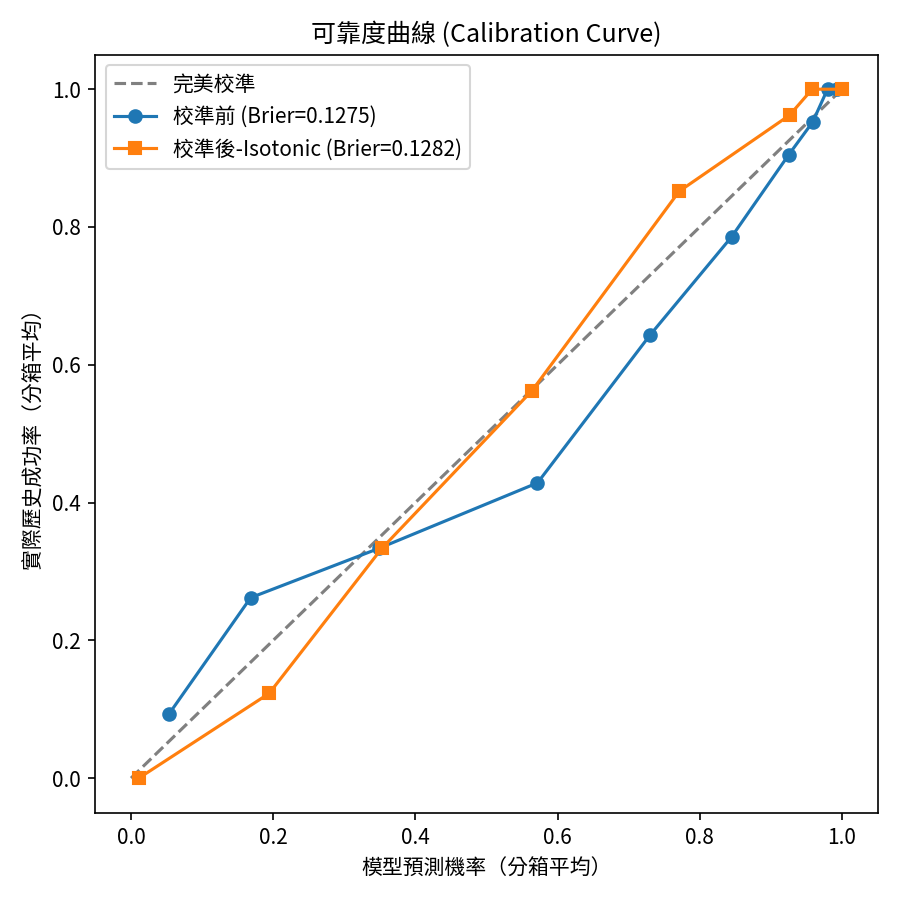

SHAP 全域特徵重要性：


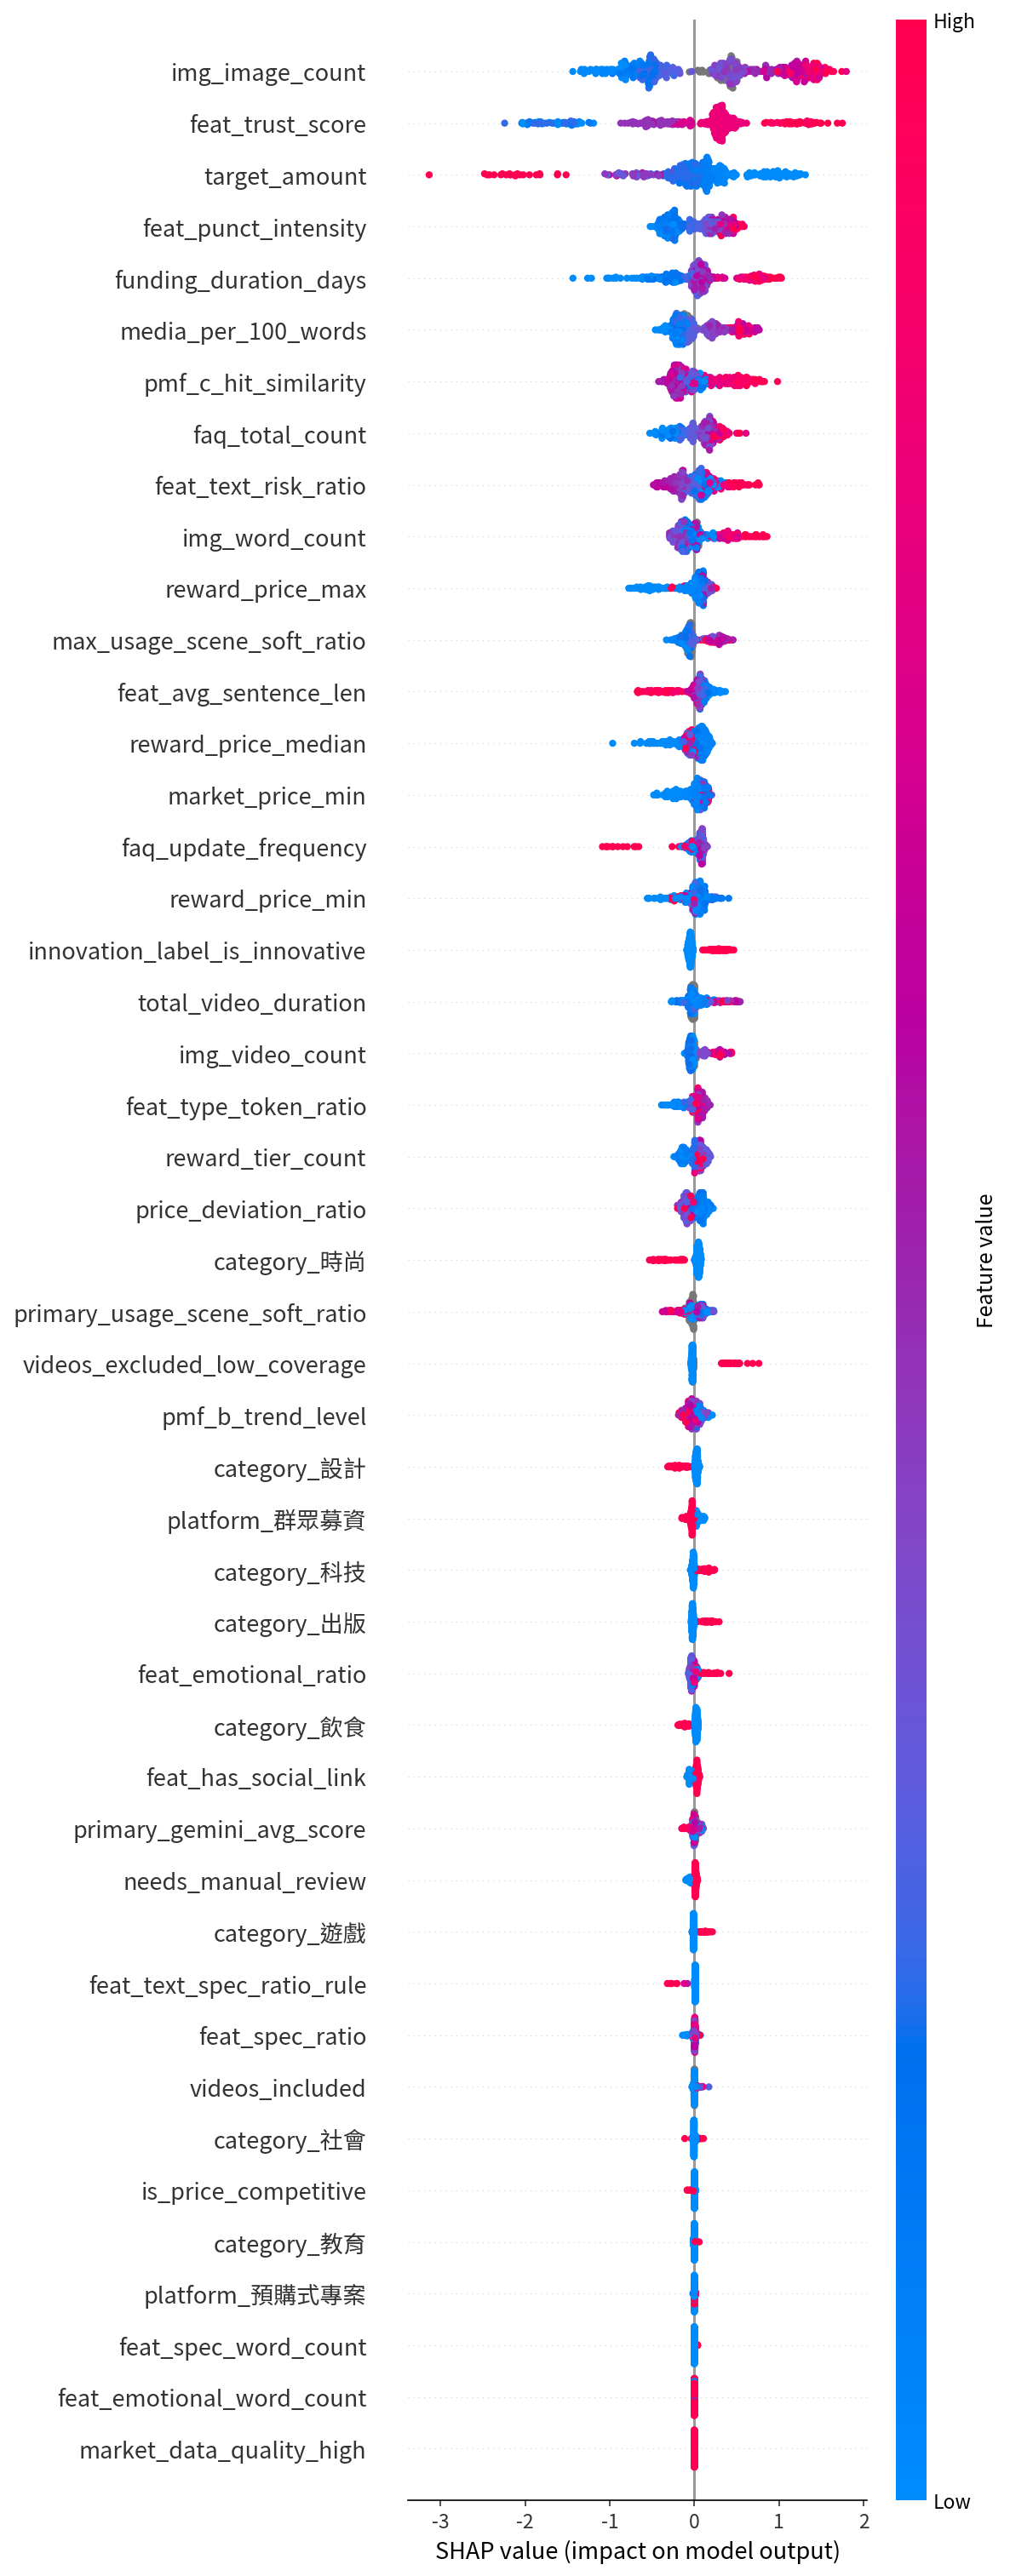

特徵影響程度排行 (Mean |SHAP value|)：


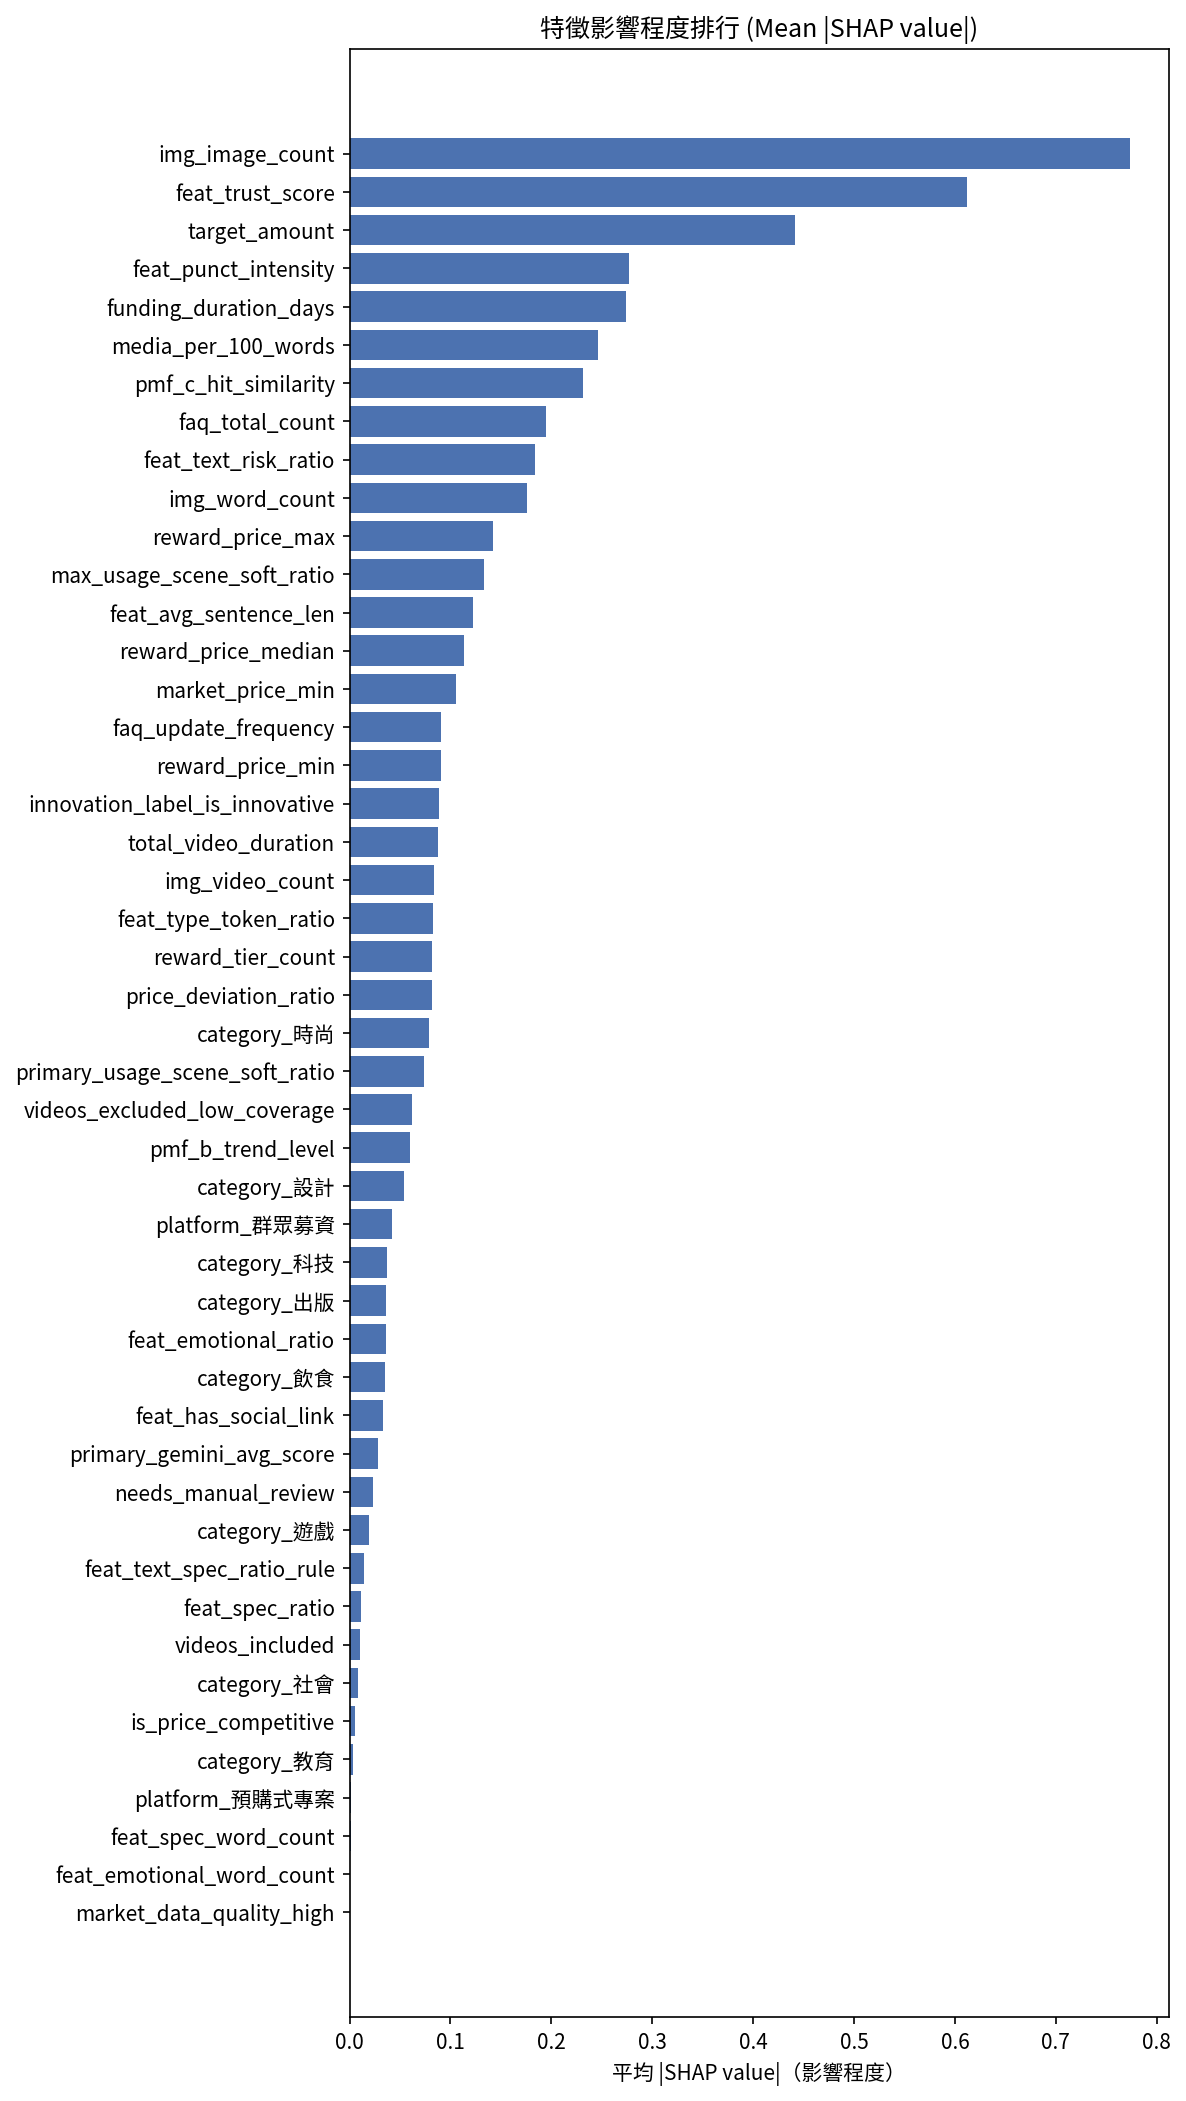

特徵相關係數熱力圖（特徵 vs 特徵，找共線的一組一組）：


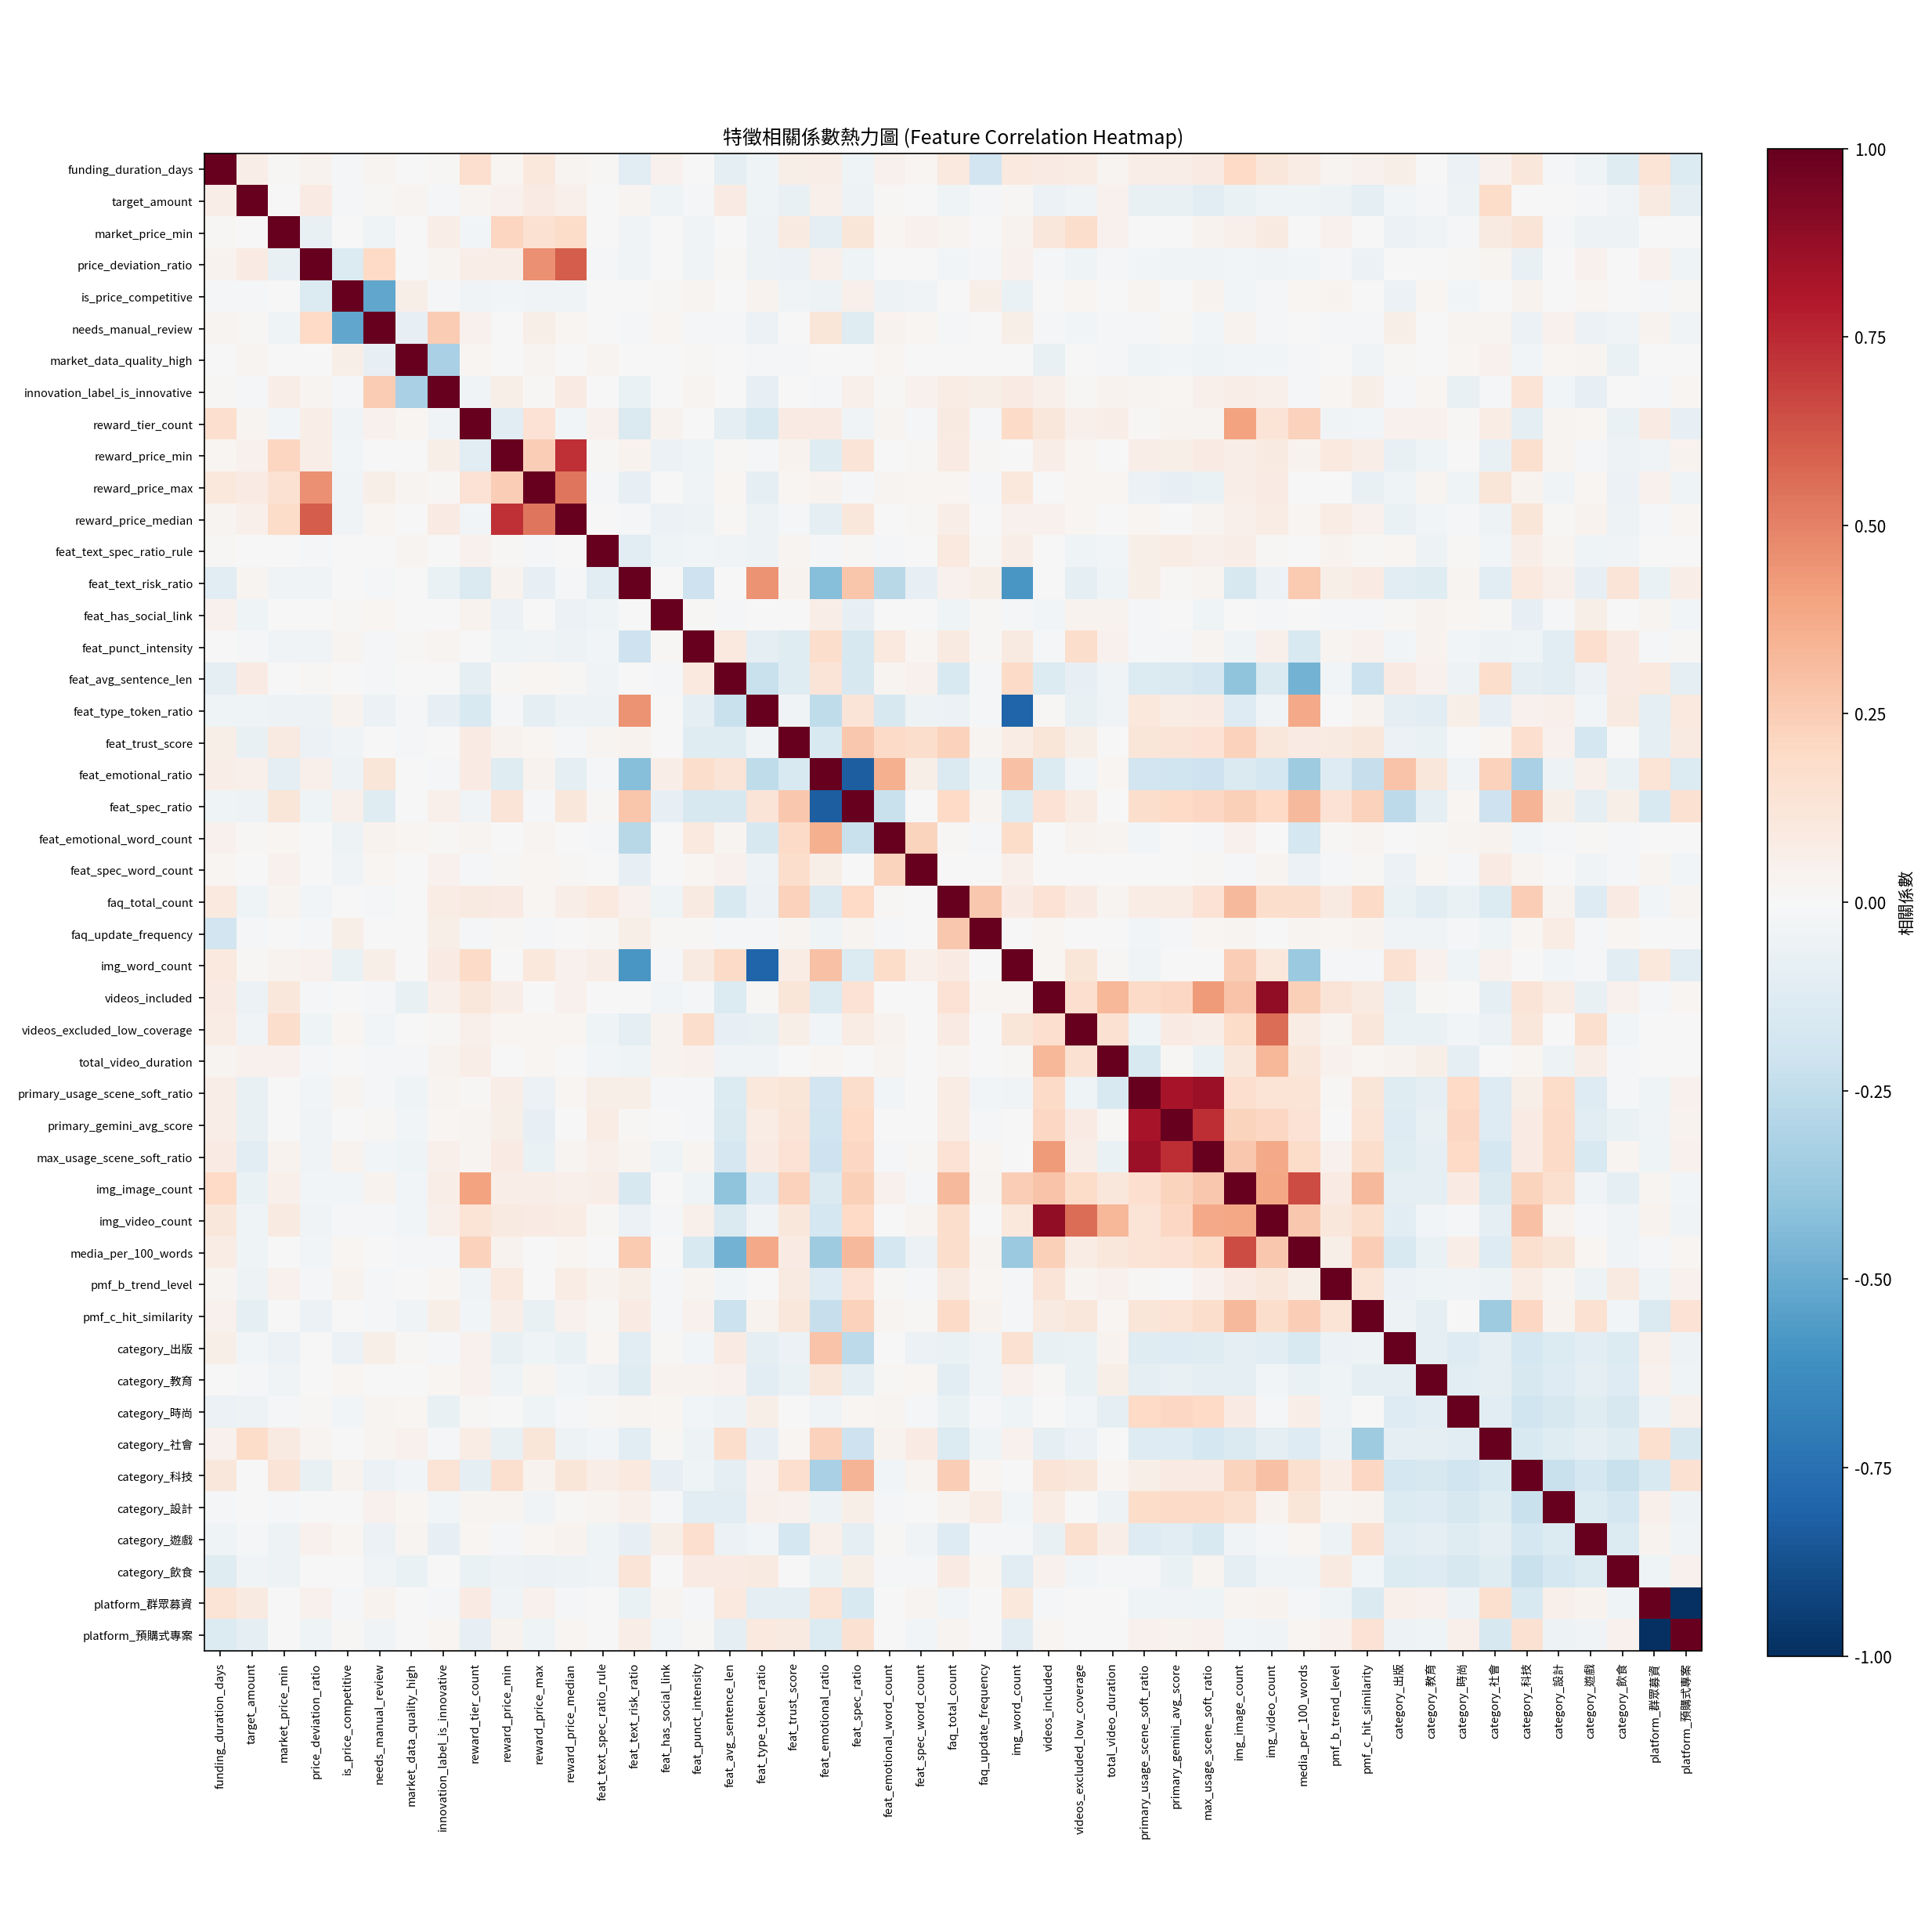

特徵 vs 標籤相關係數長條圖（哪些特徵跟成功/失敗線性相關、方向如何）：


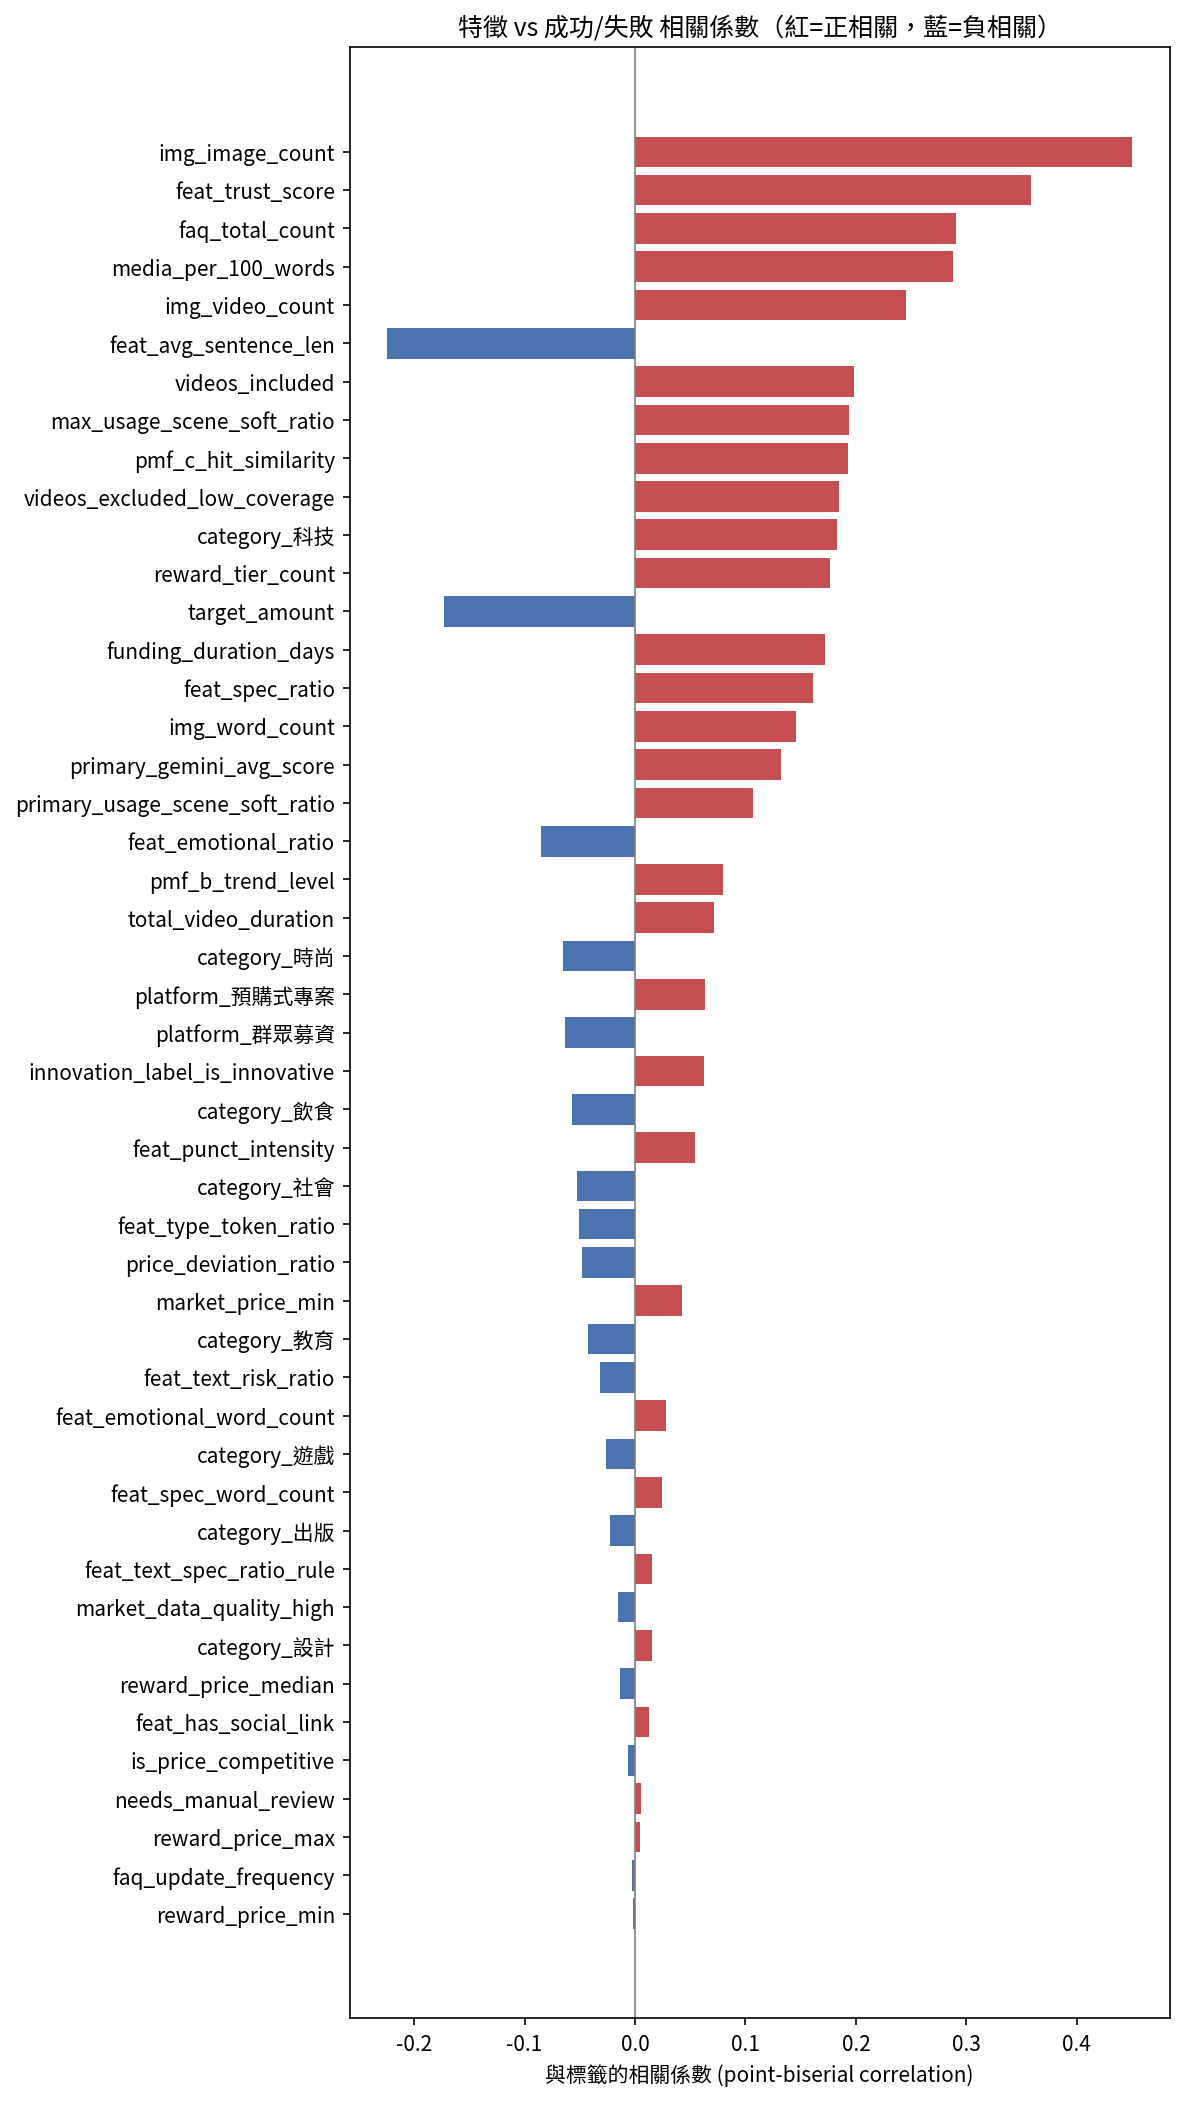

In [9]:
from IPython.display import Image, display

print("可靠度曲線 (Calibration Curve)：")
display(Image(filename=os.path.join(OUTPUT_DIR, "calibration_curve.png")))

print("SHAP 全域特徵重要性：")
display(Image(filename=os.path.join(OUTPUT_DIR, "shap_summary.png")))

print("特徵影響程度排行 (Mean |SHAP value|)：")
display(Image(filename=os.path.join(OUTPUT_DIR, "shap_importance_bar.png")))

print("特徵相關係數熱力圖（特徵 vs 特徵，找共線的一組一組）：")
display(Image(filename=os.path.join(OUTPUT_DIR, "feature_correlation_heatmap.png")))

print("特徵 vs 標籤相關係數長條圖（哪些特徵跟成功/失敗線性相關、方向如何）：")
display(Image(filename=os.path.join(OUTPUT_DIR, "feature_label_correlation.png")))

## 8.5 時間切分穩健性驗證：資料異常提醒／市場結構斷點／walk-forward（含滑動窗）／超參數穩健性檢查／誠實版模型機率品質

針對「隨機切分 AUC 容易虛高、時間切分才反映真實上線表現」這個核心問題，這裡依序做這些事，**輸出檔案已盡量合併，不逐項各存一份**：

1. **市場結構斷點檢查**（`market_structure_over_time(...)`）：按季（`MARKET_STRUCTURE_FREQ`）看幾個模型最倚重的定價/回饋方案特徵中位數，找哪一期出現跳動遠超過正常波動的斷點；同時標記「樣本過少＋成功率剛好0%/100%」的疑似資料品質異常期別，並自動算出一個可參考的 `MIN_DATE` 建議值（不會自動套用，供人工查證後決定）。存成 `market_structure_over_time.csv`。
2. **`MIN_DATE` 篩選**：查證確認某段早期資料有問題後，在 cell 8 設定，所有時間切分相關檢查（walk-forward／超參數搜尋／誠實版模型）都會排除更早的資料；市場結構斷點檢查本身不受影響（要看完整歷史才找得出問題區段）。
3. **時間切分超參數搜尋**：在 expanding window 上找比預設參數更適合時間切分的參數組合，每組候選都記錄在 `hyperparam_search_experiment_log.csv`。
4. **超參數穩健性檢查**：上一步選出的「最佳參數」只在 walk-forward 折數上驗證過，容易選到「討好那幾折」但換到真正的測試集反而更差的組合——這裡額外拿最佳參數跟預設參數在最終單一切分測試上正面比較，輸的話自動改用預設參數，並印出判斷依據，不會照單全收。
5. **Walk-forward 三種方法比較**：expanding window（預設參數）、expanding window（穩健性檢查後採用的參數）、固定滑動窗（`walk_forward_sliding_window(...)`，只用最近 `TRAIN_WINDOW_MONTHS` 個月訓練；訓練樣本過少的視窗會自動跳過，避免小樣本假性完美污染平均值）——三種合併成同一份 `walk_forward_results.csv` / `walk_forward_auc.png`。
6. **誠實版模型的機率品質重驗＋校準**：直接對「時間切分＋穩健性檢查後採用的參數」訓練出的誠實版模型重新算 ECE / KS / Brier；`USE_HONEST_CALIBRATION_SPLIT=True` 時會從訓練區段尾端切一塊校準集，需要的話套用 Isotonic，解決時間切分原本沒有獨立校準集、機率容易系統性偏移的問題。結果併入 `time_based_holdout_check.json`。

所有數字的純量摘要在 `experiment_summary.json`；特徵層級的診斷（洩漏/共線性/是否被移除）合併在 `feature_diagnostics.csv`；完整訓練特徵清單在 `features_used.csv`。主控台預設只印精簡摘要（`VERBOSE_DIAGNOSTICS=False`），想看逐折/逐期/逐特徵明細把這個參數改 `True` 重跑即可。


 📊 實驗總表（本次所有驗證結果彙整）
{
  "隨機切分_AUC": 0.8993,
  "隨機切分_AUC_健檢": "✅ 落在合理範圍",
  "min_date_篩選門檻": null,
  "市場結構_疑似有斷點": true,
  "市場結構_疑似資料品質異常期別數": 3,
  "時間切分_誠實版單一切分_AUC": 0.7007,
  "時間切分_誠實版單一切分_AUC_健檢": "✅ 落在合理範圍",
  "誠實版模型_是否套用校準": true,
  "誠實版模型_ECE": 0.0472,
  "誠實版模型_KS統計量": 0.416,
  "walk_forward_最穩方法": "sliding_window",
  "walk_forward_最穩方法_平均AUC標準差": "0.7987 ± 0.1103",
  "超參數搜尋_預設參數平均AUC": 0.7279,
  "超參數搜尋_最佳參數平均AUC": 0.7695,
  "超參數穩健性檢查_最終採用": "超參數搜尋最佳參數",
  "超參數穩健性檢查_實際套用參數": {
    "max_depth": 2,
    "learning_rate": 0.03,
    "n_estimators": 600,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "min_child_weight": 5,
    "reg_lambda": 5.0
  },
  "訓練特徵數": 47,
  "PMF特徵位移_觸發略有位移以上數量": 0
}

市場結構斷點檢查（按期看關鍵特徵中位數 + 成功率）：


,period,n,success_rate,reward_price_min_median,reward_price_max_median,reward_tier_count_median,target_amount_median,price_deviation_ratio_median,funding_duration_days_median,flag_data_quality_suspect
0,2019Q1,1,0.000000,1680.0,62180.0,10.0,250000.0,0.51160,61.0,True
1,2019Q2,5,0.200000,535.0,5000.0,5.0,150000.0,-0.16670,38.0,False
2,2019Q3,3,0.666667,1149.5,22444.5,5.0,50000.0,0.43320,79.0,False
3,2019Q4,2,0.000000,375.5,9950.0,6.5,74400.0,2.13185,69.0,True
4,2020Q2,1,0.000000,450.0,2100.0,4.0,50000.0,0.67220,44.0,True
5,2020Q3,6,0.500000,510.0,7150.0,6.5,100000.0,0.19895,45.5,False
6,2020Q4,6,0.500000,374.5,9700.0,6.0,100000.0,1.33045,60.0,False
7,2021Q1,10,0.600000,699.0,9345.0,5.0,100000.0,3.71165,43.0,False
8,2021Q2,11,0.181818,770.0,3588.0,5.0,100000.0,0.81730,46.0,False
9,2021Q3,27,0.148148,600.0,4700.0,6.0,100000.0,1.22220,45.0,False



Walk-forward AUC 穩定性比較（expanding 預設/最佳參數 vs 固定滑動窗）：


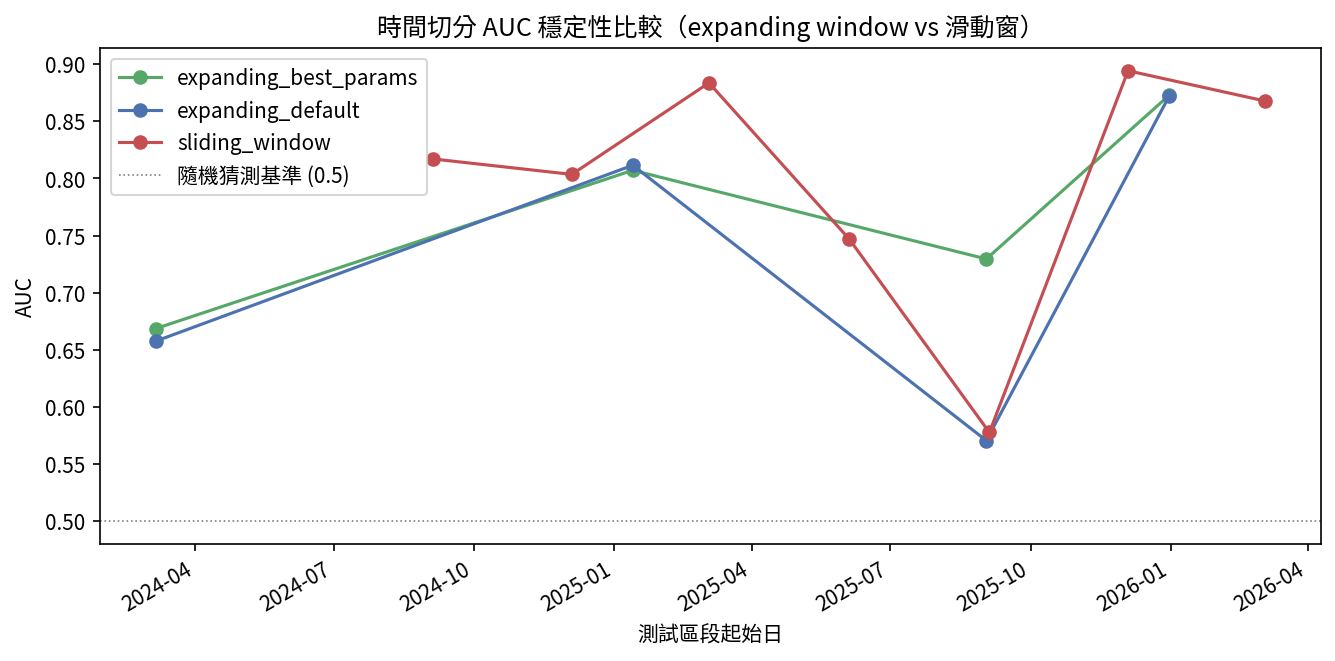

各方法彙整（平均/標準差/折數）：


,mean,std,min,max,count
method,,,,,
expanding_best_params,0.7695,0.0892,0.6686,0.8728,4
expanding_default,0.7280,0.1384,0.5706,0.8721,4
sliding_window,0.7987,0.1103,0.5777,0.8942,7



各視窗詳細數字：


,fold,n_train,n_test,train_start,train_end,test_start,test_end,auc,brier,method
0,1,424,420,2019-03-04,2024-03-06,2024-03-06,2025-01-13,0.6576,0.4151,expanding_default
1,2,844,420,2019-03-04,2025-01-13,2025-01-13,2025-09-02,0.8115,0.2222,expanding_default
2,3,1264,420,2019-03-04,2025-09-02,2025-09-02,2025-12-31,0.5706,0.3080,expanding_default
3,4,1684,420,2019-03-04,2025-12-31,2025-12-31,2026-06-30,0.8721,0.1379,expanding_default
4,1,424,420,2019-03-04,2024-03-06,2024-03-06,2025-01-13,0.6686,0.3621,expanding_best_params
5,2,844,420,2019-03-04,2025-01-13,2025-01-13,2025-09-02,0.8071,0.2198,expanding_best_params
6,3,1264,420,2019-03-04,2025-09-02,2025-09-02,2025-12-31,0.7295,0.2756,expanding_best_params
7,4,1684,420,2019-03-04,2025-12-31,2025-12-31,2026-06-30,0.8728,0.1371,expanding_best_params
8,1,322,141,2023-09-04,2024-09-03,2024-09-04,2024-12-03,0.8170,0.1987,sliding_window
9,2,396,116,2023-12-04,2024-12-03,2024-12-04,2025-03-03,0.8035,0.1951,sliding_window



超參數搜尋實驗紀錄（每一組候選參數都列出，取平均 AUC 最高者為最佳參數）：


,trial,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,min_child_weight,reg_lambda,mean_auc,std_auc,n_folds
0,7,2,0.03,600,0.90,0.90,5,5.0,0.769500,0.077242,4
1,5,2,0.05,400,0.85,0.85,1,1.0,0.752825,0.101974,4
2,3,3,0.03,600,0.80,0.80,3,2.0,0.750100,0.094701,4
3,4,3,0.05,400,0.90,0.70,5,3.0,0.747700,0.094292,4
4,6,4,0.02,800,0.80,0.80,3,2.0,0.744375,0.111063,4
5,1,3,0.05,400,0.85,0.85,1,1.0,0.732900,0.108744,4
6,2,4,0.05,400,0.85,0.85,1,1.0,0.727950,0.119862,4



特徵分布位移排行（紅色=PMF 市場契合度特徵）：


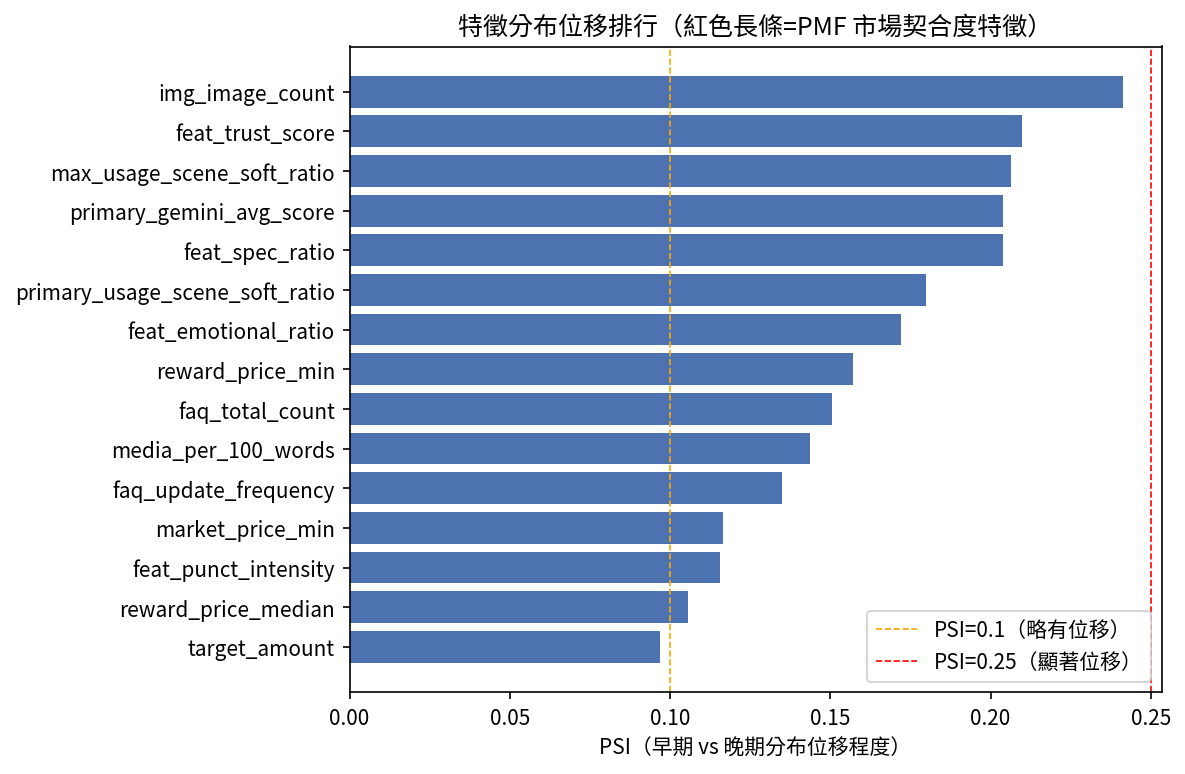

,feature,is_pmf,psi,ks_stat,train_mean,test_mean
0,img_image_count,False,0.2413,0.2298,33.7390,41.4361
1,feat_trust_score,False,0.2099,0.1944,80.6364,83.8314
2,max_usage_scene_soft_ratio,False,0.2063,0.1827,0.3146,0.4179
3,feat_spec_ratio,False,0.2039,0.2065,0.4924,0.5573
4,primary_gemini_avg_score,False,0.2039,0.2013,41.8798,53.0933
5,primary_usage_scene_soft_ratio,False,0.1799,0.1638,0.2681,0.3557
6,feat_emotional_ratio,False,0.1720,0.1845,0.4754,0.4173
7,reward_price_min,False,0.1571,0.1876,2630.8045,3305.3967
8,faq_total_count,False,0.1506,0.1696,6.6506,8.7387
9,media_per_100_words,False,0.1436,0.1659,2.4138,2.7581



特徵洩漏/共線性診斷（相關係數+VIF+是否移除）：


,feature,corr_with_label,vif,removed,removal_reason
0,market_price_max,0.0239,2.125000e+01,True,VIF=20.4，與其他特徵高度共線
1,mean_gemini_avg_score,0.1257,1.746000e+01,True,VIF=15.9，與其他特徵高度共線
2,mean_usage_scene_soft_ratio,0.1353,6.987000e+01,True,VIF=69.8，與其他特徵高度共線
3,duration_weighted_usage_scene_ratio,0.1295,3.894000e+01,True,VIF=12.9，與其他特徵高度共線
4,reward_price_mean,-0.0067,1.213300e+02,True,VIF=121.3，與其他特徵高度共線
5,project_core_price,-0.0060,3.626000e+01,True,VIF=31.9，與其他特徵高度共線
6,feat_text_story_ratio,0.0276,4.715605e+08,True,VIF=471560522.2，與其他特徵高度共線
7,pmf_a_recent_category_success_rate,0.1601,4.003100e+03,True,VIF=470.0，與其他特徵高度共線
8,pmf_d_market_saturation_count,0.1719,5.702570e+03,True,VIF=5702.5，與其他特徵高度共線
9,pmf_b_trend_level,0.0797,1.080000e+00,False,NaN



誠實版（時間切分，最終採用：超參數搜尋最佳參數）模型 — AUC + 機率品質重驗（ECE/KS 等）：
{
  "time_based_auc": 0.7007042253521127,
  "time_based_brier": 0.12516337359794888,
  "n_train": 1346,
  "n_cal": 337,
  "n_test": 421,
  "calibration_applied": true,
  "random_split_auc": 0.8993103110937193,
  "auc_gap": 0.19860608574160654,
  "honest_model_calibration": {
    "brier_score": 0.1252,
    "ece": 0.0472,
    "mean_bias": -0.0271,
    "mean_bias_direction": "保守",
    "ks_statistic": 0.416,
    "pr_auc": 0.9076,
    "precision": 0.8682,
    "recall": 0.9465,
    "f1": 0.9057
  }
}

誠實版單一專案報告 — 專案 GF4_elementquest：
  誠實版模型機率：78.2%（B+（穩健））
  對照：single_project_report.json（隨機切分版，已校準）機率：50.5%（C（偏保留，風險偏高））
  ⚠️ 兩份報告的測試集索引不同（隨機切分/時間切分的測試集不同），比較時請以「量級是否接近」為主，不要逐位數對比。


In [10]:
import json as _json

print("=" * 55)
print(" 📊 實驗總表（本次所有驗證結果彙整）")
print("=" * 55)
with open(os.path.join(OUTPUT_DIR, "experiment_summary.json"), encoding="utf-8") as f:
    summary = _json.load(f)
print(_json.dumps(summary, ensure_ascii=False, indent=2))

ms_path = os.path.join(OUTPUT_DIR, "market_structure_over_time.csv")
if os.path.exists(ms_path):
    print("\n市場結構斷點檢查（按期看關鍵特徵中位數 + 成功率）：")
    display(pd.read_csv(ms_path))
else:
    print("\n（沒有市場結構斷點檢查——可能是沒有日期資訊，或 ENABLE_MARKET_STRUCTURE_CHECK=False）")

wf_path = os.path.join(OUTPUT_DIR, "walk_forward_auc.png")
if os.path.exists(wf_path):
    print("\nWalk-forward AUC 穩定性比較（expanding 預設/最佳參數 vs 固定滑動窗）：")
    display(Image(filename=wf_path))
    wf_df = pd.read_csv(os.path.join(OUTPUT_DIR, "walk_forward_results.csv"))
    print("各方法彙整（平均/標準差/折數）：")
    display(wf_df.groupby("method")["auc"].agg(["mean", "std", "min", "max", "count"]).round(4))
    print("\n各視窗詳細數字：")
    display(wf_df)
else:
    print("\n（沒有 walk-forward 結果檔——可能是沒有日期資訊、資料量不足，或相關開關為 False）")

hp_path = os.path.join(OUTPUT_DIR, "hyperparam_search_experiment_log.csv")
if os.path.exists(hp_path):
    print("\n超參數搜尋實驗紀錄（每一組候選參數都列出，取平均 AUC 最高者為最佳參數）：")
    display(pd.read_csv(hp_path).sort_values("mean_auc", ascending=False))

shift_path = os.path.join(OUTPUT_DIR, "feature_distribution_shift.png")
if os.path.exists(shift_path):
    print("\n特徵分布位移排行（紅色=PMF 市場契合度特徵）：")
    display(Image(filename=shift_path))
    display(pd.read_csv(os.path.join(OUTPUT_DIR, "feature_distribution_shift.csv")))

diag_path = os.path.join(OUTPUT_DIR, "feature_diagnostics.csv")
if os.path.exists(diag_path):
    print("\n特徵洩漏/共線性診斷（相關係數+VIF+是否移除）：")
    display(pd.read_csv(diag_path))

honest_json_path = os.path.join(OUTPUT_DIR, "time_based_holdout_check.json")
if os.path.exists(honest_json_path):
    with open(honest_json_path, encoding="utf-8") as f:
        honest_check = _json.load(f)
    params_used = summary.get("超參數穩健性檢查_最終採用", "未知")
    print(f"\n誠實版（時間切分，最終採用：{params_used}）模型 — AUC + 機率品質重驗（ECE/KS 等）：")
    print(_json.dumps(honest_check, ensure_ascii=False, indent=2))

honest_report_path = os.path.join(OUTPUT_DIR, "time_based_single_project_report.json")
if os.path.exists(honest_report_path):
    with open(honest_report_path, encoding="utf-8") as f:
        honest_report = _json.load(f)
    print(f"\n誠實版單一專案報告 — 專案 {honest_report.get('project_id')}：")
    print(f"  誠實版模型機率：{honest_report['score_100']}%（{honest_report['grade']}）")
    print(f"  對照：single_project_report.json（隨機切分版，已校準）機率："
          f"{result['single_project_result']['score_100']}%（{result['single_project_result']['grade']}）")
    print(f"  ⚠️ 兩份報告的測試集索引不同（隨機切分/時間切分的測試集不同），"
          f"比較時請以「量級是否接近」為主，不要逐位數對比。")


## 9. 檢視單一專案報告

In [11]:
import json
with open(os.path.join(OUTPUT_DIR, "single_project_report.json"), encoding="utf-8") as f:
    print(json.dumps(json.load(f), ensure_ascii=False, indent=2))

{
  "raw_model_probability": 56.5,
  "final_calibrated_probability": 50.5,
  "score_100": 50.5,
  "grade": "C（偏保留，風險偏高）",
  "top_feature_contribution_pct": {
    "target_amount": 16.1,
    "img_image_count": -15.79,
    "feat_avg_sentence_len": -11.81,
    "feat_trust_score": -8.99,
    "innovation_label_is_innovative": 7.32,
    "feat_punct_intensity": 6.93,
    "media_per_100_words": -5.0,
    "faq_total_count": 3.76
  },
  "dimension_contribution_pct": {
    "1. 專案執行力": 15.91,
    "2. 價格競爭力": 15.17,
    "3. 文案說服力": -12.33,
    "4. 影像吸引力": -21.94,
    "5. 市場契合度(PMF)": -2.77,
    "6. 專案屬性": 0.61
  }
}


## 10. 模型檔

`run_pipeline(...)` 已經把訓練好的模型存成 `model_bundle.joblib`（在 `OUTPUT_DIR` 底下），
裡面包含模型本身、Isotonic 校準器（如果有套用的話）、特徵清單、維度對應表。
之後不用重新跑一次訓練，直接載入這個檔案就能對新專案評分。

In [12]:
print(f"模型檔位置：{result['model_path']}")

模型檔位置：/content/output/model_bundle.joblib


## 11. `predict.py` —— 對新專案評分 / 小型真實測試

- **純預測**：只知道特徵、不知道實際結果（例如評估一個還在募資中的新專案）
- **小型真實測試**：這幾筆專案已經知道實際成功/失敗，想驗證模型準不準——把 `target_col` 設成
  你的標籤欄位名稱，會多印出這批小樣本的 AUC / Brier Score，方便肉眼核對每一筆的預測是否準確

新資料不需要跟訓練時欄位完全一致：缺的特徵欄位自動補 NaN，多的欄位自動忽略。

In [13]:
# -*- coding: utf-8 -*-
"""
predict.py
==========
載入 crowdfunding_model.py 訓練完存下來的模型檔（model_bundle.joblib），
對「新的」或「留出來沒拿去訓練」的真實專案評分——這就是「小型真實測試」的工具。

兩種用法：

1) 純預測（不知道實際結果，例如評估一個還在募資中的新專案）：
   python predict.py --model model_bundle.joblib --csv new_projects.csv

2) 小型真實測試（已經知道這幾筆專案實際成功/失敗，想驗證模型準不準）：
   python predict.py --model model_bundle.joblib --csv holdout_projects.csv --target label
   （多加 --target 之後，會額外印出這批小樣本的 AUC / Brier Score，
     並逐筆列出「預測機率 vs 實際結果」方便肉眼核對）

輸入的 CSV 不需要跟訓練時欄位完全一致：
  - 缺少的特徵欄位會自動補 NaN（交給 XGBoost 原生處理，就跟訓練時處理跨類別缺值一樣）
  - 多出來的欄位會被忽略
  - 如果有 project_id 欄位，輸出時會一併帶著方便對照
"""

import argparse
import json

import numpy as np
import pandas as pd
from scipy.special import expit
from sklearn.metrics import brier_score_loss, roc_auc_score

def score_new_projects(model_path: str, csv_path: str, target_col: str | None = None,
                        id_col: str = "project_id", top_k_features: int = 5):
    bundle = load_model_bundle(model_path)
    model = bundle["model"]
    iso = bundle["isotonic"]
    all_features = bundle["all_features"]
    dimension_map = bundle["dimension_map"]

    df_new = pd.read_csv(csv_path)
    missing_cols = [f for f in all_features if f not in df_new.columns]
    if missing_cols:
        print(f"  ⚠️ 這批新資料缺少 {len(missing_cols)} 個訓練時用過的特徵欄位，"
              f"會以 NaN 補上（不會用其他值去猜）：{missing_cols}")

    ids = df_new[id_col] if id_col in df_new.columns else pd.Series(range(len(df_new)), name="row_index")
    X_new = df_new.reindex(columns=all_features)  # 缺的欄位自動變 NaN，多的欄位自動捨棄

    raw_prob = model.predict_proba(X_new)[:, 1]
    final_prob = iso.transform(raw_prob) if iso is not None else raw_prob

    explainer = build_shap_explainer(model, X_new)
    results = []
    for i in range(len(X_new)):
        row_result = explain_project(explainer, model, iso, X_new.iloc[[i]], all_features, dimension_map)
        top_feats = list(row_result["top_feature_contribution_pct"].items())[:top_k_features]
        results.append({
            "project_id": ids.iloc[i],
            "final_probability_pct": row_result["final_calibrated_probability"],
            "top_feature_contributions_pct": dict(top_feats),
        })

    out_df = pd.DataFrame([{
        "project_id": r["project_id"],
        "final_probability_pct": r["final_probability_pct"],
    } for r in results])

    if target_col and target_col in df_new.columns:
        y_true = df_new[target_col].astype(int).values
        out_df["actual_label"] = y_true
        out_df["correct_direction"] = (
            (out_df["final_probability_pct"] >= 50) == (y_true == 1)
        )
        auc = roc_auc_score(y_true, final_prob) if len(set(y_true)) > 1 else float("nan")
        brier = brier_score_loss(y_true, final_prob / 100 if final_prob.max() > 1 else final_prob)
        print(f"\n[小型真實測試結果]（{len(df_new)} 筆）")
        print(f"  AUC = {auc:.4f}" if not np.isnan(auc) else "  AUC 無法計算（這批資料只有單一類別）")
        print(f"  Brier Score = {brier:.4f}")
        print(f"  方向判斷正確率（機率≥50%視為預測成功）= {out_df['correct_direction'].mean():.1%}")

    return out_df, results


# 註：命令列版本的 main()/argparse 在 notebook 裡不需要，
# 這裡直接在下面的 cell 手動呼叫 score_new_projects(...)。


## 12. 執行小型真實測試

把 `TEST_CSV` 換成你要測試的一小批真實專案（例如最近剛結束、還沒被拿去訓練的專案）。
如果這批資料裡有實際結果欄位，把 `TEST_TARGET_COL` 設成該欄位名稱；
不知道實際結果的話就設成 `None`，只會印出預測機率。
⚠️ 這裡預設用的 `true_holdout_150.csv`，是 `train_production_model()` 內部切出來、沒被拿去訓練/早停的那 150 筆——跟前面算出「正式上線模型 AUC=...」用的是**同一批**測試資料，這個 cell 只是示範 `score_new_projects()` 的評分流程能不能正常運作，不是額外的獨立驗證。真正要驗證模型在全新資料上的表現，要換成模型訓練時完全沒接觸過的另一批專案（例如比 `META_OUT_PATH` 裡最新日期更晚才結束的專案）。


In [14]:
merged_for_test = _prepare_time_sorted_data(OUT_PATH, META_OUT_PATH, TARGET_COL, min_rows=60)
# ⚠️ 月數要跟 train_production_model() 實際用的一致，才能保證重建出來的 holdout_df
# 真的是它內部切出來、完全沒訓練過的那筆測試集——改引用 MONTHS_BACK_PRODUCTION，
# 不要寫死數字，避免改了參數卻忘記同步這裡
cutoff = merged_for_test["start_date"].max() - pd.DateOffset(months=MONTHS_BACK_PRODUCTION)
recent = merged_for_test[merged_for_test["start_date"] >= cutoff].reset_index(drop=True)

split_i = int(len(recent) * 0.8)
holdout_df = recent.iloc[split_i:]  # 模型訓練/早停驗證階段完全沒看過的那一段

print(f"真正沒看過的 holdout 筆數：{len(holdout_df)}")
print(f"期間：{holdout_df['start_date'].min().date()} ~ {holdout_df['start_date'].max().date()}")

HOLDOUT_CSV = os.path.join(OUTPUT_DIR, "true_holdout_recent.csv")
holdout_df.to_csv(HOLDOUT_CSV, index=False, encoding="utf-8-sig")

真正沒看過的 holdout 筆數：150
期間：2026-04-08 ~ 2026-06-30


In [15]:
print("⚠️ 提醒：下面這批是正式模型訓練時切出來的內部測試集，"
      "不是新的獨立驗證，只是示範評分流程——結果應該會跟前面 AUC/ECE 的量級一致。")

TEST_CSV = os.path.join(OUTPUT_DIR, "true_holdout_recent.csv")
TEST_TARGET_COL = "label"

out_df, results = score_new_projects(
    model_path=prod_result["model_path"],
    csv_path=TEST_CSV,
    target_col=TEST_TARGET_COL,
)
out_df.head(10)

⚠️ 提醒：下面這批是正式模型訓練時切出來的內部測試集，不是新的獨立驗證，只是示範評分流程——結果應該會跟前面 AUC/ECE 的量級一致。

[小型真實測試結果]（150 筆）
  AUC = 0.7968
  Brier Score = 0.1019
  方向判斷正確率（機率≥50%視為預測成功）= 88.0%


,project_id,final_probability_pct,actual_label,correct_direction
0,DS166_howchill5TigerGod,88.9,1,True
1,TS7_qi-vibe-x-x,88.9,1,True
2,DS165_rovelle-lumora,80.0,1,True
3,TS181_acergadget-fast-wireless-charger,94.7,1,True
4,TS177_thomson-dehumidifier,96.8,1,True
5,PS11_TheHeartSutra,88.9,1,True
6,TS180_k5-wcm,100.0,1,True
7,DS164_colorpik,88.9,1,True
8,TS179_R20BT,94.7,1,True
9,TS178_hyd-d-20-Air-Purifier,96.8,1,True


In [16]:
# 從 holdout_df 挑一筆模型沒看過的真實專案，用正式模型（近9個月訓練）產生 SHAP 解釋
sample_idx = 0
X_sample = holdout_df.iloc[[sample_idx]][prod_result["all_features"]]

single_project_result = explain_project(
    explainer=prod_result["explainer"],
    model=prod_result["model"],
    iso=load_model_bundle(prod_result["model_path"])["isotonic"],  # 正式模型有套校準，必須一起傳，否則會跟 score_new_projects 的機率不一致
    x_row=X_sample,
    all_features=prod_result["all_features"],
    dimension_map=prod_result["dimension_map"],
    # explain_project() 預設只留前 8 名特徵貢獻（給一般 JSON 輸出用，保持簡潔）；
    # 但下面 build_tagged_feature_list() 要挑前 10 名做紅黃綠分類給 Gemini 講解，
    # 這裡明確調高上限到 12，避免上游只給 8 個、下游要 10 個卻拿不滿的情況
    top_n_features=12,
)

print(f"專案：{holdout_df.iloc[sample_idx]['project_id']}")
print(f"實際結果：{'成功' if holdout_df.iloc[sample_idx]['label'] == 1 else '失敗'}")
print(f"模型評分：{single_project_result['score_100']} / 100（{single_project_result['grade']}）")

專案：DS166_howchill5TigerGod
實際結果：成功
模型評分：88.9 / 100（A（表現優異））


## 11.5 九個月正式版：部署門檻檢查（新增）

AUC/KS 決定排序可不可信，ECE 決定百分比可不可信，洩漏/共線性決定 SHAP 貢獻可不可信。所有數字用 9 個月窗口重算並附 bootstrap 95% 區間；輸出 `production_gate_report.csv`。
需先跑完 cell 15、27、29。

In [17]:
# -*- coding: utf-8 -*-
# ============================================================
# 9 個月正式版「部署門檻檢查」
#   AUC/KS   → 這個排序可不可信
#   ECE      → 這個百分比數字可不可信
#   洩漏/共線 → SHAP 拆解出來的每一項貢獻可不可信
# 需要先跑完：train_production_model / validate_recent_window_recipe（cell 15）與 holdout_df（cell 27）
# 所有數字都是「這個 cell 自己重算」，不是抄前面印出來的字串。
# ============================================================
import os, json
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score

# ---- 門檻（照你的表；要調整只改這裡）----
GATE = dict(
    auc_min=0.70, auc_std_max=0.08, ece_max=0.05, ks_min=0.30,
    single_feat_auc_max=0.95, vif_max=10.0,
)
N_BOOT = 1000
rng = np.random.default_rng(42)

# ---- 讀正式模型 + 校準器（校準器在 bundle 裡，prod_result 沒有回傳它）----
bundle = load_model_bundle(prod_result["model_path"])
p_model, p_iso, p_feats = bundle["model"], bundle["isotonic"], bundle["all_features"]

merged_p = _prepare_time_sorted_data(OUT_PATH, META_OUT_PATH, TARGET_COL, min_rows=60)
cutoff_p = merged_p["start_date"].max() - pd.DateOffset(months=MONTHS_BACK_PRODUCTION)
recent_p = merged_p[merged_p["start_date"] >= cutoff_p].reset_index(drop=True)
split_p = int(len(recent_p) * 0.8)
test_p = recent_p.iloc[split_p:]
y_te = test_p[TARGET_COL].astype(int).values

raw_te = p_model.predict_proba(test_p[p_feats])[:, 1]
prob_te = p_iso.transform(raw_te) if p_iso is not None else raw_te


def _ece(y, p, n_bins=10):
    return expected_calibration_error(np.asarray(y), np.asarray(p), n_bins)


def _boot_ci(fn, y, p, n=N_BOOT):
    vals = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if len(np.unique(y[idx])) < 2:
            continue
        vals.append(fn(y[idx], p[idx]))
    return np.percentile(vals, [2.5, 97.5])


def _ks(y, p):
    return ks_2samp(p[y == 1], p[y == 0]).statistic


rows = []   # (類別, 指標, 數值, 門檻, 狀態, 白話說明)


def add(cat, name, value, rule, ok, note):
    status = {True: "✅ 通過", False: "❌ 未過", None: "⚪ 無法判定"}[ok]
    rows.append((cat, name, value, rule, status, note))


# ===== 1) AUC =====
auc_pt = roc_auc_score(y_te, prob_te)
lo, hi = _boot_ci(roc_auc_score, y_te, prob_te)
n_neg = int((y_te == 0).sum())
add("AUC", "單點（近9個月測試集）", f"{auc_pt:.4f}（95%區間 {lo:.3f}~{hi:.3f}）", f"≥{GATE['auc_min']}",
    auc_pt >= GATE["auc_min"],
    f"測試集 {len(y_te)} 筆、其中失敗案例只有 {n_neg} 筆，區間下緣"
    f"{'仍' if lo >= GATE['auc_min'] else '已經'}{'高於' if lo >= GATE['auc_min'] else '低於'}門檻")

fold = recipe_stability_df["fold_report"]
mean_auc, std_auc0 = fold["auc"].mean(), fold["auc"].std(ddof=0)
std_auc1 = fold["auc"].std(ddof=1) if len(fold) > 1 else np.nan
add("AUC", "配方平均（回推各時間點）", f"{mean_auc:.4f}（{len(fold)}個時間點）", f"≥{GATE['auc_min']}",
    mean_auc >= GATE["auc_min"], "把「近9個月訓練」這個配方往回推重跑的平均")
add("配方穩定性", "AUC 標準差", f"{std_auc0:.4f}（樣本標準差 {std_auc1:.4f}）", f"≤{GATE['auc_std_max']}",
    max(std_auc0, std_auc1) <= GATE["auc_std_max"],
    "兩種算法都列出；時間點之間的訓練窗口互相重疊，實際獨立性比 4 個點看起來低")

# ===== 2) ECE =====
ece_pt = _ece(y_te, prob_te)
e_lo, e_hi = _boot_ci(_ece, y_te, prob_te)
add("ECE", "單點（校準後）", f"{ece_pt:.4f}（95%區間 {e_lo:.3f}~{e_hi:.3f}）", f"≤{GATE['ece_max']}",
    ece_pt <= GATE["ece_max"], "區間很寬：測試集太小，這個數字本身就會晃")
mean_ece = fold["ece"].mean()
add("ECE", "配方平均", f"{mean_ece:.4f}（標準差 {fold['ece'].std(ddof=0):.4f}）", f"≤{GATE['ece_max']}",
    mean_ece <= GATE["ece_max"], "決定能不能把「73%」當字面數字講的主要依據")

# ECE 雜訊底線：就算模型「完全校準」，這個測試集大小下 ECE 大概會是多少
sim = []
for _ in range(2000):
    p_sim = np.clip(rng.choice(prob_te, len(prob_te), replace=True)
                    + rng.normal(0, 0.02, len(prob_te)), 0.01, 0.99)
    y_sim = (rng.random(len(p_sim)) < p_sim).astype(int)
    sim.append(_ece(y_sim, p_sim))
floor_med, floor_lo, floor_hi = np.percentile(sim, [50, 5, 95])
add("ECE", "雜訊底線（完全校準時也會看到）", f"中位 {floor_med:.3f}（{floor_lo:.3f}~{floor_hi:.3f}）", "僅供參考",
    None, "若底線本身就接近 0.05，代表 0.05 這條線在這個樣本量下擋不準，要靠更多資料或合併多期評估")

# ===== 3) KS =====
ks_pt = _ks(y_te, prob_te)
k_lo, k_hi = _boot_ci(_ks, y_te, prob_te)
add("KS", "成功組 vs 失敗組分布區隔", f"{ks_pt:.3f}（95%區間 {k_lo:.3f}~{k_hi:.3f}）", f"≥{GATE['ks_min']}",
    ks_pt >= GATE["ks_min"], "9個月版之前沒有算過 KS，這是第一次補上")

# ===== 4) 單一特徵 AUC（用 9 個月窗口重算，不是沿用全歷史結果）=====
sf = []
for f in p_feats:
    s = recent_p[[f, TARGET_COL]].dropna()
    if s[f].nunique() < 2 or s[TARGET_COL].nunique() < 2:
        continue
    a = roc_auc_score(s[TARGET_COL].astype(int), s[f])
    sf.append((f, max(a, 1 - a)))     # 方向無關：取離 0.5 較遠的那一側
sf_df = pd.DataFrame(sf, columns=["feature", "single_auc"]).sort_values("single_auc", ascending=False)
top_f, top_a = sf_df.iloc[0]["feature"], sf_df.iloc[0]["single_auc"]
add("洩漏", "單一特徵 AUC 最高者", f"{top_f}＝{top_a:.3f}", f"全部<{GATE['single_feat_auc_max']}",
    top_a < GATE["single_feat_auc_max"], "在 9 個月窗口內、對 9 個月版實際用的特徵重算")

# ===== 5) VIF（同樣用 9 個月窗口重算）=====
vif_df = compute_vif(recent_p[p_feats])
vif_max = vif_df["vif"].max(skipna=True)
worst = vif_df.iloc[0]["feature"] if len(vif_df) else "-"
add("共線性", "VIF 最大值（已扣掉各組 one-hot 的參照類別）", f"{worst}＝{vif_max:.1f}", f"全部<{GATE['vif_max']}",
    vif_max < GATE["vif_max"], "原本的 VIF 篩選是用全歷史資料做的，這裡改用實際訓練窗口重算")

# 完全共線 / one-hot 全開：VIF 為了避免虛擬變數陷阱會先丟一欄，但模型與 SHAP 看到的是「全部欄位」
dup_msgs = []
for prefix in ("category_", "platform_"):
    cols = [c for c in p_feats if c.startswith(prefix)]
    if len(cols) >= 2:
        s = recent_p[cols].fillna(0).sum(axis=1)
        if (s == 1).all():
            dup_msgs.append(f"{prefix}* 共 {len(cols)} 欄加起來恆等於 1（互相完全共線）")
add("共線性", "one-hot 欄位是否全部保留", "；".join(dup_msgs) if dup_msgs else "無", "應為無",
    len(dup_msgs) == 0,
    "這種欄位 SHAP 會在同組欄位間任意分攤貢獻；報告時應把整組加總成一項（「所屬平台」「所屬類別」）")

# ===== 6) 市場結構 / 資料異常 =====
ms_path = os.path.join(OUTPUT_DIR, "market_structure_over_time.csv")
if os.path.exists(ms_path):
    ms = pd.read_csv(ms_path)
    bad = ms[(ms["n"] <= 5) & (ms["success_rate"].isin([0.0, 1.0]))]["period"].tolist()
    win_start = recent_p["start_date"].min()
    late_bad = [p for p in bad if pd.Period(p, freq="Q").end_time >= win_start]
    add("資料異常", "疑似異常期別（n≤5 且成功率剛好0%/100%）",
        f"{bad if bad else '無'}；MIN_DATE={MIN_DATE}；9個月窗口起點={win_start.date()}",
        "異常期別不得落在訓練窗口內", len(late_bad) == 0,
        "9個月版靠窗口自然避開早期異常；全歷史版（model_bundle.joblib）沒有處理，仍不可用")
else:
    add("資料異常", "市場結構檢查", "找不到 market_structure_over_time.csv", "-", None, "請先跑 8.5 節")

# ===== 7) 單一專案報告與正式評分是否一致 =====
mismatch_note = None
try:
    x1 = holdout_df.iloc[[0]][p_feats]
    raw1 = float(p_model.predict_proba(x1)[:, 1][0])
    cal1 = float(p_iso.transform([raw1])[0]) if p_iso is not None else raw1
    shown = single_project_result["final_calibrated_probability"] / 100
    if p_iso is not None and abs(shown - cal1) > 0.005:
        mismatch_note = (f"專案 {holdout_df.iloc[0]['project_id']}：正式評分（含校準）= {cal1*100:.1f}%，"
                         f"但 SHAP 單一專案報告顯示 {shown*100:.1f}%（沒套校準）。"
                         f"cell 29 的 explain_project(iso=None) 要改成 iso=bundle['isotonic']。")
except Exception as e:
    mismatch_note = f"（無法比對單一專案：{e}）"

# ---- 輸出 ----
report = pd.DataFrame(rows, columns=["類別", "指標", "數值", "門檻", "狀態", "說明"])
report.to_csv(os.path.join(OUTPUT_DIR, "production_gate_report.csv"), index=False, encoding="utf-8-sig")
sf_df.to_csv(os.path.join(OUTPUT_DIR, "production_single_feature_auc.csv"), index=False, encoding="utf-8-sig")

pd.set_option("display.max_colwidth", 120, "display.width", 250)
display(report)

fails = report[report["狀態"] == "❌ 未過"]["指標"].tolist()
rank_ok = all(report[report["類別"].isin(["AUC", "KS", "配方穩定性"]) & report["門檻"].str.startswith(("≥", "≤"))]["狀態"] == "✅ 通過")
ece_ok = all(report[(report["類別"] == "ECE") & (report["門檻"].str.startswith("≤"))]["狀態"] == "✅ 通過")
shap_ok = all(report[report["類別"].isin(["洩漏", "共線性"])]["狀態"] == "✅ 通過")

print("\n" + "=" * 60)
print(f"  排序可信（AUC/KS/穩定性）：{'✅' if rank_ok else '❌'}")
print(f"  百分比可信（ECE）        ：{'✅' if ece_ok else '❌'}")
print(f"  SHAP 拆解可信（洩漏/共線）：{'✅' if shap_ok else '❌'}")
print("=" * 60)
if rank_ok and not ece_ok:
    print("結論：只能用來做排序/風險分級；不要對外講精確百分比（改講「高/中/低」或區間）。")
if not shap_ok:
    print("結論：SHAP 每一項貢獻先不要當精確數字講，先處理上面標 ❌ 的洩漏/共線項目。")
if mismatch_note:
    print("⚠️ " + mismatch_note)
if fails:
    print("未通過項目：", fails)


,類別,指標,數值,門檻,狀態,說明
0,AUC,單點（近9個月測試集）,0.7968（95%區間 0.695~0.885）,≥0.7,✅ 通過,測試集 150 筆、其中失敗案例只有 23 筆，區間下緣已經低於門檻
1,AUC,配方平均（回推各時間點）,0.8031（4個時間點）,≥0.7,✅ 通過,把「近9個月訓練」這個配方往回推重跑的平均
2,配方穩定性,AUC 標準差,0.0377（樣本標準差 0.0436）,≤0.08,✅ 通過,兩種算法都列出；時間點之間的訓練窗口互相重疊，實際獨立性比 4 個點看起來低
3,ECE,單點（校準後）,0.0433（95%區間 0.024~0.101）,≤0.05,✅ 通過,區間很寬：測試集太小，這個數字本身就會晃
4,ECE,配方平均,0.0680（標準差 0.0260）,≤0.05,❌ 未過,決定能不能把「73%」當字面數字講的主要依據
5,ECE,雜訊底線（完全校準時也會看到）,中位 0.042（0.022~0.069）,僅供參考,⚪ 無法判定,若底線本身就接近 0.05，代表 0.05 這條線在這個樣本量下擋不準，要靠更多資料或合併多期評估
6,KS,成功組 vs 失敗組分布區隔,0.435（95%區間 0.290~0.646）,≥0.3,✅ 通過,9個月版之前沒有算過 KS，這是第一次補上
7,洩漏,單一特徵 AUC 最高者,feat_text_risk_ratio＝0.665,全部<0.95,✅ 通過,在 9 個月窗口內、對 9 個月版實際用的特徵重算
8,共線性,VIF 最大值（已扣掉各組 one-hot 的參照類別）,reward_price_median＝6.3,全部<10.0,✅ 通過,原本的 VIF 篩選是用全歷史資料做的，這裡改用實際訓練窗口重算
9,共線性,one-hot 欄位是否全部保留,category_* 共 8 欄加起來恆等於 1（互相完全共線）；platform_* 共 2 欄加起來恆等於 1（互相完全共線）,應為無,❌ 未過,這種欄位 SHAP 會在同組欄位間任意分攤貢獻；報告時應把整組加總成一項（「所屬平台」「所屬類別」）



  排序可信（AUC/KS/穩定性）：✅
  百分比可信（ECE）        ：❌
  SHAP 拆解可信（洩漏/共線）：❌
結論：只能用來做排序/風險分級；不要對外講精確百分比（改講「高/中/低」或區間）。
結論：SHAP 每一項貢獻先不要當精確數字講，先處理上面標 ❌ 的洩漏/共線項目。
未通過項目： ['配方平均', 'one-hot 欄位是否全部保留']


## 11.6 九個月正式版 v2：給「必須對外講精確百分比」的用法（新增）

Platt 校準＋樣本外校準資料（取代 ~120 筆的 Isotonic）、90% 機率區間、SHAP 貢獻換成**可相加的機率百分點**、one-hot 整組併成一項、每一項附穩定度標記。

**程式解不了的部分**：ECE 是否過門檻取決於資料量與模型本身；沒過時報告會自動附註記，不會假裝通過。
輸出：`model_bundle_production_v2.joblib`、`single_project_report_v2.json`。

In [18]:
# -*- coding: utf-8 -*-
# ============================================================
# 九個月正式版 v2：為「一定要對外講精確百分比、把 SHAP 貢獻當精確數字」而做的改版
#
# 這個版本能做到的（程式層面能解的）：
#   1. 機率：Platt(sigmoid) 校準，用「時間向前滾動的樣本外預測」湊出約 4 倍的校準資料，
#           取代只用 ~120 筆校準集的 Isotonic（不會再出現 100.0% 這種階梯值）
#   2. 機率附區間：30 組 bootstrap 模型＋校準器，報「點估計＋90% 區間」
#   3. SHAP：one-hot 完全共線的欄位先去掉參照類別、VIF 用 9 個月窗口重算；
#           貢獻換算成「機率百分點」，各項相加剛好等於「最終機率 − 基準機率」，
#           one-hot 整組併成一項（所屬類別／所屬平台）
#   4. SHAP 附穩定度：每一項貢獻報「平均±標準差」與「正負號一致率」，不穩的項目自動標記
#   5. 門檻沒過的時候，報告會自動帶上註記——這是程式不能替你解決的部分（見文末說明）
# ============================================================
import os, json, joblib
import numpy as np
import pandas as pd
import xgboost as xgb
from collections import OrderedDict
from scipy.special import expit, logit
from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

V2 = dict(months_back=MONTHS_BACK_PRODUCTION, n_boot=30, n_blocks=5,
          n_ckpt=RECIPE_N_CHECKPOINTS, ckpt_step=RECIPE_STEP_MONTHS,
          ece_max=0.05, vif_max=10.0, seed=42)
GROUP_PREFIX = {"category_": "所屬類別", "platform_": "所屬平台"}


class PlattCalibrator:
    """只有兩個參數的 sigmoid 校準器；輸出不會出現 0%/100% 的階梯值。"""
    def fit(self, p, y):
        z = logit(np.clip(np.asarray(p, float), 1e-4, 1 - 1e-4)).reshape(-1, 1)
        self.lr = LogisticRegression(C=1e6, max_iter=1000).fit(z, np.asarray(y, int))
        return self

    def transform(self, p):
        z = logit(np.clip(np.asarray(p, float), 1e-4, 1 - 1e-4)).reshape(-1, 1)
        return self.lr.predict_proba(z)[:, 1]


def _ece10(y, p):
    return expected_calibration_error(np.asarray(y), np.asarray(p), 10)


def _ks(y, p):
    y = np.asarray(y); p = np.asarray(p)
    return float(ks_2samp(p[y == 1], p[y == 0]).statistic)


def _drop_reference_levels(df, feats):
    """整組 one-hot 加起來恆等於 1 → 完全共線，丟掉最常見的那一欄當參照類別。"""
    drop = []
    for prefix in GROUP_PREFIX:
        cols = [c for c in feats if c.startswith(prefix)]
        if len(cols) >= 2 and (df[cols].fillna(0).sum(axis=1) == 1).all():
            drop.append(df[cols].fillna(0).sum().idxmax())
    return [f for f in feats if f not in drop], drop


def _vif_prune(X, vif_max, max_iter=30):
    cols = [c for c in X.columns if X[c].nunique(dropna=True) > 1]
    removed = []
    for _ in range(max_iter):
        if len(cols) < 2:
            break
        M = X[cols].fillna(X[cols].median()).values
        vifs = np.array([variance_inflation_factor(M, i) for i in range(len(cols))])
        vifs = np.where(np.isnan(vifs), np.inf, vifs)
        i = int(np.argmax(vifs))
        if vifs[i] < vif_max:
            return cols, removed, float(vifs.max())
        removed.append((cols[i], float(vifs[i])))
        cols.pop(i)
    return cols, removed, float("nan")


def _fit_one(part, feats, target, rng=None):
    k = max(1, int(len(part) * 0.85))
    fit_df, val_df = part.iloc[:k], part.iloc[k:]
    if rng is not None:
        fit_df = fit_df.iloc[rng.integers(0, len(fit_df), len(fit_df))]
    return train_xgb(fit_df[feats], fit_df[target].astype(int),
                     val_df[feats], val_df[target].astype(int))


def _oof_raw(train_df, feats, target, n_blocks):
    """時間向前滾動：用前面的區塊訓練、預測下一個區塊，湊出「沒看過答案」的預測，專門拿來擬合校準器。"""
    edges = np.linspace(0, len(train_df), n_blocks + 1).astype(int)
    ps, ys = [], []
    for j in range(1, n_blocks):
        tr, te = train_df.iloc[:edges[j]], train_df.iloc[edges[j]:edges[j + 1]]
        k = int(len(tr) * 0.85)
        if len(tr) < 80 or tr[target].nunique() < 2 or te[target].nunique() < 2 \
                or tr.iloc[k:][target].nunique() < 2:
            continue
        m = _fit_one(tr, feats, target)
        ps.append(m.predict_proba(te[feats])[:, 1]); ys.append(te[target].astype(int).values)
    if not ps:
        return None, None
    return np.concatenate(ps), np.concatenate(ys)


def fit_v2(recent, feats0, target, n_boot=0, seed=42):
    rng = np.random.default_rng(seed)
    split_i = int(len(recent) * 0.8)
    train_df, test_df = recent.iloc[:split_i], recent.iloc[split_i:]
    y_tr_all = train_df[target].astype(int)

    feats, dropped_ref = _drop_reference_levels(train_df, feats0)
    feats, vif_removed, vif_final = _vif_prune(train_df[feats], V2["vif_max"])

    p_oof, y_oof = _oof_raw(train_df, feats, target, V2["n_blocks"])
    if p_oof is None:
        return None
    cal = PlattCalibrator().fit(p_oof, y_oof)

    model = _fit_one(train_df, feats, target)
    y_te = test_df[target].astype(int).values
    raw_te = model.predict_proba(test_df[feats])[:, 1]
    p_te = cal.transform(raw_te)
    out = dict(model=model, calibrator=cal, features=feats, dropped_reference=dropped_ref,
               vif_removed=vif_removed, vif_max_final=vif_final, n_oof=len(p_oof),
               train_start=train_df["start_date"].min(), test_start=test_df["start_date"].min(),
               test_end=test_df["start_date"].max(), n_train=len(train_df), n_test=len(test_df),
               holdout=dict(y=y_te, p=p_te, raw=raw_te, ids=test_df["project_id"].values,
                            auc=float(roc_auc_score(y_te, p_te)) if len(set(y_te)) > 1 else np.nan,
                            ece=_ece10(y_te, p_te), ece_raw=_ece10(y_te, raw_te),
                            ks=_ks(y_te, p_te) if len(set(y_te)) > 1 else np.nan))
    sf = []
    for f in feats:
        s = recent[[f, target]].dropna()
        if s[f].nunique() > 1 and s[target].nunique() > 1:
            a = roc_auc_score(s[target].astype(int), s[f]); sf.append((f, max(a, 1 - a)))
    out["single_feat_auc_max"] = max(sf, key=lambda t: t[1]) if sf else (None, np.nan)

    members = []
    for _ in range(n_boot):
        m = _fit_one(train_df, feats, target, rng=rng)
        j = rng.integers(0, len(p_oof), len(p_oof))
        if len(set(y_oof[j])) < 2:
            continue
        members.append((m, PlattCalibrator().fit(p_oof[j], y_oof[j])))
    out["members"] = members
    return out


def recipe_v2(merged, feats0, target):
    """把整套 v2 流程往回推多個時間點，收集各時間點「沒看過的測試段」預測，另外算合併後的 ECE。"""
    rows, ys, ps, seen = [], [], [], set()
    max_date = merged["start_date"].max()
    for k in range(V2["n_ckpt"]):
        as_of = max_date - pd.DateOffset(months=V2["ckpt_step"] * k)
        w = merged[merged["start_date"] <= as_of]
        rec = w[w["start_date"] >= as_of - pd.DateOffset(months=V2["months_back"])].reset_index(drop=True)
        if len(rec) < 120:
            continue
        r = fit_v2(rec, feats0, target, n_boot=0)
        if r is None or len(set(r["holdout"]["y"])) < 2:
            continue
        h = r["holdout"]
        rows.append(dict(as_of=str(as_of.date()), n_test=len(h["y"]), auc=h["auc"], ece=h["ece"],
                         ece_raw=h["ece_raw"], ks=h["ks"]))
        for i, pid in enumerate(h["ids"]):        # 同一專案只留一次，避免重疊測試段重複計算
            if pid not in seen:
                seen.add(pid); ys.append(h["y"][i]); ps.append(h["p"][i])
    rep = pd.DataFrame(rows)
    ys, ps = np.array(ys), np.array(ps)
    return dict(report=rep, mean_auc=rep["auc"].mean(), std_auc=rep["auc"].std(ddof=1),
                mean_ece=rep["ece"].mean(), pooled_n=len(ys), pooled_ece=_ece10(ys, ps),
                pooled_auc=float(roc_auc_score(ys, ps)), pooled_ks=_ks(ys, ps))


# ---------------- 單一專案解釋：機率＋區間＋以「百分點」表示、可相加的貢獻 ----------------
def _contribs(model, X):
    it = (0, 0)
    try:
        it = (0, int(model.best_iteration) + 1)
    except Exception:
        pass
    c = model.get_booster().predict(xgb.DMatrix(X, feature_names=list(X.columns)),
                                    pred_contribs=True, iteration_range=it)
    return c[:, :-1], c[:, -1]


def _one_member(model, cal, x):
    phi, b = _contribs(model, x); phi = phi[0]; b = float(b[0])
    d = float(phi.sum()); z = b + d
    p = float(cal.transform([expit(z)])[0]); p0 = float(cal.transform([expit(b)])[0])
    slope = (p - p0) / d if abs(d) > 1e-3 else p0 * (1 - p0)   # 割線斜率：各項加總 = p − p0
    return phi * slope * 100.0, p * 100.0, p0 * 100.0


def _group_of(f):
    for pre, name in GROUP_PREFIX.items():
        if f.startswith(pre):
            return name
    return f


def explain_v2(v2, x_row, dimension_map, gate=None):
    feats = v2["features"]; x = x_row[feats]
    pts, p, p0 = _one_member(v2["model"], v2["calibrator"], x)
    mem = [_one_member(m, c, x) for m, c in v2["members"]]

    def agg(vec):
        d = OrderedDict()
        for f, v in zip(feats, vec):
            d[_group_of(f)] = d.get(_group_of(f), 0.0) + float(v)
        return d

    main = agg(pts)
    mem_g = [agg(m[0]) for m in mem]
    items = []
    for name, val in main.items():
        arr = np.array([g[name] for g in mem_g]) if mem_g else np.array([val])
        agree = float(np.mean(np.sign(arr) == np.sign(val))) if val != 0 else 1.0
        sd = float(arr.std())
        items.append(dict(item=name, points=round(val, 2), sd=round(sd, 2),
                          sign_agree=round(agree, 2), stable=bool(agree >= 0.8 and abs(val) >= sd)))
    items.sort(key=lambda t: abs(t["points"]), reverse=True)

    feat2dim = {f: dim for dim, fs in dimension_map.items() for f in fs}
    dim = OrderedDict()
    for f, v in zip(feats, pts):
        dim[feat2dim.get(f, "6. 專案屬性")] = dim.get(feat2dim.get(f, "6. 專案屬性"), 0.0) + float(v)

    ps = np.array([m[1] for m in mem]) if mem else np.array([p])
    lo, hi = (np.percentile(ps, [5, 95]) if mem else (p, p))
    note = None
    if gate is not None and not gate["ece_ok"]:
        note = (f"⚠️ 本模型的機率校準未通過內部門檻（各時間點平均 ECE={gate['mean_ece']:.3f}、"
                f"合併 {gate['pooled_n']} 筆後 ECE={gate['pooled_ece']:.3f}，門檻 ≤{V2['ece_max']}）。"
                f"此數字為模型估計值，實際成功率可能落在所附區間之外，請勿當作保證。")
    return dict(probability_pct=round(p, 1), interval_90_pct=[round(float(lo), 1), round(float(hi), 1)],
                base_pct=round(p0, 1), contributions_points=items,
                dimension_points={k: round(v, 2) for k, v in dim.items()},
                additivity_check=round(p - p0 - sum(i["points"] for i in items), 3),
                footnote=note)


def format_report(rep):
    L = [f"成功機率：{rep['probability_pct']}%（90% 區間 {rep['interval_90_pct'][0]}～{rep['interval_90_pct'][1]}%）",
         f"基準機率（沒有任何特徵資訊時）：{rep['base_pct']}%", "各項貢獻（百分點，加總＝最終−基準）："]
    for i in rep["contributions_points"][:10]:
        L.append(f"  {i['item']:<28}{i['points']:+6.1f} 點　±{i['sd']:.1f}　符號一致率{i['sign_agree']:.0%}"
                 f"　{'穩定' if i['stable'] else '⚠️不穩，勿單獨引用'}")
    if rep["footnote"]:
        L.append(rep["footnote"])
    return "\n".join(L)


# ============================ 執行 ============================
merged_v2 = _prepare_time_sorted_data(OUT_PATH, META_OUT_PATH, TARGET_COL, min_rows=60)
cut_v2 = merged_v2["start_date"].max() - pd.DateOffset(months=V2["months_back"])
recent_v2 = merged_v2[merged_v2["start_date"] >= cut_v2].reset_index(drop=True)
# 若前面跑過「回饋方案洩漏檢查」並決定排除，設 EXTRA_EXCLUDE_V2 = [...] 後重跑本 cell 即可
feats0 = [f for f in prod_result["all_features"] if f not in globals().get("EXTRA_EXCLUDE_V2", [])]

v2 = fit_v2(recent_v2, feats0, TARGET_COL, n_boot=V2["n_boot"], seed=V2["seed"])
rec2 = recipe_v2(merged_v2, feats0, TARGET_COL)

h = v2["holdout"]
gate_v2 = dict(mean_ece=float(rec2["mean_ece"]), pooled_ece=float(rec2["pooled_ece"]), pooled_n=int(rec2["pooled_n"]),
               ece_ok=bool(rec2["mean_ece"] <= V2["ece_max"] and rec2["pooled_ece"] <= V2["ece_max"]))
v2["gate"] = gate_v2

print("=" * 60)
print(" v2 正式模型（Platt 校準＋樣本外校準資料＋bootstrap 區間）")
print("=" * 60)
print(f"特徵：{len(v2['features'])} 個（去掉參照類別 {v2['dropped_reference']}；窗口內 VIF 剔除 {[f for f, _ in v2['vif_removed']]}）")
print(f"窗口內 VIF 最大值：{v2['vif_max_final']:.2f}　最強單一特徵 AUC：{v2['single_feat_auc_max'][0]}＝{v2['single_feat_auc_max'][1]:.3f}")
print(f"校準資料筆數（樣本外預測）：{v2['n_oof']}　（舊版 Isotonic 約 120 筆）")
print(f"測試段 {v2['test_start'].date()}～{v2['test_end'].date()}（{v2['n_test']} 筆）："
      f"AUC={h['auc']:.4f}　KS={h['ks']:.3f}　ECE={h['ece']:.4f}（未校準 {h['ece_raw']:.4f}）")
print("\n配方回測（各時間點）：")
display(rec2["report"].round(4))
print(f"平均 AUC={rec2['mean_auc']:.4f}　AUC 標準差={rec2['std_auc']:.4f}　平均 ECE={rec2['mean_ece']:.4f}")
print(f"合併 {rec2['pooled_n']} 筆（同專案只算一次）：ECE={rec2['pooled_ece']:.4f}　AUC={rec2['pooled_auc']:.4f}　KS={rec2['pooled_ks']:.3f}")
print(f"\nECE ≤ {V2['ece_max']}（平均與合併兩者皆須通過）：{'✅' if gate_v2['ece_ok'] else '❌ 未過——報告會自動附註記'}")

joblib.dump(dict(v2=v2, dimension_map=prod_result["dimension_map"], gate=gate_v2, target_col=TARGET_COL),
            os.path.join(OUTPUT_DIR, "model_bundle_production_v2.joblib"))

sample_v2 = holdout_df.iloc[[0]]
report_v2 = explain_v2(v2, sample_v2, prod_result["dimension_map"], gate=gate_v2)
print(f"\n專案 {sample_v2.iloc[0]['project_id']}（實際結果：{'成功' if sample_v2.iloc[0][TARGET_COL] == 1 else '失敗'}）")
print(format_report(report_v2))
print(f"\n（可加性檢查：最終−基準−各項加總 = {report_v2['additivity_check']}，應≈0）")
with open(os.path.join(OUTPUT_DIR, "single_project_report_v2.json"), "w", encoding="utf-8") as f:
    json.dump(report_v2, f, ensure_ascii=False, indent=2)


 v2 正式模型（Platt 校準＋樣本外校準資料＋bootstrap 區間）
特徵：33 個（去掉參照類別 ['category_科技', 'platform_群眾募資']；窗口內 VIF 剔除 []）
窗口內 VIF 最大值：6.61　最強單一特徵 AUC：feat_text_risk_ratio＝0.665
校準資料筆數（樣本外預測）：478　（舊版 Isotonic 約 120 筆）
測試段 2026-04-08～2026-06-30（150 筆）：AUC=0.8456　KS=0.566　ECE=0.0622（未校準 0.0748）

配方回測（各時間點）：


,as_of,n_test,auc,ece,ece_raw,ks
0,2026-06-30,150,0.8456,0.0622,0.0748,0.5662
1,2026-03-30,172,0.8125,0.0641,0.0638,0.5592
2,2025-12-30,150,0.8686,0.0958,0.0855,0.6750
3,2025-09-30,109,0.7233,0.2055,0.2511,0.4383


平均 AUC=0.8125　AUC 標準差=0.0638　平均 ECE=0.1069
合併 580 筆（同專案只算一次）：ECE=0.0467　AUC=0.7902　KS=0.466

ECE ≤ 0.05（平均與合併兩者皆須通過）：❌ 未過——報告會自動附註記

專案 DS166_howchill5TigerGod（實際結果：成功）
成功機率：94.1%（90% 區間 71.4～95.9%）
基準機率（沒有任何特徵資訊時）：78.1%
各項貢獻（百分點，加總＝最終−基準）：
  reward_tier_count            +14.2 點　±5.3　符號一致率100%　穩定
  target_amount                 +8.4 點　±2.0　符號一致率100%　穩定
  所屬平台                          -5.2 點　±2.2　符號一致率93%　穩定
  feat_text_risk_ratio          -4.2 點　±3.1　符號一致率100%　穩定
  funding_duration_days         +3.4 點　±2.2　符號一致率93%　穩定
  pmf_c_hit_similarity          -3.0 點　±2.8　符號一致率100%　穩定
  feat_type_token_ratio         +3.0 點　±1.4　符號一致率97%　穩定
  feat_punct_intensity          -2.8 點　±1.7　符號一致率90%　穩定
  feat_avg_sentence_len         -2.2 點　±1.3　符號一致率73%　⚠️不穩，勿單獨引用
  feat_spec_ratio               -2.0 點　±1.1　符號一致率100%　穩定
⚠️ 本模型的機率校準未通過內部門檻（各時間點平均 ECE=0.107、合併 580 筆後 ECE=0.047，門檻 ≤0.05）。此數字為模型估計值，實際成功率可能落在所附區間之外，請勿當作保證。

（可加性檢查：最終−基準−各項加總 = 0.004，應≈0）


## 11.7 回饋方案特徵時間性洩漏檢查（新增）

檢查 `reward_tier_count`、`reward_price_*` 是否為「結案後才加碼」造成：
A. 結案越久，成功組方案數是否單向變多、失敗組不會（兩組相減以抵銷物價上漲）；B. 與募資期間相關；C. 拿掉這些特徵重跑 v2 配方回測。
若被標記，依輸出指示設 `EXTRA_EXCLUDE_V2 = [...]` 後重跑 11.6。需先跑完 11.6。

In [19]:
# -*- coding: utf-8 -*-
# ============================================================
# 回饋方案特徵（reward_tier_count、reward_price_*）時間性洩漏檢查
# 需要先跑完 cell 11.6（v2）——會用到 recipe_v2 / rec2 / merged_v2 / recent_v2 / feats0
#
# 要抓的洩漏長相：資料是專案「結束後」才抓的，成功案例常加碼新回饋方案（加碼、擴充方案），
# 所以「方案越多」其實是「越成功」的結果，不是原因。
#
# 三個檢查（都不需要超募倍數欄位）：
#   A. 累積不對稱檢查（最直接）：結束越久的專案，成功組的方案數是否越多、失敗組卻不會？
#      失敗案例通常結案後就不再改頁面。算「成功組 Spearman − 失敗組 Spearman」與 bootstrap 區間。
#      用「兩組相減」是為了抵銷物價/市場隨時間一起上漲的干擾。
#   B. 跟募資期間的相關（沿用原本的檢查，作為對照）
#   C. 拿掉這些特徵重跑 v2 配方回測：AUC/ECE 掉多少？模型多依賴它們？
# ============================================================
import numpy as np, pandas as pd
from scipy.stats import spearmanr, pearsonr

# 候選特徵：預設抓所有 reward_ 開頭；想加別的（例如 "target_amount"）直接加進來
CANDIDATES = [f for f in feats0 if f.startswith("reward_")]
FLAG_RHO_SUCCESS = 0.15     # 成功組隨結束時間累積的最低相關，低於這個不算證據
FLAG_DURATION_R = 0.30      # 沿用原本門檻
N_BOOT_A = 500
rngA = np.random.default_rng(7)


def _age_since_end(df):
    dur = df["funding_duration_days"] if "funding_duration_days" in df.columns else pd.Series(0, index=df.index)
    dur = dur.fillna(dur.median() if dur.notna().any() else 0)
    end = df["start_date"] + pd.to_timedelta(dur, unit="D")
    return (end.max() - end).dt.days.astype(float)      # 專案結束後過了幾天（相對於資料中最晚結束者）


def _rho(x, feat):
    if len(x) < 30 or x[feat].nunique() < 2:
        return np.nan
    return spearmanr(x[feat], x["age"])[0]


def accumulation_asymmetry(df, feat):
    d = df.assign(age=_age_since_end(df))[[feat, "age", TARGET_COL]].dropna()
    s, f = d[d[TARGET_COL] == 1], d[d[TARGET_COL] == 0]
    rs, rf = _rho(s, feat), _rho(f, feat)
    diffs = []
    for _ in range(N_BOOT_A):
        a = s.iloc[rngA.integers(0, len(s), len(s))]
        b = f.iloc[rngA.integers(0, len(f), len(f))]
        diffs.append(_rho(a, feat) - _rho(b, feat))
    diffs = np.array(diffs, dtype=float)
    lo, hi = (np.nanpercentile(diffs, [2.5, 97.5]) if np.isfinite(diffs).any() else (np.nan, np.nan))
    return dict(rho_success=rs, rho_fail=rf, diff=rs - rf if np.isfinite(rs) and np.isfinite(rf) else np.nan,
                diff_lo=lo, diff_hi=hi, n_success=len(s), n_fail=len(f))


rows = []
for scope, data in (("9個月窗口", recent_v2), ("全歷史", merged_v2)):
    for feat in CANDIDATES:
        a = accumulation_asymmetry(data, feat)
        dur_r = np.nan
        if "funding_duration_days" in data.columns and feat != "funding_duration_days":
            pr = data[[feat, "funding_duration_days"]].dropna()
            if len(pr) >= 30:
                dur_r = pearsonr(pr[feat], pr["funding_duration_days"])[0]
        flag_A = bool(np.isfinite(a["diff_lo"]) and a["diff_lo"] > 0 and a["rho_success"] >= FLAG_RHO_SUCCESS)
        flag_B = bool(np.isfinite(dur_r) and abs(dur_r) >= FLAG_DURATION_R)
        rows.append(dict(範圍=scope, 特徵=feat,
                         成功組_隨結束時間相關=round(a["rho_success"], 3), 失敗組_隨結束時間相關=round(a["rho_fail"], 3),
                         兩組差=round(a["diff"], 3), 差的95區間=f"{a['diff_lo']:.3f}~{a['diff_hi']:.3f}",
                         與募資期間相關=round(dur_r, 3) if np.isfinite(dur_r) else np.nan,
                         n成功=a["n_success"], n失敗=a["n_fail"],
                         疑似累積=("⚠️ 是" if (flag_A or flag_B) else "否")))
acc = pd.DataFrame(rows)
print("=" * 60)
print(" A/B　回饋方案特徵：是否隨「結案後時間」單向累積")
print("=" * 60)
display(acc)

# ---------- C. 拿掉重跑 ----------
def _drop_run(drop):
    keep = [f for f in feats0 if f not in drop]
    r = recipe_v2(merged_v2, keep, TARGET_COL)
    return dict(拿掉=", ".join(drop) if drop else "（不拿，v2 現行）", 特徵數=len(keep),
                平均AUC=round(r["mean_auc"], 4), AUC標準差=round(r["std_auc"], 4),
                平均ECE=round(r["mean_ece"], 4), 合併ECE=round(r["pooled_ece"], 4), 合併AUC=round(r["pooled_auc"], 4))


abl_rows = [_drop_run([])]
if "reward_tier_count" in feats0:
    abl_rows.append(_drop_run(["reward_tier_count"]))
if len(CANDIDATES) > 1:
    abl_rows.append(_drop_run(CANDIDATES))
abl = pd.DataFrame(abl_rows)
print("\n" + "=" * 60)
print(" C　拿掉這些特徵重跑 v2 配方回測")
print("=" * 60)
display(abl)
auc_drop = abl.iloc[0]["合併AUC"] - abl.iloc[-1]["合併AUC"]
print(f"全部拿掉後合併 AUC 下降 {auc_drop:+.4f}（±0.02 內視為雜訊範圍；回測只有 {V2['n_ckpt']} 個時間點且窗口重疊）")

# ---------- 結論 ----------
flagged = sorted(acc[acc["疑似累積"] == "⚠️ 是"]["特徵"].unique())
SUGGESTED_EXCLUDE_V2 = flagged
acc.to_csv(os.path.join(OUTPUT_DIR, "reward_feature_posthoc_check.csv"), index=False, encoding="utf-8-sig")
abl.to_csv(os.path.join(OUTPUT_DIR, "reward_feature_ablation.csv"), index=False, encoding="utf-8-sig")

print("\n" + "=" * 60)
if flagged:
    print(f"⚠️ 這些特徵出現「成功組隨結束時間累積、失敗組不會」或跟募資期間相關的跡象：{flagged}")
    print("   建議排除。做法：在下一個 cell 執行")
    print(f"       EXTRA_EXCLUDE_V2 = {flagged}")
    print("   再重跑 cell 11.6（v2），SHAP 報告就不會再引用它們。")
    if auc_drop <= 0.02:
        print("   而且拿掉之後 AUC 幾乎沒掉，排除的代價很小。")
else:
    print("✅ 沒有偵測到累積訊號。")
    print("   但這個檢查只能抓到「隨結案時間單向累積」這一型；如果資料是同一天一次抓完、")
    print("   或結案後頁面變動很少，這型訊號本來就不明顯。")
    print("   請仍向資料蒐集者確認一件事：回饋方案是「募資期間的最終版」還是「結案後又追加過」？")
    print("   確認前，對外引用 reward_tier_count 的貢獻請保守（它是範例報告的最大貢獻項）。")
    if auc_drop > 0.02:
        print(f"   另外：全部拿掉後 AUC 掉了 {auc_drop:.3f}，代表模型相當依賴這些特徵——"
              f"依賴越重，「抓取時間點」這件事越必須先確認清楚。")
print("=" * 60)


 A/B　回饋方案特徵：是否隨「結案後時間」單向累積


,範圍,特徵,成功組_隨結束時間相關,失敗組_隨結束時間相關,兩組差,差的95區間,與募資期間相關,n成功,n失敗,疑似累積
0,9個月窗口,reward_tier_count,-0.014,0.170,-0.184,-0.391~0.015,0.199,619,128,否
1,9個月窗口,reward_price_min,0.000,-0.098,0.098,-0.091~0.291,0.015,619,128,否
2,9個月窗口,reward_price_max,0.062,-0.021,0.084,-0.105~0.278,0.043,619,128,否
3,9個月窗口,reward_price_median,0.034,-0.043,0.077,-0.111~0.254,0.050,619,128,否
4,全歷史,reward_tier_count,0.110,0.176,-0.066,-0.150~0.026,0.166,1346,758,否
5,全歷史,reward_price_min,-0.246,-0.177,-0.069,-0.151~0.013,0.018,1345,754,否
6,全歷史,reward_price_max,-0.040,0.012,-0.053,-0.135~0.033,0.108,1345,754,否
7,全歷史,reward_price_median,-0.202,-0.111,-0.091,-0.183~-0.012,0.030,1345,754,否



 C　拿掉這些特徵重跑 v2 配方回測


,拿掉,特徵數,平均AUC,AUC標準差,平均ECE,合併ECE,合併AUC
0,（不拿，v2 現行）,35,0.8125,0.0638,0.1069,0.0467,0.7902
1,reward_tier_count,34,0.7977,0.0426,0.1013,0.0629,0.7725
2,"reward_tier_count, reward_price_min, reward_price_max, reward_price_median",31,0.7983,0.0265,0.0924,0.0583,0.7690


全部拿掉後合併 AUC 下降 +0.0212（±0.02 內視為雜訊範圍；回測只有 4 個時間點且窗口重疊）

✅ 沒有偵測到累積訊號。
   但這個檢查只能抓到「隨結案時間單向累積」這一型；如果資料是同一天一次抓完、
   或結案後頁面變動很少，這型訊號本來就不明顯。
   請仍向資料蒐集者確認一件事：回饋方案是「募資期間的最終版」還是「結案後又追加過」？
   確認前，對外引用 reward_tier_count 的貢獻請保守（它是範例報告的最大貢獻項）。
   另外：全部拿掉後 AUC 掉了 0.021，代表模型相當依賴這些特徵——依賴越重，「抓取時間點」這件事越必須先確認清楚。


In [20]:
def tag_feature_contribution(pct: float) -> str:
    if pct >= 1.0:
        return "green"
    elif pct <= -1.0:
        return "red"
    else:
        return "yellow"


def build_tagged_feature_list(top_feature_contribution_pct: dict, top_n: int = 10) -> list[dict]:
    ranked = sorted(top_feature_contribution_pct.items(), key=lambda kv: abs(kv[1]), reverse=True)
    return [
        {"feature": f, "contribution_pct": p, "tag": tag_feature_contribution(p)}
        for f, p in ranked[:top_n]
    ]


def generate_gemini_explanation(single_project_result: dict, api_key: str,
                                 model_name: str = "gemini-3.5-flash-lite",
                                 project_meta: dict | None = None,
                                 raw_row: pd.Series | None = None) -> dict:
    import requests, json as _json

    tagged = build_tagged_feature_list(single_project_result["top_feature_contribution_pct"], top_n=10)
    dim_lines = "\n".join(f"- {k}：{v:+.1f}%" for k, v in single_project_result["dimension_contribution_pct"].items())

    # 直接在 Python 端算出這筆專案「實際屬於」哪個類別/平台，寫成明確陳述句放進 prompt，
    # 不要求 Gemini 自己從 SHAP 值方向去推理——這一步推理容易出錯（它可能會猜一個
    # 看起來合理但沒有實際依據的答案），寧可讓 Python 算好答案直接告訴它。
    actual_category = actual_platform = None
    if raw_row is not None:
        cat_cols = [c for c in raw_row.index if c.startswith("category_")]
        plat_cols = [c for c in raw_row.index if c.startswith("platform_")]
        cat_hits = [c.replace("category_", "") for c in cat_cols if raw_row.get(c) == 1]
        plat_hits = [c.replace("platform_", "") for c in plat_cols if raw_row.get(c) == 1]
        actual_category = cat_hits[0] if cat_hits else None
        actual_platform = plat_hits[0] if plat_hits else None

    fact_lines = []
    if actual_category:
        fact_lines.append(f"這筆專案實際所屬類別：{actual_category}")
    if actual_platform:
        fact_lines.append(f"這筆專案實際所屬平台：{actual_platform}")
    fact_block = "\n".join(fact_lines)

    feat_lines_parts = []
    for t in tagged:
        f, pct, tag = t["feature"], t["contribution_pct"], t["tag"]
        feat_lines_parts.append(f"- {f}（{tag}）：{pct:+.1f}%")
    feat_lines = "\n".join(feat_lines_parts)

    meta_line = f"\n專案背景：{project_meta}" if project_meta else ""

    prompt = f"""你是募資顧問助理。以下是一個 XGBoost 模型對某個募資專案算出來的成功機率，
以及用 SHAP 拆解出來的「各面向」「各特徵」對這個機率的貢獻百分比（正值/綠色代表拉高成功機率，
負值/紅色代表拉低，接近 0/黃色代表影響不明顯）。請只根據這些數字，回傳 JSON（不要加任何其他文字、
不要用 markdown code fence），格式如下：
{{"narrative": "3~5 句白話文（繁體中文）說明分數怎麼來的、主要哪幾個面向在拉高/拉低分數，語氣中性",
  "suggestions": ["針對某一個紅色特徵的具體改善建議，1句話，只對應這一個特徵，不要合併多個特徵講", "最多列出3條，只挑最重要的紅色特徵，每條對應不同特徵"]}}

已知事實（請直接採用，不要自己推測或猜測這筆專案屬於哪個類別/平台）：
{fact_block if fact_block else "（無法確認實際類別/平台，遇到 category_ 或 platform_ 開頭的特徵請避免推測其屬於或不屬於，只描述 SHAP 貢獻方向本身）"}

規則：
1. category_ / platform_ 開頭的特徵，其 SHAP 貢獻方向的解讀，一律以上面「已知事實」為準：
   如果某個 category_X 或 platform_X 特徵「不是」上面列出的實際類別/平台，代表這個負向
   貢獻的意思是「沒有落在這個較有利的分類裡」，不要說成「這個專案屬於 X」。
2. 每條建議只對應一個紅色特徵，不要把兩個特徵的問題寫進同一句建議裡。
3. platform_ 相關的紅色特徵，只需要在 narrative 或建議裡整體提一次「所屬平台類型」，
   不要重複討論每一個 platform_ 欄位。
4. narrative 裡必須明確寫出「已知事實」中的類別與平台名稱（例如「這是一個XX類別、採用YY平台的專案」），
   不要用「特定類別」「較有利的平台」這種模糊代稱迴避講出實際名稱。

最終評分：{single_project_result['score_100']} / 100（{single_project_result['grade']}）{meta_line}

各面向貢獻：
{dim_lines}

前幾大單一特徵貢獻（含紅黃綠標籤）：
{feat_lines}
"""
    resp = requests.post(
        f"https://generativelanguage.googleapis.com/v1beta/models/{model_name}:generateContent",
        params={"key": api_key},
        json={"contents": [{"parts": [{"text": prompt}]}]},
        timeout=30,
    )
    resp.raise_for_status()
    raw_text = resp.json()["candidates"][0]["content"]["parts"][0]["text"].strip()
    raw_text = raw_text.removeprefix("```json").removeprefix("```").removesuffix("```").strip()
    return _json.loads(raw_text)


def build_full_report(single_project_result: dict, api_key: str | None,
                       project_meta: dict | None = None,
                       raw_row: pd.Series | None = None) -> dict:
    report = dict(single_project_result)
    report["tagged_features"] = build_tagged_feature_list(single_project_result["top_feature_contribution_pct"])
    if api_key:
        try:
            gemini_out = generate_gemini_explanation(single_project_result, api_key,
                                                        project_meta=project_meta, raw_row=raw_row)
            report["gemini_narrative"] = gemini_out.get("narrative", "")
            report["gemini_suggestions"] = gemini_out.get("suggestions", [])
        except Exception as e:
            report["gemini_narrative"] = ""
            report["gemini_suggestions"] = []
            report["gemini_error"] = str(e)
    else:
        report["gemini_narrative"] = ""
        report["gemini_suggestions"] = []
        report["gemini_error"] = "未提供 GEMINI_API_KEY，略過 Gemini 解釋"
    return report

In [21]:
from google.colab import userdata
try:
    GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
except Exception:
    GEMINI_API_KEY = None

full_report = build_full_report(
    single_project_result, GEMINI_API_KEY,
    raw_row=X_sample.iloc[0],   # 新增這行，把這筆專案的原始特徵值（含 one-hot 實際值）一起傳進去
)

with open(f"{OUTPUT_DIR}/full_report_with_explanation.json", "w", encoding="utf-8") as f:
    json.dump(full_report, f, ensure_ascii=False, indent=2)

print(f"\n🎯 最終評分：{full_report['score_100']} / 100（{full_report['grade']}）\n")

green = [t for t in full_report["tagged_features"] if t["tag"] == "green"]
red = [t for t in full_report["tagged_features"] if t["tag"] == "red"]
yellow = [t for t in full_report["tagged_features"] if t["tag"] == "yellow"]

print(f"🟢 正向特徵（{len(green)}）：")
for t in green:
    print(f"   {t['feature']}：{t['contribution_pct']:+.1f}%")
print(f"🔴 建議優化（{len(red)}）：")
for t in red:
    print(f"   {t['feature']}：{t['contribution_pct']:+.1f}%")
print(f"🟡 影響輕微（{len(yellow)}）：")
for t in yellow:
    print(f"   {t['feature']}：{t['contribution_pct']:+.1f}%")

print(f"\n📝 Gemini 說明：")
print(full_report["gemini_narrative"] or f"(未產生：{full_report.get('gemini_error','')})")

if full_report["gemini_suggestions"]:
    print(f"\n💡 改善建議：")
    for s in full_report["gemini_suggestions"]:
        print(f"   - {s}")


🎯 最終評分：88.9 / 100（A（表現優異））

🟢 正向特徵（5）：
   reward_tier_count：+23.6%
   target_amount：+9.3%
   feat_type_token_ratio：+4.1%
   feat_trust_score：+3.7%
   reward_price_median：+2.6%
🔴 建議優化（5）：
   platform_群眾募資：-14.2%
   feat_text_risk_ratio：-7.6%
   pmf_c_hit_similarity：-6.7%
   feat_punct_intensity：-6.7%
   category_科技：-5.8%
🟡 影響輕微（0）：

📝 Gemini 說明：
(未產生：未提供 GEMINI_API_KEY，略過 Gemini 解釋)
